In [1]:
import pandas as pd
import numpy as np
from collections import Counter

In [2]:
import re
from langdetect import detect
from deep_translator import GoogleTranslator

def extract_health_keywords(text, canonical_keywords, chunk_size=5000):
    """
    Extract health-related keywords from a text, translating non-English text,
    and mapping all found keywords to canonical English keywords.

    Parameters:
        text (str or None): Extracted text from a document
        canonical_keywords (list of str): List of canonical English keywords
        chunk_size (int): Number of characters per chunk for translation & processing

    Returns:
        str: semicolon-separated canonical English keywords found in the text
    """
    if text is None or not isinstance(text, str) or not text.strip():
        return ""
    
    # Clean text function
    def clean_text_for_translation(chunk):
        chunk = re.sub(r"\[image\]|\[.*?\]", " ", chunk)
        chunk = re.sub(r"[^\x00-\x7F]+", " ", chunk)
        chunk = re.sub(r"\s+", " ", chunk)
        return chunk.strip()
    
    # Chunking large texts
    chunks = [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]
    
    found_keywords = set()
    
    for chunk in chunks:
        chunk = clean_text_for_translation(chunk)
        if not chunk:
            continue
        
        # Detect language and translate if not English
        try:
            lang = detect(chunk[:1000])
            if lang != "en":
                chunk = GoogleTranslator(source=lang, target="en").translate(chunk)
        except:
            pass
        
        chunk_lower = chunk.lower()
        for kw in canonical_keywords:
            if kw.lower() in chunk_lower:
                found_keywords.add(kw)  # Use canonical English form
    
    # Return keywords separated by semicolon
    return ";".join(sorted(found_keywords))


In [3]:
def load_keywords(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

health_keywords = load_keywords("../keywords/health_terms.txt")


In [16]:
df = pd.read_csv("../annotation/health_annotation_final.csv")
'''df1 = pd.read_csv("../annotation/health_annotation_final_1.csv")
df2 = pd.read_csv("../annotation/health_annotation_final_2.csv")
df3 = pd.read_csv("../annotation/health_annotation_final_3.csv")
df4 = pd.read_csv("../annotation/health_annotation_final_4.csv")
df5 = pd.read_csv("../annotation/health_annotation_final_5.csv")
df6 = pd.read_csv("../annotation/health_annotation_final_6.csv")
df7 = pd.read_csv("../annotation/health_annotation_final_7.csv")
df = pd.concat([df, df1, df2, df3, df4, df5, df6, df7], ignore_index=True)'''
df

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
0,product-emissions-standards-act_2677,Australia,2017.0,Mitigation,0,0,0,NaN,NaN
1,law-no-2019-viii-about-electricity-market_6e94,Ukraine,2017.0,Mitigation,0,0,0,NaN,NaN
2,electricity-act-1997-857-consolidated-text_e923,Sweden,1998.0,Mitigation,1,0,0,Ellag (1997:857) undefinedTill innehåll på sid...,NaN
3,offshore-wind-energy-act_8c22,Netherlands,2016.0,Mitigation,1,0,0,3.3 Procedure van een vergelijkende toets(Arti...,NaN
4,law-no-292-2018-on-assessing-the-impact-of-cer...,Romania,2018.0,Mitigation;Adaptation,1,0,0,deciziile prevăzute la art. 18 alin. (8) și (9...,NaN
...,...,...,...,...,...,...,...,...,...
1837,law-on-promoting-the-use-of-energy-from-renewa...,Moldova,2016.0,Mitigation,1,1,0,technological consumption and losses of electr...,NaN
1838,regulation-for-the-exemption-of-the-im-on-sale...,Costa Rica,2017.0,Mitigation,1,1,0,"Rector of the Subsector Energy, according to t...",NaN
1839,law-251-93-approving-the-convention-on-climate...,Paraguay,1993.0,Mitigation;Adaptation,1,0,0,119 0 obj << /Type /Page /MediaBox [ 0 0 611 1...,NaN
1840,legal-notice-no-47-approving-the-national-buil...,Kenya,2024.0,Mitigation,1,1,0,existing road. 17. Protection edge above groun...,NaN


In [ ]:
'''df = df.drop_duplicates(subset=["Doc ID"], keep="last").reset_index(drop=True)
df'''

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
0,product-emissions-standards-act_2677,Australia,2017.0,Mitigation,0,0,0,NaN,NaN
1,law-no-2019-viii-about-electricity-market_6e94,Ukraine,2017.0,Mitigation,0,0,0,NaN,NaN
2,electricity-act-1997-857-consolidated-text_e923,Sweden,1998.0,Mitigation,1,0,0,Ellag (1997:857) undefinedTill innehåll på sid...,NaN
3,offshore-wind-energy-act_8c22,Netherlands,2016.0,Mitigation,1,0,0,3.3 Procedure van een vergelijkende toets(Arti...,NaN
4,law-no-292-2018-on-assessing-the-impact-of-cer...,Romania,2018.0,Mitigation;Adaptation,1,0,0,deciziile prevăzute la art. 18 alin. (8) și (9...,NaN
...,...,...,...,...,...,...,...,...,...
1827,heat-act_b7bd,Netherlands,2009.0,Mitigation,0,0,0,NaN,NaN
1828,draft-environmental-code-of-the-republic-of-ta...,Tajikistan,2025.0,Mitigation;Adaptation,0,0,0,NaN,NaN
1829,act-239-2000-coll-act-on-the-integrated-rescue...,Czechia,2000.0,Adaptation;Disaster Risk Management,1,0,0,%PDF-1.7 4 0 obj << /Filter /FlateDecode /Leng...,NaN
1830,law-on-glacier-protection_f154,Tajikistan,2024.0,Adaptation,0,0,0,NaN,NaN


In [ ]:
'''df = (
    pd.concat([df, adding_rows], ignore_index=True)
      .drop_duplicates(subset='Doc ID', keep='last')
)
df'''

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
0,product-emissions-standards-act_2677,Australia,2017.0,Mitigation,0,0,0,NaN,NaN
1,law-no-2019-viii-about-electricity-market_6e94,Ukraine,2017.0,Mitigation,0,0,0,NaN,NaN
2,electricity-act-1997-857-consolidated-text_e923,Sweden,1998.0,Mitigation,1,0,0,Ellag (1997:857) undefinedTill innehåll på sid...,NaN
3,offshore-wind-energy-act_8c22,Netherlands,2016.0,Mitigation,1,0,0,3.3 Procedure van een vergelijkende toets(Arti...,NaN
4,law-no-292-2018-on-assessing-the-impact-of-cer...,Romania,2018.0,Mitigation;Adaptation,1,0,0,deciziile prevăzute la art. 18 alin. (8) și (9...,NaN
...,...,...,...,...,...,...,...,...,...
1837,law-on-promoting-the-use-of-energy-from-renewa...,Moldova,2016.0,Mitigation,1,1,0,technological consumption and losses of electr...,NaN
1838,regulation-for-the-exemption-of-the-im-on-sale...,Costa Rica,2017.0,Mitigation,1,1,0,"Rector of the Subsector Energy, according to t...",NaN
1839,law-251-93-approving-the-convention-on-climate...,Paraguay,1993.0,Mitigation;Adaptation,1,0,0,119 0 obj << /Type /Page /MediaBox [ 0 0 611 1...,NaN
1840,legal-notice-no-47-approving-the-national-buil...,Kenya,2024.0,Mitigation,1,1,0,existing road. 17. Protection edge above groun...,NaN


In [275]:
df.columns

Index(['Doc ID', 'Country', 'Year', 'Response', 'Health relevance (1/0)',
       'Health adaptation mandate (1/0)', 'Institutional health role (1/0)',
       'Extracted health text', 'Notes'],
      dtype='object')

In [ ]:
#df.to_csv("../annotation/health_annotation_final.csv", index=False)

In [271]:
df['Notes'].value_counts()

Notes
Extraction failed    38
Name: count, dtype: int64

In [272]:
df['Health relevance (1/0)'].value_counts()

Health relevance (1/0)
1    1137
0    1109
Name: count, dtype: int64

In [209]:
df['Institutional health role (1/0)'].value_counts()

Institutional health role (1/0)
0    2173
1      73
Name: count, dtype: int64

In [210]:
df[df['Notes'] == 'Extraction failed']

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
21,anp-ordinance-no-249-2000-regulation-on-oil-an...,Brazil,2002.0,Mitigation,0,0,0,NaN,Extraction failed
98,federal-law-15-042-2024_7b8f,Brazil,2024.0,Mitigation,0,0,0,NaN,Extraction failed
169,energy-from-renewable-sources-act_18bd,Bulgaria,2011.0,Mitigation,0,0,0,NaN,Extraction failed
297,forest-law-no-1700_525a,Bolivia,1996.0,Adaptation;Mitigation,0,0,0,NaN,Extraction failed
318,disaster-management-regulations-2016_b8d1,Tanzania,2015.0,Adaptation;Disaster Risk Management,0,0,0,NaN,Extraction failed
394,climate-change-amendment-act-2023_6f93,Kenya,2016.0,Adaptation;Disaster Risk Management;Mitigation,0,0,0,NaN,Extraction failed
439,law-no-121-on-offshore-wind-energy_a27d,Romania,2024.0,Mitigation,0,0,0,NaN,Extraction failed
449,information-paper-incorporating-an-emissions-r...,Australia,2023.0,Mitigation,0,0,0,NaN,Extraction failed
476,physical-and-land-use-planning-act-2019_abab,Kenya,2019.0,NaN,0,0,0,NaN,Extraction failed
480,the-environment-and-climate-adaptation-levy-ac...,Fiji,2016.0,Adaptation,0,0,0,NaN,Extraction failed


In [211]:
failed_ids = df[df['Notes'] == 'Extraction failed']['Doc ID'].tolist()

In [212]:
df['Year'].min(), df['Year'].max()

(np.float64(1947.0), np.float64(2025.0))

In [10]:
extract_health_keywords(df["Extracted health text"].iloc[812], health_keywords)

'air pollution;anger;emergency;flu;health;ill;illness;injury;loss of life;mental'

In [322]:
extractionfail_df = df[df['Notes'] == 'Extraction failed']
extractionfail_df

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
21,anp-ordinance-no-249-2000-regulation-on-oil-an...,Brazil,2002.0,Mitigation,0,0,0,NaN,Extraction failed
98,federal-law-15-042-2024_7b8f,Brazil,2024.0,Mitigation,0,0,0,NaN,Extraction failed
169,energy-from-renewable-sources-act_18bd,Bulgaria,2011.0,Mitigation,0,0,0,NaN,Extraction failed
297,forest-law-no-1700_525a,Bolivia,1996.0,Adaptation;Mitigation,0,0,0,NaN,Extraction failed
318,disaster-management-regulations-2016_b8d1,Tanzania,2015.0,Adaptation;Disaster Risk Management,0,0,0,NaN,Extraction failed
394,climate-change-amendment-act-2023_6f93,Kenya,2016.0,Adaptation;Disaster Risk Management;Mitigation,0,0,0,NaN,Extraction failed
439,law-no-121-on-offshore-wind-energy_a27d,Romania,2024.0,Mitigation,0,0,0,NaN,Extraction failed
449,information-paper-incorporating-an-emissions-r...,Australia,2023.0,Mitigation,0,0,0,NaN,Extraction failed
476,physical-and-land-use-planning-act-2019_abab,Kenya,2019.0,NaN,0,0,0,NaN,Extraction failed
480,the-environment-and-climate-adaptation-levy-ac...,Fiji,2016.0,Adaptation,0,0,0,NaN,Extraction failed


In [107]:
df["Matched health keywords"] = df["Extracted health text"].apply(
    lambda x: extract_health_keywords(x, health_keywords)
)
df["Matched health keywords"]

0                                                        
1                                                        
2       accident;anger;flu;health;ill;injury;mental;st...
3                                              ill;mental
4       accident;anger;emergency;flood;flu;health;ill;...
                              ...                        
1829                                                     
1830                                                  ill
1831    CKD;COVID;COVID-19;TB;air pollution;anger;anxi...
1832                                                     
1833                                                     
Name: Matched health keywords, Length: 1834, dtype: object

In [108]:
df[["Matched health keywords", 'Extracted health text']]


,Matched health keywords,Extracted health text
0,,NaN
1,,NaN
2,accident;anger;flu;health;ill;injury;mental;st...,Ellag (1997:857) undefinedTill innehåll på sid...
3,ill;mental,3.3 Procedure van een vergelijkende toets(Arti...
4,accident;anger;emergency;flood;flu;health;ill;...,deciziile prevăzute la art. 18 alin. (8) și (9...
...,...,...
1829,,NaN
1830,ill,"next year's state budget, the government must ..."
1831,CKD;COVID;COVID-19;TB;air pollution;anger;anxi...,December 2020 The Sixth Carbon Budget The UK’s...
1832,,NaN


In [109]:
df["Matched health keywords"].value_counts(dropna=False)

Matched health keywords
                                                                                                                              1028
ill                                                                                                                             78
ill;mental                                                                                                                      66
mental                                                                                                                          22
flu;ill;mental                                                                                                                  22
                                                                                                                              ... 
hunger;ill                                                                                                                       1
CHD;CKD;CVD;GP;HIV;LBW;NCD;TB;flu;ill                      

In [274]:
health_term_categories = {

# --- General health & services ---
"health": "general_health",
"well-being": "general_health",
"wellbeing": "general_health",
"medical": "general_health",
"healthcare": "general_health",
"health care": "general_health",
"health service": "general_health",
"health clinic": "general_health",
"hospital": "general_health",
"hospitalisation": "general_health",
"doctor": "general_health",
"gp": "general_health",
"health emergency": "general_health",
"emergency": "general_health",

# --- Mortality & morbidity ---
"mortality": "mortality_morbidity",
"morbidity": "mortality_morbidity",
"daly": "mortality_morbidity",
"death": "mortality_morbidity",
"deaths": "mortality_morbidity",
"loss of life": "mortality_morbidity",
"loss of lives": "mortality_morbidity",
"human life": "mortality_morbidity",

# --- Injury & physical harm ---
"injury": "injury_trauma",
"injuries": "injury_trauma",
"accident": "injury_trauma",
"traumatic injury": "injury_trauma",
"fatigue": "injury_trauma",

# --- General disease terms ---
"disease": "communicable_disease",
"diseases": "communicable_disease",
"ill": "communicable_disease",
"illness": "communicable_disease",
"illnesses": "communicable_disease",
"syndrome": "communicable_disease",
"infection": "communicable_disease",
"infections": "communicable_disease",
"pathogen": "pathogens_microbiology",
"pathogens": "pathogens_microbiology",
"epidemiology": "communicable_disease",
"epidemic": "communicable_disease",
"epidemics": "communicable_disease",
"pandemic": "communicable_disease",
"pandemics": "communicable_disease",

# --- Communicable diseases ---
"malaria": "communicable_disease",
"diarrhoea": "communicable_disease",
"diarrhea": "communicable_disease",
"diarrheal disease": "communicable_disease",
"diarrhoeal disease": "communicable_disease",
"cholera": "communicable_disease",
"typhoid": "communicable_disease",
"dysentery": "communicable_disease",
"leptospirosis": "communicable_disease",
"polio": "communicable_disease",
"measles": "communicable_disease",
"sars": "communicable_disease",
"severe acute respiratory syndrome": "communicable_disease",
"tuberculosis": "communicable_disease",
"tb": "communicable_disease",
"influenza": "communicable_disease",
"flu": "communicable_disease",
"pneumonia": "communicable_disease",
"respiratory tract infection": "communicable_disease",
"covid-19": "communicable_disease",
"covid": "communicable_disease",
"coronavirus disease 2019": "communicable_disease",
"coronavirus": "communicable_disease",
"ebola": "communicable_disease",
"hepatitis": "communicable_disease",
"hiv": "communicable_disease",
"human immunodeficiency virus": "communicable_disease",
"aids": "communicable_disease",
"acquired immunodeficiency syndrome": "communicable_disease",
"sexually transmitted infection": "communicable_disease",
"sexually transmitted infections": "communicable_disease",
"sexually transmitted disease": "communicable_disease",
"fever": "communicable_disease",
"feverish": "communicable_disease",
"sepsis": "communicable_disease",

# --- Non-communicable diseases ---
"ncd": "non_communicable_disease",
"ncds": "non_communicable_disease",
"non-communicable disease": "non_communicable_disease",
"non-communicable diseases": "non_communicable_disease",
"cardiovascular disease": "non_communicable_disease",
"cvd": "non_communicable_disease",
"heart disease": "non_communicable_disease",
"heart attack": "non_communicable_disease",
"heart attacks": "non_communicable_disease",
"heart failure": "non_communicable_disease",
"coronary heart disease": "non_communicable_disease",
"chd": "non_communicable_disease",
"ischaemic heart disease": "non_communicable_disease",
"cerebrovascular disease": "non_communicable_disease",
"stroke": "non_communicable_disease",
"peripheral arterial disease": "non_communicable_disease",
"congenital heart disease": "non_communicable_disease",
"rheumatic heart disease": "non_communicable_disease",
"deep vein thrombosis": "non_communicable_disease",
"pulmonary embolism": "non_communicable_disease",
"hypertension": "non_communicable_disease",
"blood pressure": "non_communicable_disease",
"diabetes": "non_communicable_disease",
"chronic kidney disease": "non_communicable_disease",
"ckd": "non_communicable_disease",
"renal disease": "non_communicable_disease",
"kidney disease": "non_communicable_disease",
"cancer": "non_communicable_disease",
"chronic respiratory disease": "non_communicable_disease",
"chronic obstructive pulmonary disease": "non_communicable_disease",
"copd": "non_communicable_disease",
"chronic bronchitis": "non_communicable_disease",
"emphysema": "non_communicable_disease",
"asthma": "non_communicable_disease",
"bronchial asthma": "non_communicable_disease",
"allergic asthma": "non_communicable_disease",
"respiratory illness": "non_communicable_disease",
"respiratory conditions": "non_communicable_disease",
"respiratory": "non_communicable_disease",
"lung disease": "non_communicable_disease",
"pulmonary disease": "non_communicable_disease",
"bronchitis": "non_communicable_disease",
"rhinitis": "non_communicable_disease",
"hay fever": "non_communicable_disease",
"wheezing": "non_communicable_disease",
"allergies": "non_communicable_disease",
"allergens": "non_communicable_disease",
"immune system": "non_communicable_disease",

# --- Vector-borne & zoonotic ---
"vector-borne disease": "vector_borne_zoonotic",
"vector-borne diseases": "vector_borne_zoonotic",
"zoonoses": "vector_borne_zoonotic",
"zoonotic disease": "vector_borne_zoonotic",
"dengue": "vector_borne_zoonotic",
"chikungunya": "vector_borne_zoonotic",
"zika": "vector_borne_zoonotic",
"yellow fever": "vector_borne_zoonotic",
"west nile fever": "vector_borne_zoonotic",
"japanese encephalitis": "vector_borne_zoonotic",
"tick-borne encephalitis": "vector_borne_zoonotic",
"lyme disease": "vector_borne_zoonotic",
"borreliosis": "vector_borne_zoonotic",
"plague": "vector_borne_zoonotic",
"onchocerciasis": "vector_borne_zoonotic",
"river blindness": "vector_borne_zoonotic",
"lymphatic filariasis": "vector_borne_zoonotic",
"sleeping sickness": "vector_borne_zoonotic",
"trypanosomiasis": "vector_borne_zoonotic",
"american trypanosomiasis": "vector_borne_zoonotic",
"chagas disease": "vector_borne_zoonotic",
"ross river fever": "vector_borne_zoonotic",
"ross river virus": "vector_borne_zoonotic",
"barmah forest virus": "vector_borne_zoonotic",
"leishmaniasis": "vector_borne_zoonotic",
"schistosomiasis": "vector_borne_zoonotic",
"bilharziasis": "vector_borne_zoonotic",
"tungiasis": "vector_borne_zoonotic",

# --- Pathogens & toxins ---
"bacteria": "pathogens_microbiology",
"virus": "pathogens_microbiology",
"viral infection": "pathogens_microbiology",
"parasite": "pathogens_microbiology",
"protozoa": "pathogens_microbiology",
"prion": "pathogens_microbiology",
"toxins": "pathogens_microbiology",

# --- Food & waterborne ---
"salmonella": "food_waterborne",
"salmonellosis": "food_waterborne",
"campylobacter": "food_waterborne",
"campylobacteriosis": "food_waterborne",
"shigella": "food_waterborne",
"shigellosis": "food_waterborne",
"giardia": "food_waterborne",
"giardiasis": "food_waterborne",
"cryptosporidium": "food_waterborne",
"cryptosporidiosis": "food_waterborne",
"legionella": "food_waterborne",
"legionellosis": "food_waterborne",
"vibrio bacteria": "food_waterborne",
"food-borne disease": "food_waterborne",
"food-borne diseases": "food_waterborne",
"food-borne pathogens": "food_waterborne",
"waterborne disease": "food_waterborne",
"waterborne diseases": "food_waterborne",
"aflatoxin": "food_waterborne",
"mycotoxins": "food_waterborne",
"arsenic": "food_waterborne",
"botulism": "food_waterborne",
"ciguatera": "food_waterborne",
"poisoning": "food_waterborne",

# --- Nutrition ---
"nutrition": "nutrition",
"malnutrition": "nutrition",
"malnourishment": "nutrition",
"undernutrition": "nutrition",
"undernourished": "nutrition",
"stunting": "nutrition",
"wasting": "nutrition",
"underweight": "nutrition",
"overweight": "nutrition",
"obesity": "nutrition",
"hunger": "nutrition",
"anthropometry": "nutrition",
"micronutrient": "nutrition",
"micronutrient deficiency": "nutrition",
"micronutrient excess": "nutrition",
"anaemia": "nutrition",
"anemia": "nutrition",

# --- Maternal & child ---
"low birth weight": "maternal_child_health",
"lbw": "maternal_child_health",
"maternal health": "maternal_child_health",
"pregnancy": "maternal_child_health",
"pregnant": "maternal_child_health",
"gestation": "maternal_child_health",
"preterm birth": "maternal_child_health",
"stillbirth": "maternal_child_health",
"birth weight": "maternal_child_health",
"pre-eclampsia": "maternal_child_health",
"preeclampsia": "maternal_child_health",
"placenta": "maternal_child_health",
"oligohydramnios": "maternal_child_health",
"haemorrhage": "maternal_child_health",
"hemorrhage": "maternal_child_health",

# --- Environmental & climate ---
"air pollution": "environmental_health",
"thermal stress": "environmental_health",
"heat-related illness": "environmental_health",
"heat-related illnesses": "environmental_health",
"heat stress": "environmental_health",
"heat exhaustion": "environmental_health",
"heat cramp": "environmental_health",
"heat stroke": "environmental_health",
"hyperthermia": "environmental_health",
"hypothermia": "environmental_health",
"extreme heat": "environmental_health",
"heatwave": "environmental_health",
"high temperature": "environmental_health",
"flood": "environmental_health",
"drought": "environmental_health",
"wildfire": "environmental_health",
"bushfire": "environmental_health",
"bushfires": "environmental_health",
"algal bloom": "environmental_health",

# --- Mental health ---
"mental health": "mental_health",
"mental": "mental_health",
"mental illness": "mental_health",
"mental disorder": "mental_health",
"mental disorders": "mental_health",
"mental health condition": "mental_health",
"mental health disorder": "mental_health",
"mental health service": "mental_health",
"mental suffering": "mental_health",
"depression": "mental_health",
"depressed": "mental_health",
"depressive disorder": "mental_health",
"anxiety": "mental_health",
"anxious": "mental_health",
"phobia": "mental_health",
"suicide": "mental_health",
"suicidal": "mental_health",
"stress": "mental_health",
"stressful": "mental_health",
"psychological stress": "mental_health",
"psychological": "mental_health",
"psychosocial": "mental_health",
"psychiatric": "mental_health",
"psychiatric hospital": "mental_health",
"trauma": "mental_health",
"traumatic": "mental_health",
"post-traumatic stress": "mental_health",
"post-traumatic stress disorder": "mental_health",
"ptsd": "mental_health",
"grief": "mental_health",
"grieving": "mental_health",
"sadness": "mental_health",
"anger": "mental_health",
"despair": "mental_health",
"distress": "mental_health",
"distressed": "mental_health",
"cognitive impairment": "mental_health",
"cognitive disorder": "mental_health",
"cognitive deficits": "mental_health",
"impaired functioning": "mental_health",
"loss of concentration": "mental_health",
"insomnia": "mental_health",
"sleep disorder": "mental_health",
"sleep disruption": "mental_health",
"sleeplessness": "mental_health",
"eco-anxiety": "mental_health",
"solastalgia": "mental_health",
"ecological grief": "mental_health",
"eco-grief": "mental_health",

# --- Substance use ---
"substance use": "substance_use",
"substance abuse": "substance_use",
"drug use": "substance_use",
"alcohol": "substance_use",
"alcoholism": "substance_use",
}


In [88]:
data = pd.read_csv('../data/CCLW.csv')
data1 = pd.read_csv('../data/CCLW_new.csv')
data_comb = pd.concat([data, data1], ignore_index=True).drop_duplicates(subset=['Document ID', 'Document Title'])
data_comb = data_comb[~data_comb['Document Content URL'].isna()]

'''data_new = data_comb.copy()
data_new = data_new[data_new['Document ID'].isin(failed_ids)]
data_new'''

"data_new = data_comb.copy()\ndata_new = data_new[data_new['Document ID'].isin(failed_ids)]\ndata_new"

In [236]:
data_new

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Framework,Topic/Response,Hazard,Sector,Keyword,Instrument,Author,Author Type,Document URL,Family URL
851,anp-ordinance-no-249-2000-regulation-on-oil-an...,"ANP Ordinance no. 249, 2000, Regulation on oil...",anp-ordinance-no-249-2000-regulation-on-oil-an...,"ANP Ordinance no. 249, 2000, Regulation on oil...","<p>PORTARIA ANP Nº 249, DE 1º.11.2000 - DOU 3....",NaN,NaN,Original Language,https://www.ibama.gov.br/sophia/cnia/legislaca...,Portuguese,...,NaN,Mitigation,NaN,Industry;Energy,Mitigation,"Standards, obligations and norms|Regulation",NaN,NaN,NaN,NaN
1580,federal-law-15-042-2024_7b8f,Federal Law 15.042/2024,federal-law-15-042-2024-on-the-brazilian-green...,Federal Law 15.042/2024 on the Brazilian Green...,<p>This law establishes the Brazilian Greenhou...,NaN,NaN,Original Language,https://pesquisa.in.gov.br/imprensa/jsp/visual...,Portuguese,...,NaN,Mitigation,NaN,Economy-wide,Trading Scheme;GHG,NaN,NaN,NaN,NaN,NaN
1834,energy-from-renewable-sources-act_18bd,Energy from Renewable Sources Act,energy-from-renewable-sources-act_4d88,Energy from Renewable Sources Act,The Energy from Renewable Sources Act replaces...,NaN,NaN,Translation,https://www.seea.government.bg/documents/Energ...,English;English,...,NaN,Mitigation,NaN,Energy,Energy Supply,Subsidies|Economic;Capacity building|Governance,NaN,NaN,NaN,NaN
2764,forest-law-no-1700_525a,Forest Law No. 1700,forest-law-no-1700_22c2,Forest Law No. 1700,This law was written to bring forestry legisla...,NaN,NaN,NaN,https://www.tribunalagroambiental.bo/wp-conten...,NaN,...,NaN,Adaptation;Mitigation,NaN,NaN,REDD+ And LULUCF,NaN,NaN,NaN,NaN,NaN
2820,disaster-management-regulations-2016_b8d1,"Disaster Management Regulations, 2016",disaster-management-act-no-17-of-2015_be8e,Disaster Management Act (No. 17 of 2015),<p>This Act provides guidelines and measures f...,NaN,NaN,Original Language,https://drmims.sadc.int/sites/default/files/do...,English,...,NaN,Adaptation;Disaster Risk Management,NaN,NaN,Adaptation,Capacity building|Governance;Institutional man...,NaN,NaN,NaN,NaN
3152,climate-change-amendment-act-2023_6f93,"Climate Change (Amendment) Act, 2023",climate-change-act_e5f8,Climate Change Act,<p>Kenya passed its Climate Change Act in 2016...,NaN,NaN,NaN,https://kenyalaw.org/kl/fileadmin/pdfdownloads...,English,...,Adaptation;Mitigation,Adaptation;Disaster Risk Management;Mitigation,NaN,Buildings;Transport,Adaptation;Institutions / Administrative Arran...,"Standards, obligations and norms|Regulation;Pr...",NaN,NaN,NaN,NaN
3401,law-no-121-on-offshore-wind-energy_a27d,Law no. 121 on offshore wind energy,law-no-121-on-offshore-wind-energy_03d1,Law No. 121 on offshore wind energy,"<p>In May 2024, Romania adopted its first offs...",NaN,NaN,NaN,https://www.cdep.ro/pls/legis/legis_pck.htp_ac...,Romanian,...,NaN,Mitigation,NaN,Energy,Renewables;Energy Transition;Wind,NaN,NaN,NaN,NaN,NaN
3426,information-paper-incorporating-an-emissions-r...,Information paper: Incorporating an emissions ...,statutes-amendment-national-energy-laws-emissi...,Statutes Amendment (National Energy Laws) (Emi...,<p>This Act amends the National Electricity (S...,NaN,NaN,Original Language,https://www.energy.gov.au/sites/default/files/...,English,...,NaN,Mitigation,NaN,Energy,NaN,NaN,NaN,NaN,NaN,NaN
3537,physical-and-land-use-planning-act-2019_abab,Physical and Land Use Planning Act 2019,physical-and-land-use-planning-act_1616,Physical and Land Use Planning Act,<p>This Act implements the need to combat clim...,NaN,NaN,Original Language,https://kenyalaw.org/kl/fileadmin/pdfdownloads...,English,...,NaN,NaN,NaN,Other,Climate Change;Land Use,NaN,NaN,NaN,NaN,NaN
3563,the-environment-and-climate-adaptation-levy-ac...,The Environment and Climate Adaptation Levy Ac...,environment-and-climate-adaptation-levy-act-20...,Environment and Climate Adaptation Levy Act 2015,"<p><sp

In [ ]:
#data_comb.to_csv('../data/CCLW.csv', index=False)

In [95]:
data_comb_legislation = data_comb[data_comb['Category'] == 'Legislative']
data_comb_legislation

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Framework,Topic/Response,Hazard,Sector,Keyword,Instrument,Author,Author Type,Document URL,Family URL
2,product-emissions-standards-act_2677,Product Emissions Standards Act,product-emissions-standards-act-2017_7c97,Product Emissions Standards Act (2017),<p>This act establishes a national framework t...,NaN,NaN,Original Language,https://www.legislation.gov.au/C2017A00104/lat...,English,...,NaN,Mitigation,NaN,Industry;Energy;Agriculture;LULUCF,Energy Efficiency;Energy Demand,"Standards, obligations and norms|Regulation",NaN,NaN,NaN,NaN
10,law-no-2019-viii-about-electricity-market_6e94,Law no 2019-VIII - About Electricity Market,law-2019-vii-electricity-market-law-last-amend...,"Law 2019-VII - Electricity Market Law, last am...",<p>The Electricity Market Law of 2016 was adop...,NaN,NaN,Original Language,https://zakon.rada.gov.ua/laws/show/en/2019-19,English,...,NaN,Mitigation,NaN,Energy,Renewables;Electricity;Heat;Climate Finance;Fi...,"Standards, obligations and norms|Regulation;Cl...",NaN,NaN,NaN,NaN
17,electricity-act-1997-857-consolidated-text_e923,Electricity Act (1997:857) - consolidated text,electricity-act-no-1997-857-amended-by-sfs-202...,"Electricity Act no 1997:857, amended by SFS 20...",<p>This Act establishes provisions for electri...,NaN,NaN,Original Language,https://www.riksdagen.se/sv/dokument-och-lagar...,Swedish,...,NaN,Mitigation,NaN,Energy,Renewables,"Processes, plans and strategies|Governance",NaN,NaN,NaN,NaN
20,offshore-wind-energy-act_8c22,Offshore Wind Energy Act,offshore-wind-energy-act_2070,Offshore Wind Energy Act,"<p>""Netherlands Offshore Wind Energy Act was a...",NaN,NaN,Original Language,https://wetten.overheid.nl/BWBR0036752/2024-01...,Dutch,...,NaN,Mitigation,NaN,Energy,Renewables,"Standards, obligations and norms|Regulation;MR...",NaN,NaN,NaN,NaN
42,law-no-292-2018-on-assessing-the-impact-of-cer...,Law no. 292/2018 on assessing the impact of ce...,law-no-292-2018-on-assessing-the-impact-of-cer...,Law no. 292/2018 on assessing the impact of ce...,<p>Romania transposed Directive 2011/92/EU of ...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Romanian,...,NaN,Mitigation;Adaptation,NaN,NaN,Mitigation;Adaptation;Environmental Impact Ass...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14796,decree-926-of-2017-establishing-an-exemption-m...,Decree 926 of 2017 establishing an exemption m...,decree-926-of-2017-establishing-an-exemption-m...,Decree 926 of 2017 establishing an exemption m...,<p>Decree 926 of 2017 establishes a method to ...,NaN,NaN,Original Language,https://www.minambiente.gov.co/wp-content/uplo...,Spanish;Spanish,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/decree-926-...,https://climate-laws.org/document/decree-926-o...
14886,forest-carbon-stock-management-regulations-202...,Forest Carbon Stock Management Regulations 2021,forest-carbon-stock-management-regulations-202...,Forest Carbon Stock Management Regulations 2021,<p>The Forest Carbon Stock Management Regulati...,NaN,NaN,Original Language,https://media.zambialii.org/media/legislation/...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/forest-carb...,https://climate-laws.org/document/forest-carbo...
14888,resolution-no-1447-of-2018_e03a,Resolution No. 1447 of 2018,resolution-no-1447-of-2018_936d,Resolution No. 1447 of 2018,<p>Resolution 1447 of 2018 aims to regulate th...,NaN,NaN,Original Language,https://www.minambiente.gov.co/wp-content/uplo...,Spanish,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/resolution-...,https://climate-laws.org/document/resolution-n...
14890,supreme-decree-no-4_f762,Supreme Decree No. 4,supreme-decree-no-4-approving-regulations-for-...,Supreme Decree No. 4 Approving regulations

In [237]:
data_new['Document ID'].to_list()

['anp-ordinance-no-249-2000-regulation-on-oil-and-natural-gas-losses_3004',
 'federal-law-15-042-2024_7b8f',
 'energy-from-renewable-sources-act_18bd',
 'forest-law-no-1700_525a',
 'disaster-management-regulations-2016_b8d1',
 'climate-change-amendment-act-2023_6f93',
 'law-no-121-on-offshore-wind-energy_a27d',
 'information-paper-incorporating-an-emissions-reduction-objective-into-the-national-energy-objectives_9d41',
 'physical-and-land-use-planning-act-2019_abab',
 'the-environment-and-climate-adaptation-levy-act-2015-revised-to-1-st-april-2022_9224',
 'regulation-on-environmental-impact-assessment_2532',
 'regulation-on-fluorinated-greenhouse-gases_c0c9',
 'regulation-on-the-conditions-of-access-to-the-carbon-dioxide-transport-network-procedure-and-criteria-for-acceptance-of-carbon-dioxide-flows_8757',
 '2023-budget_dec2',
 'law-no-72021-129b',
 'greenhouse-gas-reduction-and-management-act_2a69',
 'decree-no-08-2022-nd-cp_2587',
 'buildings-energy-act-geg_fc59',
 'law-no-32-on-the-

In [238]:
data_new['Document Content URL'].tolist()

['https://www.ibama.gov.br/sophia/cnia/legislacao/AGENCIAS/ANP/PT0249-011100.PDF',
 'https://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=12/12/2024&jornal=515&pagina=4',
 'https://www.seea.government.bg/documents/Energy_from_Renewable_Sources_Act.pdf',
 'https://www.tribunalagroambiental.bo/wp-content/uploads/2021/01/ley_1700gaceta.pdf',
 'https://drmims.sadc.int/sites/default/files/document/2020-03/Tanzania_DM%20ACT%20REGULATIONS%202016.pdf',
 'https://kenyalaw.org/kl/fileadmin/pdfdownloads/Acts/2023/TheClimateChange_Amendment_Act_No.9of2023.pdf',
 'https://www.cdep.ro/pls/legis/legis_pck.htp_act?ida=203222',
 'https://www.energy.gov.au/sites/default/files/2023-06/Incorporating%20an%20emissions%20reduction%20objective%20into%20the%20national%20energy%20objectives%20-%20Information%20Paper.pdf',
 'https://kenyalaw.org/kl/fileadmin/pdfdownloads/Acts/2019/PhysicalandLandUsePlanningAct_No13of2019.pdf',
 'https://www.frcs.org.fj/wp-content/uploads/2022/05/Environment-and-Clima

In [241]:
len(data_comb[data_comb['Category'] == 'Legislative']), len(df)

(2262, 2246)

In [240]:
len(data), len(data1)

(8974, 11779)

In [251]:
prefixes = [
    'law-2020-009-on-vat-exemption-for-renewable-energy-products-import-duties-and-taxes',
    'full-text-act_8042',
    'law-no-155-of-july-24-2020-for-the-modification-and-completion-of-the-law-on-electricity-and-natural-gas-no-1232012-and-regarding-the-modification-and-completion-of-other-normative-acts',
    'forest-act-289-1995-coll',
    'law-no-6140-of-december-6-2011',
    'law-251-93-approving-the-convention-on-climate-change-adopted-in-the-earth-summit',
    'act-10963-tax-reform-for-acceleration-and-inclu'
]

mask = data_comb['Document ID'].str.startswith(tuple(prefixes), na=False)
filtered = data_comb[mask]

filtered['Document ID'].tolist()


['law-2020-009-on-vat-exemption-for-renewable-energy-products-import-duties-and-taxes_aff3',
 'full-text-act_8042',
 'law-no-155-of-july-24-2020-for-the-modification-and-completion-of-the-law-on-electricity-and-natural-gas-no-1232012-and-regarding-the-modification-and-completion-of-other-normative-acts-b4f0',
 'forest-act-289-1995-coll_2ac3',
 'law-no-6140-of-december-6-2011_ac52',
 'law-251-93-approving-the-convention-on-climate-change-adopted-in-the-earth-summit_64fc',
 'act-10963-tax-reform-for-acceleration-and-inclusion-train-act_282c']

In [252]:
extended_failed_list_of_ids = failed_ids + filtered['Document ID'].tolist()
extended_failed_list_of_ids = list(set(extended_failed_list_of_ids))
extended_failed_list_of_ids

['cabinet-decision-on-the-bill-for-the-act-of-partial-revision-of-the-electricity-business-act-and-other-acts-for-establishing-resilient-and-sustainable-electricity-supply-systems_d8c6',
 'coast-conservation-act-57-1981_9f77',
 'law-no-72021-129b',
 'resolution-approving-the-establishment-of-the-citizens-assembly_f7ae',
 'law-no-121-on-offshore-wind-energy_a27d',
 'general-law-on-mobility-and-road-safety-ley-general-de-movilidad-y-seguridad-vial_9f2e',
 'law-2020-009-on-vat-exemption-for-renewable-energy-products-import-duties-and-taxes_aff3',
 'general-law-on-climate-change-2023-amended-text_3db4',
 'disaster-management-regulations-2016_b8d1',
 'forest-law-no-1700_525a',
 'decree-no-08-2022-nd-cp_2587',
 'notice-on-the-compensatory-afforestation-fund-act-2016_86ba',
 'act-of-june-6-2018-amending-the-act-on-biocomponents-and-liquid-biofuels-and-some-other-acts_96ca',
 'the-mother-earth-law-and-integral-development-to-live-well-law-no-300_a11c',
 'anp-ordinance-no-249-2000-regulation-on

In [253]:
data_extended = data_comb[data_comb['Document ID'].isin(extended_failed_list_of_ids)]
data_extended

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Framework,Topic/Response,Hazard,Sector,Keyword,Instrument,Author,Author Type,Document URL,Family URL
851,anp-ordinance-no-249-2000-regulation-on-oil-an...,"ANP Ordinance no. 249, 2000, Regulation on oil...",anp-ordinance-no-249-2000-regulation-on-oil-an...,"ANP Ordinance no. 249, 2000, Regulation on oil...","<p>PORTARIA ANP Nº 249, DE 1º.11.2000 - DOU 3....",NaN,NaN,Original Language,https://www.ibama.gov.br/sophia/cnia/legislaca...,Portuguese,...,NaN,Mitigation,NaN,Industry;Energy,Mitigation,"Standards, obligations and norms|Regulation",NaN,NaN,NaN,NaN
1580,federal-law-15-042-2024_7b8f,Federal Law 15.042/2024,federal-law-15-042-2024-on-the-brazilian-green...,Federal Law 15.042/2024 on the Brazilian Green...,<p>This law establishes the Brazilian Greenhou...,NaN,NaN,Original Language,https://pesquisa.in.gov.br/imprensa/jsp/visual...,Portuguese,...,NaN,Mitigation,NaN,Economy-wide,Trading Scheme;GHG,NaN,NaN,NaN,NaN,NaN
1834,energy-from-renewable-sources-act_18bd,Energy from Renewable Sources Act,energy-from-renewable-sources-act_4d88,Energy from Renewable Sources Act,The Energy from Renewable Sources Act replaces...,NaN,NaN,Translation,https://www.seea.government.bg/documents/Energ...,English;English,...,NaN,Mitigation,NaN,Energy,Energy Supply,Subsidies|Economic;Capacity building|Governance,NaN,NaN,NaN,NaN
1852,law-2020-009-on-vat-exemption-for-renewable-en...,Law 2020-009 on VAT exemption for renewable en...,law-2020-009-on-vat-exemption-for-renewable-en...,Law 2020-009 on VAT exemption for renewable en...,<p>This law ratifies the ordinance No. 2020-01...,NaN,NaN,NaN,https://www.droit-afrique.com/uploads/Mali-Ord...,French,...,NaN,Mitigation,NaN,Energy,NaN,Tax incentives|Economic,NaN,NaN,NaN,NaN
2764,forest-law-no-1700_525a,Forest Law No. 1700,forest-law-no-1700_22c2,Forest Law No. 1700,This law was written to bring forestry legisla...,NaN,NaN,NaN,https://www.tribunalagroambiental.bo/wp-conten...,NaN,...,NaN,Adaptation;Mitigation,NaN,NaN,REDD+ And LULUCF,NaN,NaN,NaN,NaN,NaN
2820,disaster-management-regulations-2016_b8d1,"Disaster Management Regulations, 2016",disaster-management-act-no-17-of-2015_be8e,Disaster Management Act (No. 17 of 2015),<p>This Act provides guidelines and measures f...,NaN,NaN,Original Language,https://drmims.sadc.int/sites/default/files/do...,English,...,NaN,Adaptation;Disaster Risk Management,NaN,NaN,Adaptation,Capacity building|Governance;Institutional man...,NaN,NaN,NaN,NaN
2983,full-text-act_8042,Full text - Act,disaster-risk-management-and-climate-change-ac...,Disaster Risk Management and Climate Change Act,<p>This Act sets out Kiribati's overall approa...,NaN,NaN,Original Language,https://www.president.gov.ki/images/Gazettes/2...,English,...,Adaptation;Mitigation;Drm/Drr,Mitigation;Adaptation;Disaster Risk Management,NaN,Economy-wide;Cross Cutting Area,Governance;Institutions / Administrative Arran...,NaN,NaN,NaN,NaN,NaN
3152,climate-change-amendment-act-2023_6f93,"Climate Change (Amendment) Act, 2023",climate-change-act_e5f8,Climate Change Act,<p>Kenya passed its Climate Change Act in 2016...,NaN,NaN,NaN,https://kenyalaw.org/kl/fileadmin/pdfdownloads...,English,...,Adaptation;Mitigation,Adaptation;Disaster Risk Management;Mitigation,NaN,Buildings;Transport,Adaptation;Institutions / Administrative Arran...,"Standards, obligations and norms|Regulation;Pr...",NaN,NaN,NaN,NaN
3401,law-no-121-on-offshore-wind-energy_a27d,Law no. 121 on offshore wind energy,law-no-121-on-offshore-wind-energy_03d1,Law No. 121 on offshore wind energy,"<p>In May 2024, Romania adopted its first offs...",NaN,NaN,NaN,https://www.cdep.ro/pls/legis/legis_pck.htp_ac...,Romanian,...,NaN,Mitigation,NaN,Energy,Renewables;Energy Transition;Wind,NaN,NaN,NaN,NaN,NaN
3426,information-paper-incorporating-an-emissions-r...,Information paper: Incorporating an emissions ...,statute

In [254]:
data_extended['first_event_year'] = pd.to_datetime(data_extended['First event in timeline'], errors='coerce').dt.year
data_extended['first_event_year']

C:\Users\ad882\AppData\Local\Temp\ipykernel_19960\2355010071.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_extended['first_event_year'] = pd.to_datetime(data_extended['First event in timeline'], errors='coerce').dt.year


851      2002
1580     2024
1834     2011
1852     2020
2764     1996
2820     2015
2983     2020
3152     2016
3401     2024
3426     2023
3537     2019
3563     2016
3822     2022
3823     2022
3890     2021
3967     2018
4248     2021
4465     2012
4505     2015
4546     2014
4548     2020
5493     2010
5542     2012
5820     2020
6117     2016
6416     1981
6703     2016
6809     2017
7304     2016
7407     2016
7412     2019
7532     2006
7964     2012
8115     2011
9008     1995
9229     2023
9766     2011
10846    1993
10857    2024
10873    2023
11092    2019
11141    2023
11266    2014
12507    2017
14791    2019
Name: first_event_year, dtype: int32

In [255]:
data_extended.to_csv('../data/extended_failed_extractions.csv', index=False)

In [257]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
    ),
    "Accept": "application/pdf,application/octet-stream,*/*",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.google.com/",
    "Connection": "keep-alive"
}

In [263]:
import requests

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

def debug_url(url):
    """Fetch a URL and print debug information."""
    try:
        r = requests.get(url, headers=HEADERS, timeout=30, allow_redirects=True)
        output = {
            "status": r.status_code,
            "final_url": r.url,
            "content_type": r.headers.get("Content-Type"),
            "first_500_chars": r.text[:500]
        }
        # Print for immediate debugging
        print(f"URL: {url}")
        print("STATUS:", output['status'])
        print("FINAL URL:", output['final_url'])
        print("CONTENT-TYPE:", output['content_type'])
        print("FIRST 500 CHARS:\n", output['first_500_chars'])
        print("-" * 80)
        return output
    except Exception as e:
        print(f"Error fetching {url}: {e}")
        return {"status": None, "final_url": None, "content_type": None, "first_500_chars": None}


In [264]:
reason = data_extended['Document Content URL'].apply(debug_url)

# See the output
reason

Error fetching https://www.ibama.gov.br/sophia/cnia/legislacao/AGENCIAS/ANP/PT0249-011100.PDF: HTTPSConnectionPool(host='www.ibama.gov.br', port=443): Max retries exceeded with url: /sophia/cnia/legislacao/AGENCIAS/ANP/PT0249-011100.PDF (Caused by ConnectTimeoutError(<HTTPSConnection(host='www.ibama.gov.br', port=443) at 0x29433195850>, 'Connection to www.ibama.gov.br timed out. (connect timeout=30)'))
Error fetching https://pesquisa.in.gov.br/imprensa/jsp/visualiza/index.jsp?data=12/12/2024&jornal=515&pagina=4: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Error fetching https://www.seea.government.bg/documents/Energy_from_Renewable_Sources_Act.pdf: HTTPSConnectionPool(host='www.seea.government.bg', port=443): Max retries exceeded with url: /documents/Energy_from_Renewable_Sources_Act.pdf (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ss

851      {'status': None, 'final_url': None, 'content_t...
1580     {'status': None, 'final_url': None, 'content_t...
1834     {'status': None, 'final_url': None, 'content_t...
1852     {'status': 403, 'final_url': 'https://www.droi...
2764     {'status': None, 'final_url': None, 'content_t...
2820     {'status': None, 'final_url': None, 'content_t...
2983     {'status': 200, 'final_url': 'https://www.pres...
3152     {'status': None, 'final_url': None, 'content_t...
3401     {'status': None, 'final_url': None, 'content_t...
3426     {'status': 200, 'final_url': 'https://www.ener...
3537     {'status': None, 'final_url': None, 'content_t...
3563     {'status': 200, 'final_url': 'https://www.frcs...
3822     {'status': 404, 'final_url': 'https://faolex.f...
3823     {'status': 404, 'final_url': 'https://faolex.f...
3890     {'status': 404, 'final_url': 'https://faolex.f...
3967     {'status': 404, 'final_url': 'https://www.whit...
4248     {'status': None, 'final_url': None, 'content_t.

In [267]:
critical_df = pd.DataFrame({
    'URLs': data_extended['Document Content URL'].tolist(),
    'Reason': reason  # Make sure `reason` is a list or Series of same length
})
critical_df.to_csv('../data/critical_failed_extractions_debug.csv', index=False)

In [268]:
reason.tolist()

[{'status': None,
  'final_url': None,
  'content_type': None,
  'first_500_chars': None},
 {'status': None,
  'final_url': None,
  'content_type': None,
  'first_500_chars': None},
 {'status': None,
  'final_url': None,
  'content_type': None,
  'first_500_chars': None},
 {'status': 403,
  'final_url': 'https://www.droit-afrique.com/uploads/Mali-Ordonnance-2020-12-exoneration-tva-equipements-energies.pdf',
  'content_type': 'text/html; charset=iso-8859-1',
  'first_500_chars': '<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">\n<html><head>\n<title>403 Forbidden</title>\n</head><body>\n<h1>Forbidden</h1>\n<p>You don\'t have permission to access this resource.Server unable to read htaccess file, denying access to be safe</p>\n</body></html>\n'},
 {'status': None,
  'final_url': None,
  'content_type': None,
  'first_500_chars': None},
 {'status': None,
  'final_url': None,
  'content_type': None,
  'first_500_chars': None},
 {'status': 200,
  'final_url': 'https://www.president.gov.ki

In [22]:
failed_df = pd.read_csv('../annotation/health_annotation_final_1.csv')
failed_df

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
0,anp-ordinance-no-249-2000-regulation-on-oil-an...,Brazil,2002,Mitigation,0,0,0,NaN,Extraction failed
1,federal-law-15-042-2024_7b8f,Brazil,2024,Mitigation,0,0,0,NaN,Extraction failed
2,disaster-management-regulations-2016_b8d1,Tanzania,2015,Adaptation;Disaster Risk Management,0,0,0,NaN,Extraction failed
3,full-text-act_8042,Kiribati,2020,Mitigation;Adaptation;Disaster Risk Management,0,0,0,NaN,Extraction failed
4,law-no-121-on-offshore-wind-energy_a27d,Romania,2024,Mitigation,0,0,0,NaN,Extraction failed
5,information-paper-incorporating-an-emissions-r...,Australia,2023,Mitigation,1,1,0,Incorporating an emissions reduction objective...,NaN
6,the-environment-and-climate-adaptation-levy-ac...,Fiji,2016,Adaptation,1,1,0,2015 Revised up to 1st April 2021 DISCLAIMER T...,NaN
7,regulation-on-environmental-impact-assessment_...,Türkiye,2022,NaN,1,1,0,ENVIRONMENTAL IMPACT ASSESSMENT REGULATION CHA...,NaN
8,regulation-on-fluorinated-greenhouse-gases_c0c9,Türkiye,2022,NaN,1,1,0,"WEDNESDAY, 29 June 2022 Official Gazette Numbe...",NaN
9,regulation-on-the-conditions-of-access-to-the-...,Montenegro,2021,Mitigation,0,0,0,NaN,Extraction failed


In [23]:
adding_rows = failed_df[failed_df['Notes'] != 'Extraction failed'].copy()
adding_rows

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
5,information-paper-incorporating-an-emissions-r...,Australia,2023,Mitigation,1,1,0,Incorporating an emissions reduction objective...,NaN
6,the-environment-and-climate-adaptation-levy-ac...,Fiji,2016,Adaptation,1,1,0,2015 Revised up to 1st April 2021 DISCLAIMER T...,NaN
7,regulation-on-environmental-impact-assessment_...,Türkiye,2022,NaN,1,1,0,ENVIRONMENTAL IMPACT ASSESSMENT REGULATION CHA...,NaN
8,regulation-on-fluorinated-greenhouse-gases_c0c9,Türkiye,2022,NaN,1,1,0,"WEDNESDAY, 29 June 2022 Official Gazette Numbe...",NaN
32,bahamas-protected-areas-fund-act-chapter-255a_...,Bahamas,2014,Mitigation;Adaptation,1,1,0,conservation and management of — (a) protected...,NaN


In [24]:
len(adding_rows)

5

In [11]:
legis_df = pd.read_csv('../data/legis_df.csv')
legis_df

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Category,Framework,Topic/Response,Hazard,Sector,Keyword,Instrument,Author,Author Type,first_event_year
0,product-emissions-standards-act_2677,Product Emissions Standards Act,product-emissions-standards-act-2017_7c97,Product Emissions Standards Act (2017),<p>This act establishes a national framework t...,NaN,NaN,Original Language,https://www.legislation.gov.au/C2017A00104/lat...,English,...,Legislative,NaN,Mitigation,NaN,Industry;Energy;Agriculture;LULUCF,Energy Efficiency;Energy Demand,"Standards, obligations and norms|Regulation",NaN,NaN,2017.0
1,law-no-2019-viii-about-electricity-market_6e94,Law no 2019-VIII - About Electricity Market,law-2019-vii-electricity-market-law-last-amend...,"Law 2019-VII - Electricity Market Law, last am...",<p>The Electricity Market Law of 2016 was adop...,NaN,NaN,Original Language,https://zakon.rada.gov.ua/laws/show/en/2019-19,English,...,Legislative,NaN,Mitigation,NaN,Energy,Renewables;Electricity;Heat;Climate Finance;Fi...,"Standards, obligations and norms|Regulation;Cl...",NaN,NaN,2017.0
2,electricity-act-1997-857-consolidated-text_e923,Electricity Act (1997:857) - consolidated text,electricity-act-no-1997-857-amended-by-sfs-202...,"Electricity Act no 1997:857, amended by SFS 20...",<p>This Act establishes provisions for electri...,NaN,NaN,Original Language,https://www.riksdagen.se/sv/dokument-och-lagar...,Swedish,...,Legislative,NaN,Mitigation,NaN,Energy,Renewables,"Processes, plans and strategies|Governance",NaN,NaN,1998.0
3,offshore-wind-energy-act_8c22,Offshore Wind Energy Act,offshore-wind-energy-act_2070,Offshore Wind Energy Act,"<p>""Netherlands Offshore Wind Energy Act was a...",NaN,NaN,Original Language,https://wetten.overheid.nl/BWBR0036752/2024-01...,Dutch,...,Legislative,NaN,Mitigation,NaN,Energy,Renewables,"Standards, obligations and norms|Regulation;MR...",NaN,NaN,2016.0
4,law-no-292-2018-on-assessing-the-impact-of-cer...,Law no. 292/2018 on assessing the impact of ce...,law-no-292-2018-on-assessing-the-impact-of-cer...,Law no. 292/2018 on assessing the impact of ce...,<p>Romania transposed Directive 2011/92/EU of ...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Romanian,...,Legislative,NaN,Mitigation;Adaptation,NaN,NaN,Mitigation;Adaptation;Environmental Impact Ass...,NaN,NaN,NaN,2018.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1832,law-no-19-940-modifying-the-general-electrical...,Law No. 19.940 modifying the General Electrica...,law-no-19-940-modifying-the-general-electrical...,Law No. 19.940 modifying the General Electrica...,"The law reformed the LGSE, changing several as...",NaN,NaN,NaN,https://climate-laws.org/rails/active_storage/...,Spanish,...,Legislative,NaN,Mitigation,NaN,Buildings;Energy,Institutions / Administrative Arrangements;Ene...,"Processes, plans and strategies|Governance",NaN,NaN,2004.0
1833,climate-change-act-0152,Climate Change Act,climate-change-act_5031,Climate Change Act,This framework law is intended to promote the ...,NaN,NaN,NaN,https://cpr-prod-cclw-document-admin-store.s3....,Norwegian,...,Legislative,Mitigation,Adaptation;Mitigation,NaN,Economy-wide,Adaptation;Institutions / Administrative Arran...,"Capacity building|Governance;Processes, plans ...",NaN,NaN,2017.0
1834,the-sixth-carbon-budget-91b1,The Sixth Carbon Budget,the-sixth-carbon-budget_179f,The Sixth Carbon Budget,<p>The fifth carbon budget (adopted in June 20...,UK Climate Change Act,"The UK Climate Change Act, first passed in 200...",NaN,https://cpr-prod-cclw-document-admin-store.s3....,English,...,Legislative,NaN,Adaptation;Mitigation,Changes In Air Quality,Waste;Transport;Economy-wide;Energy,Adaptation;Carbon Pricing;Institutions / Admin...,Provision of climate funds|Direct Investment;I...,NaN,NaN,2020.0
1835,law-44142016-6b79,Law 4414/2016,new-aid-

In [12]:
legis_df.iloc[175]['Document Content URL']

'https://www.ejustice.just.fgov.be/mopdf/2019/05/24_1.pdf#page=995'

In [13]:
legis_df.iloc[361]['Document Content URL']

'https://www.parlament.ch/de/services/news/Seiten/2023/20231220200514058194158159038_bsd156.aspx'

In [14]:
legis_df.iloc[714]['Document Content URL']

'https://cpr-prod-cclw-document-admin-store.s3.eu-west-1.amazonaws.com/Legea_155_2020%20%281%29.pdf'

In [15]:
legis_df[legis_df['Document ID'] == 'law-no-155-of-july-24-2020-for-the-modification-and-completion-of-the-law-on-electricity-and-natural-gas-no-1232012-and-regarding-the-modification-and-completion-of-other-normative-acts-b4f0']


,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Category,Framework,Topic/Response,Hazard,Sector,Keyword,Instrument,Author,Author Type,first_event_year
714,law-no-155-of-july-24-2020-for-the-modificatio...,"Law no. 155 of July 24, 2020 for the modificat...",law-no-123-of-july-10-2012-of-electricity-and-...,"Law no. 123 of July 10, 2012 of electricity an...",The law established a legal framework for esta...,NaN,NaN,NaN,https://cpr-prod-cclw-document-admin-store.s3....,Romanian,...,Legislative,NaN,Mitigation,NaN,Energy,Institutions / Administrative Arrangements;Ene...,"Subsidies|Economic;Processes, plans and strate...",NaN,NaN,2012.0


In [16]:
legis_df['Geographies'].unique().tolist()

['Australia',
 'Ukraine',
 'Sweden',
 'Netherlands',
 'Romania',
 'Chile',
 'Ghana',
 'Zambia',
 'Uruguay',
 'Nicaragua',
 'Brazil',
 'Maldives',
 'Philippines',
 'Moldova',
 'Kosovo',
 'El Salvador',
 'China',
 'Burkina Faso',
 'Canada',
 'New Zealand',
 'Vietnam',
 'Türkiye',
 'Argentina',
 'Japan',
 'Mexico',
 'Indonesia',
 'Kenya',
 'Peru',
 'South Korea',
 'United Kingdom',
 'Germany',
 'Mauritius',
 'Taiwan',
 'Costa Rica',
 'India',
 'Poland',
 'South Africa',
 'Sri Lanka',
 'Malta',
 'European Union',
 'Syria',
 'Georgia',
 'Ethiopia',
 'Bulgaria',
 'Andorra',
 'Finland',
 'Iran',
 'Sierra Leone',
 'Seychelles',
 'Mongolia',
 'San Marino',
 'Bangladesh',
 'Micronesia, Federated States of',
 'Belarus',
 'Belize',
 'United States',
 'Myanmar',
 'Albania',
 'Samoa',
 'Tunisia',
 'Afghanistan',
 'Cuba',
 'Guinea',
 'Belgium',
 'Mali',
 'Hungary',
 'Singapore',
 'Colombia',
 'Portugal',
 'Ecuador',
 'Spain',
 'Norway',
 'Bolivia',
 'Greece',
 'Switzerland',
 'Tanzania',
 'Fiji',
 'U

In [305]:
df['Doc ID'].tolist()

['product-emissions-standards-act_2677',
 'law-no-2019-viii-about-electricity-market_6e94',
 'electricity-act-1997-857-consolidated-text_e923',
 'offshore-wind-energy-act_8c22',
 'law-no-292-2018-on-assessing-the-impact-of-certain-public-and-private-projects-on-the-environment_5903',
 'law-no-3991-ix-on-the-state-climate-policy_b817',
 'law-20283-on-recuperation-of-native-forest-and-forestal-promotion_4fe0',
 'renewable-energy-amendment-act-2020_eefd',
 'bui-power-authority-act-2007_1250',
 'energy-commission-amendment-act-2016_82a0',
 'bui-power-authority-amendment-act-2020_f4f0',
 'renewable-energy-act-2011_394e',
 'energy-commission-act-1997_cb74',
 'national-disaster-management-organisation-act-1996-no-517_25bb',
 'green-economy-and-climate-change-act-of-2024_8543',
 'national-tourism-and-hospitality-act-2015_53f2',
 'the-environmental-management-amendment-act_7624',
 'the-environmental-management-act-2011_901a',
 'law-18621-creation-of-national-public-and-permanent-emergency-syste

In [ ]:
'''df_healthterm_1 = pd.read_csv("../output/health_terms_extracted.csv")
df_healthterm_2 = pd.read_csv("../output/health_terms_extracted_1.csv")
df_healthterm_3 = pd.read_csv("../output/health_terms_extracted_2.csv")
df_healthterm_4 = pd.read_csv("../output/health_terms_extracted_3.csv")
df_healthterm_5 = pd.read_csv("../output/health_terms_extracted_4.csv")
df_healthterm = pd.concat([df_healthterm_1, df_healthterm_2, df_healthterm_3, df_healthterm_4, df_healthterm_5], ignore_index=True)
df_healthterm'''

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Notes,Matched health keywords,Health keyword categories
0,electricity-act-1997-857-consolidated-text_e923,Sweden,1998.0,Mitigation,1,0,0,NaN,accident;anger;flu;health;ill;injury;mental;st...,communicable_disease;general_health;injury_tra...
1,offshore-wind-energy-act_8c22,Netherlands,2016.0,Mitigation,1,0,0,NaN,ill;mental,communicable_disease;mental_health
2,law-no-292-2018-on-assessing-the-impact-of-cer...,Romania,2018.0,Mitigation;Adaptation,1,0,0,NaN,accident;anger;emergency;flood;flu;health;ill;...,communicable_disease;environmental_health;gene...
3,law-20283-on-recuperation-of-native-forest-and...,Chile,2007.0,Mitigation,1,0,0,NaN,accident;anger;ill;mental,communicable_disease;injury_trauma;mental_health
4,renewable-energy-amendment-act-2020_eefd,Ghana,2011.0,Mitigation,1,0,0,NaN,GP;ill,communicable_disease;general_health
...,...,...,...,...,...,...,...,...,...,...
2098,ministerial-agreement-no-maate-2023-053-minist...,Ecuador,2023.0,NaN,1,1,0,NaN,health;ill;mental,communicable_disease;general_health;mental_health
2099,decree-926-of-2017-establishing-an-exemption-m...,Colombia,2017.0,NaN,1,1,0,NaN,anger;health;ill;mental;mental health,communicable_disease;general_health;mental_health
2100,forest-carbon-stock-management-regulations-202...,Zambia,2021.0,NaN,1,1,0,NaN,ill;mental,communicable_disease;mental_health
2101,resolution-no-1447-of-2018_e03a,Colombia,2017.0,NaN,1,0,0,NaN,CHD;CKD;CVD;GP;HIV;TB;ill;stroke,communicable_disease;general_health;non_commun...


In [ ]:
df_healthterm = pd.read_csv("../output/health_terms_extracted.csv")
df_healthterm

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Notes,Matched health keywords,Health keyword categories
0,electricity-act-1997-857-consolidated-text_e923,Sweden,1998.0,Mitigation,1,0,0,NaN,accident;anger;flu;health;ill;injury;mental;st...,communicable_disease;general_health;injury_tra...
1,offshore-wind-energy-act_8c22,Netherlands,2016.0,Mitigation,1,0,0,NaN,ill;mental,communicable_disease;mental_health
2,law-no-292-2018-on-assessing-the-impact-of-cer...,Romania,2018.0,Mitigation;Adaptation,1,0,0,NaN,accident;anger;emergency;flood;flu;health;ill;...,communicable_disease;environmental_health;gene...
3,law-20283-on-recuperation-of-native-forest-and...,Chile,2007.0,Mitigation,1,0,0,NaN,accident;anger;ill;mental,communicable_disease;injury_trauma;mental_health
4,renewable-energy-amendment-act-2020_eefd,Ghana,2011.0,Mitigation,1,0,0,NaN,GP;ill,communicable_disease;general_health
...,...,...,...,...,...,...,...,...,...,...
2098,ministerial-agreement-no-maate-2023-053-minist...,Ecuador,2023.0,NaN,1,1,0,NaN,health;ill;mental,communicable_disease;general_health;mental_health
2099,decree-926-of-2017-establishing-an-exemption-m...,Colombia,2017.0,NaN,1,1,0,NaN,anger;health;ill;mental;mental health,communicable_disease;general_health;mental_health
2100,forest-carbon-stock-management-regulations-202...,Zambia,2021.0,NaN,1,1,0,NaN,ill;mental,communicable_disease;mental_health
2101,resolution-no-1447-of-2018_e03a,Colombia,2017.0,NaN,1,0,0,NaN,CHD;CKD;CVD;GP;HIV;TB;ill;stroke,communicable_disease;general_health;non_commun...


In [316]:
df_healthterm.to_csv("../output/health_terms_extracted.csv", index=False)


In [302]:
df_healthterm[['Matched health keywords']].isna().value_counts()

Matched health keywords
False                      1117
True                        986
Name: count, dtype: int64

In [303]:

# Treat empty strings and NaN as missing
def is_empty(x):
    return pd.isna(x) or str(x).strip() == ""

# Find mismatches
mismatch_rows = df_healthterm[
    (
        df_healthterm["Matched health keywords"].apply(is_empty) ^
        df_healthterm["Health keyword categories"].apply(is_empty)
    )
]

print(f"Total rows with mismatch: {len(mismatch_rows)}")

# Show a preview
print(mismatch_rows[[
    "Doc ID",
    "Matched health keywords",
    "Health keyword categories"
]].head())

if len(mismatch_rows) == 0:
    print("✅ All rows are consistent.")
else:
    print("❌ Some rows have mismatched keyword/category values.")


Total rows with mismatch: 0
Empty DataFrame
Columns: [Doc ID, Matched health keywords, Health keyword categories]
Index: []
✅ All rows are consistent.


In [306]:
ids1 = set(df["Doc ID"])
ids2 = set(df_healthterm["Doc ID"])

print("Total in df1:", len(ids1))
print("Total in df2:", len(ids2))
print("Common IDs:", len(ids1 & ids2))
print("Only in df1:", len(ids1 - ids2))
print("Only in df2:", len(ids2 - ids1))


Total in df1: 2246
Total in df2: 1136
Common IDs: 1136
Only in df1: 1110
Only in df2: 0


In [307]:
missing_docs = df[~df["Doc ID"].isin(df_healthterm["Doc ID"])]
missing_docs

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
0,product-emissions-standards-act_2677,Australia,2017.0,Mitigation,0,0,0,NaN,NaN
1,law-no-2019-viii-about-electricity-market_6e94,Ukraine,2017.0,Mitigation,0,0,0,NaN,NaN
5,law-no-3991-ix-on-the-state-climate-policy_b817,Ukraine,2024.0,Mitigation;Adaptation,0,0,0,NaN,NaN
9,energy-commission-amendment-act-2016_82a0,Ghana,1997.0,Mitigation,0,0,0,NaN,NaN
11,renewable-energy-act-2011_394e,Ghana,2011.0,Mitigation,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2229,tax-reform-for-acceleration-and-inclusion-trai...,Philippines,2017.0,Mitigation,0,0,0,NaN,NaN
2236,operations-manual-for-the-implementation-of-ar...,Cambodia,2023.0,NaN,0,0,0,NaN,NaN
2237,carbon-tax-act-regulations_00c0,South Africa,2019.0,NaN,0,0,0,NaN,Extraction failed
2243,supreme-decree-no-4_f762,Chile,2023.0,NaN,0,0,0,NaN,NaN


In [309]:
missing_docs['Notes'].value_counts()

Notes
Extraction failed    38
Name: count, dtype: int64

In [313]:
df_healthterm['Health keyword categories'].value_counts().keys().tolist()


['communicable_disease;general_health;mental_health',
 'communicable_disease;mental_health',
 'communicable_disease',
 'communicable_disease;environmental_health;general_health;mental_health',
 'communicable_disease;general_health',
 'communicable_disease;environmental_health;general_health;injury_trauma;mental_health',
 'communicable_disease;general_health;injury_trauma;mental_health',
 'mental_health',
 'communicable_disease;general_health;injury_trauma;mental_health;mortality_morbidity',
 'communicable_disease;environmental_health;general_health;injury_trauma;mental_health;mortality_morbidity',
 'communicable_disease;general_health;mental_health;pathogens_microbiology',
 'communicable_disease;environmental_health;mental_health',
 'communicable_disease;environmental_health',
 'communicable_disease;general_health;mental_health;nutrition',
 'communicable_disease;general_health;mental_health;non_communicable_disease',
 'communicable_disease;general_health;non_communicable_disease',
 'co

In [311]:
df_healthterm.columns

Index(['Doc ID', 'Country', 'Year', 'Response', 'Health relevance (1/0)',
       'Health adaptation mandate (1/0)', 'Institutional health role (1/0)',
       'Notes', 'Matched health keywords', 'Health keyword categories'],
      dtype='object')

In [314]:
unique_categories = (
    df_healthterm["Health keyword categories"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .sort_values()
    .unique()
)

print("Unique health keyword categories:")
for cat in unique_categories:
    print(cat)


Unique health keyword categories:
communicable_disease
environmental_health
food_waterborne
general_health
injury_trauma
maternal_child_health
mental_health
mortality_morbidity
non_communicable_disease
nutrition
pathogens_microbiology
substance_use
vector_borne_zoonotic


In [ ]:
#df_healthterm = df_healthterm.drop(columns=["Extracted health text"], errors="ignore")


In [ ]:
#df_healthterm.to_csv("../output/health_terms_extracted_1.csv", index=False)

In [146]:
new_CCLW_df = pd.read_csv('../data/CCLW_new.csv')
new_CCLW_df = new_CCLW_df[~new_CCLW_df['Document Content URL'].isna()]
new_legis_df = new_CCLW_df[new_CCLW_df['Category'] == 'Legislative']
new_legis_df

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Sector,Keyword,Instrument,Author,Author Type,Document URL,Family URL,Document Role,Document Type,Category
18,draft-environmental-code-of-the-republic-of-ta...,Draft Environmental Code of the Republic of Ta...,draft-environmental-code-of-the-republic-of-ta...,Draft Environmental Code of the Republic of Ta...,<p>The Environmental Code of the Republic of T...,NaN,NaN,NaN,https://egov.tj/site/nature-tjk/documents/deta...,English;Tajik,...,Environment;Economy-wide,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/draft-envir...,https://climate-laws.org/document/draft-enviro...,Main,Regulation,Legislative
31,act-no-56-2001-coll-on-the-conditions-of-opera...,Act No. 56/2001 Coll. on the Conditions of Ope...,act-no-56-2001-coll-on-the-conditions-of-opera...,Act No. 56/2001 Coll. on the Conditions of Ope...,<p>Act No. 56/2001 Coll. indirectly contribut...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech,...,Transport,Hydrogen;EVs,"Standards, obligations and norms|Regulation",NaN,NaN,https://climate-laws.org/documents/act-no-56-2...,https://climate-laws.org/document/act-no-56-20...,Main,Act,Legislative
32,act-239-2000-coll-act-on-the-integrated-rescue...,Act 239/2000 Coll. - Act on the Integrated Res...,act-239-2000-coll-act-on-the-integrated-rescue...,Act 239/2000 Coll. - Act on the Integrated Res...,<p>This law establishes an integrated system o...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech;English,...,NaN,Adaptation;Institutions / Administrative Arran...,NaN,NaN,NaN,https://climate-laws.org/documents/act-239-200...,https://climate-laws.org/document/act-239-2000...,Main,Law,Legislative
33,act-no-458-2000-coll-on-the-conditions-for-ope...,"Act No. 458/2000 Coll., on the Conditions for ...",act-no-458-2000-coll-on-the-conditions-for-ope...,"Act No. 458/2000 Coll., on the Conditions for ...",<p>The Energy Act (458/2000 Sb.) sets out the ...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech,...,Energy;Transport,Energy Supply,"Processes, plans and strategies|Governance",NaN,NaN,https://climate-laws.org/documents/act-no-458-...,https://climate-laws.org/document/act-no-458-2...,Main,Law,Legislative
34,forest-act-289-1995-coll_2ac3,Forest Act 289/1995 Coll.,forest-act-289-1995-coll_14cb,Forest Act 289/1995 Coll.,<p>The purpose of this Act is to establish the...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech,...,LULUCF,Forests,NaN,NaN,NaN,https://climate-laws.org/documents/forest-act-...,https://climate-laws.org/document/forest-act-2...,Main,Act,Legislative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11620,law-no-19-940-modifying-the-general-electrical...,Law No. 19.940 modifying the General Electrica...,law-no-19-940-modifying-the-general-electrical...,Law No. 19.940 modifying the General Electrica...,"The law reformed the LGSE, changing several as...",NaN,NaN,NaN,https://climate-laws.org/rails/active_storage/...,Spanish,...,Buildings;Energy,Institutions / Administrative Arrangements;Ene...,"Processes, plans and strategies|Governance",NaN,NaN,https://climate-laws.org/documents/law-no-19-9...,https://climate-laws.org/document/law-no-19-94...,Main,Law,Legislative
11621,climate-change-act-0152,Climate Change Act,climate-change-act_5031,Climate Change Act,<p>This framework law is intended to promote t...,NaN,NaN,NaN,https://cpr-prod-cclw-document-admin-store.s3....,Norwegian,...,Economy-wide,Adaptation;Institutions / Administrative Arran...,"Capacity building|Governance;Processes, plans ...",NaN,NaN,https://climate-laws.org/documents/climate-cha...,https://climate-laws.org/document/climate-chan...,Main,Act,Legislative
11632,the-sixth-carbon-budget-91b1,The Sixth Carbon Budget,the-sixth-carbon-budget_179f,T

In [152]:
legis_df

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Category,Framework,Topic/Response,Hazard,Sector,Keyword,Instrument,Author,Author Type,first_event_year
0,product-emissions-standards-act_2677,Product Emissions Standards Act,product-emissions-standards-act-2017_7c97,Product Emissions Standards Act (2017),<p>This act establishes a national framework t...,NaN,NaN,Original Language,https://www.legislation.gov.au/C2017A00104/lat...,English,...,Legislative,NaN,Mitigation,NaN,Industry;Energy;Agriculture;LULUCF,Energy Efficiency;Energy Demand,"Standards, obligations and norms|Regulation",NaN,NaN,2017.0
1,law-no-2019-viii-about-electricity-market_6e94,Law no 2019-VIII - About Electricity Market,law-2019-vii-electricity-market-law-last-amend...,"Law 2019-VII - Electricity Market Law, last am...",<p>The Electricity Market Law of 2016 was adop...,NaN,NaN,Original Language,https://zakon.rada.gov.ua/laws/show/en/2019-19,English,...,Legislative,NaN,Mitigation,NaN,Energy,Renewables;Electricity;Heat;Climate Finance;Fi...,"Standards, obligations and norms|Regulation;Cl...",NaN,NaN,2017.0
2,electricity-act-1997-857-consolidated-text_e923,Electricity Act (1997:857) - consolidated text,electricity-act-no-1997-857-amended-by-sfs-202...,"Electricity Act no 1997:857, amended by SFS 20...",<p>This Act establishes provisions for electri...,NaN,NaN,Original Language,https://www.riksdagen.se/sv/dokument-och-lagar...,Swedish,...,Legislative,NaN,Mitigation,NaN,Energy,Renewables,"Processes, plans and strategies|Governance",NaN,NaN,1998.0
3,offshore-wind-energy-act_8c22,Offshore Wind Energy Act,offshore-wind-energy-act_2070,Offshore Wind Energy Act,"<p>""Netherlands Offshore Wind Energy Act was a...",NaN,NaN,Original Language,https://wetten.overheid.nl/BWBR0036752/2024-01...,Dutch,...,Legislative,NaN,Mitigation,NaN,Energy,Renewables,"Standards, obligations and norms|Regulation;MR...",NaN,NaN,2016.0
4,law-no-292-2018-on-assessing-the-impact-of-cer...,Law no. 292/2018 on assessing the impact of ce...,law-no-292-2018-on-assessing-the-impact-of-cer...,Law no. 292/2018 on assessing the impact of ce...,<p>Romania transposed Directive 2011/92/EU of ...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Romanian,...,Legislative,NaN,Mitigation;Adaptation,NaN,NaN,Mitigation;Adaptation;Environmental Impact Ass...,NaN,NaN,NaN,2018.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1832,law-no-19-940-modifying-the-general-electrical...,Law No. 19.940 modifying the General Electrica...,law-no-19-940-modifying-the-general-electrical...,Law No. 19.940 modifying the General Electrica...,"The law reformed the LGSE, changing several as...",NaN,NaN,NaN,https://climate-laws.org/rails/active_storage/...,Spanish,...,Legislative,NaN,Mitigation,NaN,Buildings;Energy,Institutions / Administrative Arrangements;Ene...,"Processes, plans and strategies|Governance",NaN,NaN,2004.0
1833,climate-change-act-0152,Climate Change Act,climate-change-act_5031,Climate Change Act,This framework law is intended to promote the ...,NaN,NaN,NaN,https://cpr-prod-cclw-document-admin-store.s3....,Norwegian,...,Legislative,Mitigation,Adaptation;Mitigation,NaN,Economy-wide,Adaptation;Institutions / Administrative Arran...,"Capacity building|Governance;Processes, plans ...",NaN,NaN,2017.0
1834,the-sixth-carbon-budget-91b1,The Sixth Carbon Budget,the-sixth-carbon-budget_179f,The Sixth Carbon Budget,<p>The fifth carbon budget (adopted in June 20...,UK Climate Change Act,"The UK Climate Change Act, first passed in 200...",NaN,https://cpr-prod-cclw-document-admin-store.s3....,English,...,Legislative,NaN,Adaptation;Mitigation,Changes In Air Quality,Waste;Transport;Economy-wide;Energy,Adaptation;Carbon Pricing;Institutions / Admin...,Provision of climate funds|Direct Investment;I...,NaN,NaN,2020.0
1835,law-44142016-6b79,Law 4414/2016,new-aid-

In [163]:
ids_df1 = legis_df["Document ID"].value_counts(dropna=False)
ids_df2 = new_legis_df["Document ID"].value_counts(dropna=False)

diff = ids_df1.subtract(ids_df2, fill_value=0)
diff[diff != 0]

Document ID
2011-amendment-of-energy-conservation-and-production-act-ecpa_96ec                                                                                                                     -1.0
2016-tax-law-amendment-for-energy-efficient-electric-and-low-carbon-vehicles_b5d6                                                                                                       1.0
2020-climate-and-energy-package-contains-directive-2009-29-ec-directive-2009-28-ec-directive-2009-31-ec-and-decision-no-406-2009-ec-of-the-parliament-and-the-council-see-below_793d    1.0
2023-budget_dec2                                                                                                                                                                        1.0
act-10963-tax-reform-for-acceleration-and-inclusion-train-act_282c                                                                                                                     -1.0
                                                

In [164]:
from collections import Counter

c1 = Counter(legis_df["Document ID"])
c2 = Counter(new_legis_df["Document ID"])

diff = (c1 - c2) + (c2 - c1)
diff

Counter({'regulations-on-the-silviculture-and-reforestation-in-natural-forest-protection-programme_a87a': 1,
         'enforcement-decree_683a': 1,
         'law-10438-establishing-the-programme-of-incentives-for-alternative-electricity-sources-proinfa_3cdc': 1,
         'law-14120-2021-on-power-sector_5332': 1,
         'act-no-xxxvi-of-2020_f2ad': 1,
         'regulation-amending-regulation-eu-no-510_0f72': 1,
         'fuel-quality-standards-regulations_a355': 1,
         'fuel-quality-standards-act_6a3f': 1,
         'national-environmental-management-protected-areas-act_bef8': 1,
         'law-amending-law-9985-2000-snuc_d3af': 1,
         'law-no-32-on-the-electric-sector_abd3': 1,
         'the-law-on-promotion-of-production-and-utilization-of-energy-from-renewable-sources_e343': 1,
         'forest-development-conservation-and-utilization-policy-and-strategy_1de0': 1,
         'revision-of-forestry-law_2785': 1,
         'law-12351-10-on-gas-and-oil-royalty-payments_b8e2': 1,
 

In [155]:
legis_df["Document ID"].notna().sum(), new_legis_df["Document ID"].notna().sum()


(np.int64(1837), np.int64(2060))

In [172]:
# Build unified match keys (without altering values)
ids1 = set(legis_df["Document ID"])
ids2 = set(new_legis_df["Document ID"])

titles1 = set(legis_df["Document Title"])
titles2 = set(new_legis_df["Document Title"])


# Identify rows that fail both match conditions
mask1_unmatched = ~(
    legis_df["Document ID"].isin(ids2) |
    legis_df["Document Title"].isin(titles2)
)

mask2_unmatched = ~(
    new_legis_df["Document ID"].isin(ids1) |
    new_legis_df["Document Title"].isin(titles1)
)

# Collect the document IDs (symmetric, neutral)
unmatched_document_ids = set(
    legis_df.loc[mask1_unmatched, "Document ID"]
).union(
    new_legis_df.loc[mask2_unmatched, "Document ID"]
)

unmatched_document_ids

{'2011-amendment-of-energy-conservation-and-production-act-ecpa_96ec',
 '2016-tax-law-amendment-for-energy-efficient-electric-and-low-carbon-vehicles_b5d6',
 '2020-climate-and-energy-package-contains-directive-2009-29-ec-directive-2009-28-ec-directive-2009-31-ec-and-decision-no-406-2009-ec-of-the-parliament-and-the-council-see-below_793d',
 '2023-budget_dec2',
 'act-10963-tax-reform-for-acceleration-and-inclusion-train-act_282c',
 'act-239-2000-coll-act-on-the-integrated-rescue-system_6748',
 'act-383-2012-coll-on-conditions-for-trading-of-emission-allowances_929f',
 'act-453-2016-coll-consumption-tax_5c4b',
 'act-481-2024-act-amending-act-no-383-2012-coll-on-conditions-for-trading-in-greenhouse-gas-emission-allowances_7b5c',
 'act-69-partially-amending-the-act-on-improvement-of-energy-consumption-performance-of-buildings_a9f7',
 'act-73-2012-coll-on-ozone-depleting-substances-and-fluorinated-greenhouse-gases_2733',
 'act-76-2002-coll-on-integrated-prevention-act_254f',
 'act-no-100-20

In [173]:
len(unmatched_document_ids)

605

In [174]:
to_review_df1 = legis_df[legis_df["Document ID"].isin(unmatched_document_ids)]
to_review_df2 = new_legis_df[new_legis_df["Document ID"].isin(unmatched_document_ids)]

In [175]:
to_review_df1

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Category,Framework,Topic/Response,Hazard,Sector,Keyword,Instrument,Author,Author Type,first_event_year
46,regulations-on-the-silviculture-and-reforestat...,Regulations on the Silviculture and Reforestat...,regulations-on-the-silviculture-and-reforestat...,Regulations on the Silviculture and Reforestat...,<p>These regulations provided clear stipulatio...,NaN,NaN,Original Language,https://documents1.worldbank.org/curated/en/43...,English,...,Legislative,NaN,Mitigation,NaN,Agriculture;LULUCF,Energy Demand;Energy Efficiency;Mitigation,"Standards, obligations and norms|Regulation",NaN,NaN,2010.0
55,enforcement-decree_683a,Enforcement Decree,carbon-neutral-green-growth-framework-act-to-t...,Carbon Neutral Green Growth Framework Act to t...,<p>This Act commits South Korea to achieving c...,NaN,NaN,Translation,https://elaw.klri.re.kr/eng_mobile/viewer.do?h...,English;Korean,...,Legislative,Mitigation,Adaptation;Mitigation,NaN,Economy-wide,Net Zero,Green procurement|Direct Investment;Capacity b...,NaN,NaN,2021.0
62,law-10438-establishing-the-programme-of-incent...,"Law 10,438 establishing the Programme of Incen...",law-10438-establishing-the-programme-of-incent...,"Law 10,438 establishing the Programme of Incen...","<p><span style=""font-size: 10pt;"">Legislative ...",NaN,NaN,Original Language,https://www2.camara.leg.br/legin/fed/lei/2002/...,Portuguese,...,Legislative,NaN,Mitigation,NaN,Energy,Renewables,Institutional mandates|Governance;Other|Govern...,NaN,NaN,2002.0
69,law-14120-2021-on-power-sector_5332,"Law 14,120/2021 on power sector",law-14120-2021-on-power-sector_718d,"Law 14,120/2021 on power sector",<p>This new power sector legislation ammends s...,NaN,NaN,Original Language,https://www2.camara.leg.br/legin/fed/lei/2021/...,Portuguese,...,Legislative,NaN,Mitigation,NaN,Energy,Renewables;Finance;Climate Finance;Tax,"Standards, obligations and norms|Regulation;Cl...",NaN,NaN,2021.0
72,act-no-xxxvi-of-2020_f2ad,ACT No. XXXVI of 2020,climate-action-act_cde3,Climate Action Act,<p>The Climate Action Act was published in Jul...,NaN,NaN,Translation,https://faolex.fao.org/docs/pdf/mlt196830.pdf,English,...,Legislative,Adaptation;Mitigation,Adaptation;Mitigation,NaN,Agriculture;Energy;LULUCF;Tourism;Transport;Wa...,Adaptation;Transport;Institutions / Administra...,"Standards, obligations and norms|Regulation;Pr...",NaN,NaN,2015.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1761,regulation-eu-2020-2220-of-the-european-parlia...,Regulation (EU) 2020/2220 of the European Parl...,regulation-eu-2020-2220-of-the-european-parlia...,Regulation (EU) 2020/2220 of the European Parl...,This regulation was approved in December 2020 ...,Common Agricultural Policy,"Launched in 1962, the EU’s common agricultural...",NaN,https://eur-lex.europa.eu/legal-content/EN/TXT...,English,...,Legislative,NaN,Adaptation;Mitigation,NaN,LULUCF;Agriculture;Transport,Food Security;Institutions / Administrative Ar...,"Standards, obligations and norms|Regulation;Su...",NaN,NaN,2020.0
1763,land-use-land-use-change-and-forestry-lulucf-r...,"Land Use, Land Use Change and Forestry (LULUCF...",land-use-land-use-change-and-forestry-lulucf-r...,"Land Use, Land Use Change and Forestry (LULUCF...","<p>In 2013, the EU approved a decision relatin...",NaN,NaN,NaN,https://eur-lex.europa.eu/legal-content/EN/TXT...,English,...,Legislative,NaN,Mitigation,NaN,Agriculture;Environment;LULUCF;Transport;Water,Institutions / Administrative Arrangements;RED...,"Standards, obligations and norms|Regulation",NaN,NaN,2013.0
1793,energy-strategy-of-the-republic-of-bulgaria-un...,Energy Strategy of the Republic of Bulgaria un...,energy-strategy-of-the-republic-of-bulgaria-un...,Energy Strategy of the Republic of Bulgaria un...,The Energy Strategy of the Republic of Bulgari...,NaN,NaN,Translation,

In [176]:
to_review_df2

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Sector,Keyword,Instrument,Author,Author Type,Document URL,Family URL,Document Role,Document Type,Category
18,draft-environmental-code-of-the-republic-of-ta...,Draft Environmental Code of the Republic of Ta...,draft-environmental-code-of-the-republic-of-ta...,Draft Environmental Code of the Republic of Ta...,<p>The Environmental Code of the Republic of T...,NaN,NaN,NaN,https://egov.tj/site/nature-tjk/documents/deta...,English;Tajik,...,Environment;Economy-wide,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/draft-envir...,https://climate-laws.org/document/draft-enviro...,Main,Regulation,Legislative
32,act-239-2000-coll-act-on-the-integrated-rescue...,Act 239/2000 Coll. - Act on the Integrated Res...,act-239-2000-coll-act-on-the-integrated-rescue...,Act 239/2000 Coll. - Act on the Integrated Res...,<p>This law establishes an integrated system o...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech;English,...,NaN,Adaptation;Institutions / Administrative Arran...,NaN,NaN,NaN,https://climate-laws.org/documents/act-239-200...,https://climate-laws.org/document/act-239-2000...,Main,Law,Legislative
33,act-no-458-2000-coll-on-the-conditions-for-ope...,"Act No. 458/2000 Coll., on the Conditions for ...",act-no-458-2000-coll-on-the-conditions-for-ope...,"Act No. 458/2000 Coll., on the Conditions for ...",<p>The Energy Act (458/2000 Sb.) sets out the ...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech,...,Energy;Transport,Energy Supply,"Processes, plans and strategies|Governance",NaN,NaN,https://climate-laws.org/documents/act-no-458-...,https://climate-laws.org/document/act-no-458-2...,Main,Law,Legislative
34,forest-act-289-1995-coll_2ac3,Forest Act 289/1995 Coll.,forest-act-289-1995-coll_14cb,Forest Act 289/1995 Coll.,<p>The purpose of this Act is to establish the...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech,...,LULUCF,Forests,NaN,NaN,NaN,https://climate-laws.org/documents/forest-act-...,https://climate-laws.org/document/forest-act-2...,Main,Act,Legislative
40,law-on-glacier-protection_f154,Law on Glacier Protection,law-on-glacier-protection_04a9,Law on Glacier Protection,<p>Tajikistan's 2024 Law on Glacier Protection...,NaN,NaN,NaN,https://meteo.tj/storage/documents/40584118514...,Russian,...,Environment,Glaciers,NaN,NaN,NaN,https://climate-laws.org/documents/law-on-glac...,https://climate-laws.org/document/law-on-glaci...,Main,Law,Legislative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5912,forest-carbon-stock-management-regulations-202...,Forest Carbon Stock Management Regulations 2021,forest-carbon-stock-management-regulations-202...,Forest Carbon Stock Management Regulations 2021,<p>The Forest Carbon Stock Management Regulati...,NaN,NaN,Original Language,https://media.zambialii.org/media/legislation/...,English,...,NaN,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/forest-carb...,https://climate-laws.org/document/forest-carbo...,Main,Regulation,Legislative
5914,resolution-no-1447-of-2018_e03a,Resolution No. 1447 of 2018,resolution-no-1447-of-2018_936d,Resolution No. 1447 of 2018,<p>Resolution 1447 of 2018 aims to regulate th...,NaN,NaN,Original Language,https://www.minambiente.gov.co/wp-content/uplo...,Spanish,...,NaN,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/resolution-...,https://climate-laws.org/document/resolution-n...,Main,Resolution,Legislative
5916,supreme-decree-no-4_f762,Supreme Decree No. 4,supreme-decree-no-4-approving-regulations-for-...,Supreme Decree No. 4 Approving regulations for...,<p>Supreme Decree No. 4 establishes requiremen...,NaN,NaN,Original Language,https://www.bcn.cl/leychile/navegar?idNorma=10...,NaN,...,NaN,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/supreme-dec...,https://clim

In [178]:
to_review_df2['first_event_year'] = pd.to_datetime(to_review_df2['First event in timeline'], errors='coerce').dt.year
to_review_df2['first_event_year']

C:\Users\ad882\AppData\Local\Temp\ipykernel_19960\401511061.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_review_df2['first_event_year'] = pd.to_datetime(to_review_df2['First event in timeline'], errors='coerce').dt.year


18      2025
32      2000
33      2000
34      1995
40      2024
        ... 
5912    2021
5914    2017
5916    2023
5917    2024
6641    2009
Name: first_event_year, Length: 417, dtype: int32

In [183]:
to_review_df2['Document Content URL']

18      https://egov.tj/site/nature-tjk/documents/deta...
32      https://cpr-prod-cclw-document-admin-store.s3....
33      https://cpr-prod-cclw-document-admin-store.s3....
34      https://cpr-prod-cclw-document-admin-store.s3....
40      https://meteo.tj/storage/documents/40584118514...
                              ...                        
5912    https://media.zambialii.org/media/legislation/...
5914    https://www.minambiente.gov.co/wp-content/uplo...
5916    https://www.bcn.cl/leychile/navegar?idNorma=10...
5917    https://carbon-pulse.com/wp-content/uploads/20...
6641    https://e-seimas.lrs.lt/portal/legalAct/lt/TAD...
Name: Document Content URL, Length: 417, dtype: object

In [184]:
to_review_df2 = to_review_df2.reset_index(drop=True)
to_review_df2

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Keyword,Instrument,Author,Author Type,Document URL,Family URL,Document Role,Document Type,Category,first_event_year
0,draft-environmental-code-of-the-republic-of-ta...,Draft Environmental Code of the Republic of Ta...,draft-environmental-code-of-the-republic-of-ta...,Draft Environmental Code of the Republic of Ta...,<p>The Environmental Code of the Republic of T...,NaN,NaN,NaN,https://egov.tj/site/nature-tjk/documents/deta...,English;Tajik,...,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/draft-envir...,https://climate-laws.org/document/draft-enviro...,Main,Regulation,Legislative,2025
1,act-239-2000-coll-act-on-the-integrated-rescue...,Act 239/2000 Coll. - Act on the Integrated Res...,act-239-2000-coll-act-on-the-integrated-rescue...,Act 239/2000 Coll. - Act on the Integrated Res...,<p>This law establishes an integrated system o...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech;English,...,Adaptation;Institutions / Administrative Arran...,NaN,NaN,NaN,https://climate-laws.org/documents/act-239-200...,https://climate-laws.org/document/act-239-2000...,Main,Law,Legislative,2000
2,act-no-458-2000-coll-on-the-conditions-for-ope...,"Act No. 458/2000 Coll., on the Conditions for ...",act-no-458-2000-coll-on-the-conditions-for-ope...,"Act No. 458/2000 Coll., on the Conditions for ...",<p>The Energy Act (458/2000 Sb.) sets out the ...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech,...,Energy Supply,"Processes, plans and strategies|Governance",NaN,NaN,https://climate-laws.org/documents/act-no-458-...,https://climate-laws.org/document/act-no-458-2...,Main,Law,Legislative,2000
3,forest-act-289-1995-coll_2ac3,Forest Act 289/1995 Coll.,forest-act-289-1995-coll_14cb,Forest Act 289/1995 Coll.,<p>The purpose of this Act is to establish the...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech,...,Forests,NaN,NaN,NaN,https://climate-laws.org/documents/forest-act-...,https://climate-laws.org/document/forest-act-2...,Main,Act,Legislative,1995
4,law-on-glacier-protection_f154,Law on Glacier Protection,law-on-glacier-protection_04a9,Law on Glacier Protection,<p>Tajikistan's 2024 Law on Glacier Protection...,NaN,NaN,NaN,https://meteo.tj/storage/documents/40584118514...,Russian,...,Glaciers,NaN,NaN,NaN,https://climate-laws.org/documents/law-on-glac...,https://climate-laws.org/document/law-on-glaci...,Main,Law,Legislative,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,forest-carbon-stock-management-regulations-202...,Forest Carbon Stock Management Regulations 2021,forest-carbon-stock-management-regulations-202...,Forest Carbon Stock Management Regulations 2021,<p>The Forest Carbon Stock Management Regulati...,NaN,NaN,Original Language,https://media.zambialii.org/media/legislation/...,English,...,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/forest-carb...,https://climate-laws.org/document/forest-carbo...,Main,Regulation,Legislative,2021
413,resolution-no-1447-of-2018_e03a,Resolution No. 1447 of 2018,resolution-no-1447-of-2018_936d,Resolution No. 1447 of 2018,<p>Resolution 1447 of 2018 aims to regulate th...,NaN,NaN,Original Language,https://www.minambiente.gov.co/wp-content/uplo...,Spanish,...,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/resolution-...,https://climate-laws.org/document/resolution-n...,Main,Resolution,Legislative,2017
414,supreme-decree-no-4_f762,Supreme Decree No. 4,supreme-decree-no-4-approving-regulations-for-...,Supreme Decree No. 4 Approving regulations for...,<p>Supreme Decree No. 4 establishes requiremen...,NaN,NaN,Original Language,https://www.bcn.cl/leychile/navegar?idNorma=10...,NaN,...,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/supreme-dec...,https://climate-laws.org/document/supreme-decr...,Ma

In [180]:
to_review_df2.columns

Index(['Document ID', 'Document Title', 'Family ID', 'Family Title',
       'Family Summary', 'Collection Title(s)', 'Collection Description(s)',
       'Document Variant', 'Document Content URL', 'Language', 'Source',
       'Geography ISOs', 'Geographies', 'First event in timeline',
       'Last event in timeline', 'Full timeline of events (types)',
       'Full timeline of events (dates)', 'Date Added to System',
       'Last Modified on System', 'Internal Document ID', 'Internal Family ID',
       'Internal Corpus ID', 'Internal Collection ID(s)', 'Framework',
       'Topic/Response', 'Hazard', 'Sector', 'Keyword', 'Instrument', 'Author',
       'Author Type', 'Document URL', 'Family URL', 'Document Role',
       'Document Type', 'Category', 'first_event_year'],
      dtype='object')

In [181]:
legis_df.columns

Index(['Document ID', 'Document Title', 'Family ID', 'Family Title',
       'Family Summary', 'Collection Title(s)', 'Collection Description(s)',
       'Document Variant', 'Document Content URL', 'Language', 'Source',
       'Geography ISOs', 'Geographies', 'First event in timeline',
       'Last event in timeline', 'Full timeline of events (types)',
       'Full timeline of events (dates)', 'Date Added to System',
       'Last Modified on System', 'Internal Document ID', 'Internal Family ID',
       'Internal Corpus ID', 'Internal Collection ID(s)', 'Document Role',
       'Document Type', 'Category', 'Framework', 'Topic/Response', 'Hazard',
       'Sector', 'Keyword', 'Instrument', 'Author', 'Author Type',
       'first_event_year'],
      dtype='object')

In [185]:
to_review_df2.to_csv('../data/extra_legis_rows.csv', index=False)

In [160]:
new_legis_df[new_legis_df['Document ID'] == 'forest-act-289-1995-coll_2ac3']

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Sector,Keyword,Instrument,Author,Author Type,Document URL,Family URL,Document Role,Document Type,Category
34,forest-act-289-1995-coll_2ac3,Forest Act 289/1995 Coll.,forest-act-289-1995-coll_14cb,Forest Act 289/1995 Coll.,<p>The purpose of this Act is to establish the...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech,...,LULUCF,Forests,NaN,NaN,NaN,https://climate-laws.org/documents/forest-act-...,https://climate-laws.org/document/forest-act-2...,Main,Act,Legislative


In [151]:
ids_df1

{'regulation-eu-2023956-of-the-european-parliament-and-of-the-council-of-10-may-2023-establishing-a-carbon-border-adjustment-mechanism-d41d',
 'law-no-0875-on-principles-of-monitoring-reporting-and-verification-of-ghg-emissions_7ddd',
 'decree-on-activities-that-emit-greenhouse-gases-ghg_b346',
 'french-commercial-code_7a86',
 'law-8-2013-on-urban-rehabilitation-regeneration-and-renovation_0696',
 'law-no-582-of-13-01-2017_abee',
 'law-15-103_8230',
 'law-no-2209-of-29122020-38ef',
 'act-of-june-6-2018-amending-the-act-on-biocomponents-and-liquid-biofuels-and-some-other-acts_96ca',
 'act-to-promote-the-purchase-of-environmentally-friendly-products_b852',
 'regulations-regarding-the-mandatory-blending-of-bio-fuels-with-petrol-and-diesel_7008',
 'law-956-2017-on-energy-efficiency_fd60',
 'climate-action-and-low-carbon-development-amendment-bill-2021_15e2',
 'law-no-19-13-governing-hydrocarbon-activities_7fba',
 'the-environment-buildings-decree-of-the-netherlands-besluit-bouwwerken-leefo

In [150]:
only_in_df2

set()

In [17]:
legis_df['Topic/Response'].value_counts()

Topic/Response
Mitigation                                                        1181
Adaptation;Mitigation                                              250
Adaptation                                                         115
Adaptation;Disaster Risk Management                                 92
Mitigation;Adaptation                                               49
Disaster Risk Management                                            33
Adaptation;Disaster Risk Management;Mitigation                      25
Disaster Risk Management;Mitigation                                 14
Adaptation;Disaster Risk Management;Loss And Damage                 10
Mitigation;Adaptation;Disaster Risk Management                       9
Mitigation;Adaptation;Disaster Risk Management;Loss And Damage       7
Loss And Damage                                                      3
Adaptation;Disaster Risk Management;Mitigation;Loss And Damage       3
Mitigation;Loss And Damage                                    

In [18]:
EU_COUNTRIES = [
    "Austria","Belgium","Bulgaria","Croatia","Cyprus","Czech Republic","Denmark",
    "Estonia","Finland","France","Germany","Greece","Hungary","Ireland","Italy",
    "Latvia","Lithuania","Luxembourg","Malta","Netherlands","Poland","Portugal",
    "Romania","Slovakia","Slovenia","Spain","Sweden"
]

In [19]:
MULTILABEL_COL = "Topic/Response"
YEAR_COL = "Year"

In [20]:
FEATURE_COLS = [
    "Health relevance (1/0)",
    "Health adaptation mandate (1/0)",
    "Institutional health role (1/0)"
]

# Ensure numeric binary
for c in FEATURE_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

In [21]:
# Split EU vs non-EU
df_eu = df[df["Country"] == "EU"].copy()
df_non_eu = df[df["Country"] != "EU"].copy()

# Expand EU laws
df_eu_expanded = pd.concat(
    [df_eu.assign(Country=c) for c in EU_COUNTRIES],
    ignore_index=True
)

# Combine back
df_country = pd.concat([df_non_eu, df_eu_expanded], ignore_index=True)


In [22]:
df_hk = df_country[df_country["Country"].str.contains("Hong Kong", case=False, na=False)].copy()
df_hk["Country"] = "China"

df_country = pd.concat([df_country, df_hk], ignore_index=True)


In [72]:
# Filter to health-relevant documents FIRST
df_health = df_country[df_country["Health relevance (1/0)"] == 1].copy()
df_health

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
2,electricity-act-1997-857-consolidated-text_e923,Sweden,1998.0,Mitigation,1,0,0,Ellag (1997:857) undefinedTill innehåll på sid...,NaN
3,offshore-wind-energy-act_8c22,Netherlands,2016.0,Mitigation,1,0,0,3.3 Procedure van een vergelijkende toets(Arti...,NaN
4,law-no-292-2018-on-assessing-the-impact-of-cer...,Romania,2018.0,Mitigation;Adaptation,1,0,0,deciziile prevăzute la art. 18 alin. (8) și (9...,NaN
6,law-20283-on-recuperation-of-native-forest-and...,Chile,2007.0,Mitigation,1,0,0,"altura, o una menor en condiciones ambientales...",NaN
7,renewable-energy-amendment-act-2020_eefd,Ghana,2011.0,Mitigation,1,0,0,"(a), of ""(a) imposition of an administrative p...",NaN
...,...,...,...,...,...,...,...,...,...
1825,federal-law-consolidated-entire-legal-regulati...,Austria,2011.0,Mitigation,1,0,0,• Zum Inhalt (Accesskey 0) • Zur Navigationsle...,NaN
1828,emission-performance-standards-for-new-light-c...,European Union,2011.0,Mitigation,1,1,0,× Skip to main content [image] My EUR-Lex • My...,NaN
1830,climate-change-act-0152,Norway,2017.0,Adaptation;Mitigation,1,1,0,"next year's state budget, the government must ...",NaN
1831,the-sixth-carbon-budget-91b1,United Kingdom,2020.0,Adaptation;Mitigation,1,1,0,December 2020 The Sixth Carbon Budget The UK’s...,NaN


In [73]:
# Total documents per country
country_year_totals = df_health.groupby(["Country", YEAR_COL]).size().reset_index(name="Total documents")

# Sum binary indicators
country_year_features = df_health.groupby(["Country", YEAR_COL])[FEATURE_COLS].sum().reset_index()

# Merge
#country_stats = country_totals.merge(country_counts, on="Country")


In [74]:
def count_topics_country_year(df, col='Response'):
    topic_records = []

    for (country, year), group in df.groupby(["Country", YEAR_COL]):
        all_topics = []
        for cell in group[col].dropna():
            all_topics.extend([t.strip() for t in cell.split(";") if t.strip()])

        counts = Counter(all_topics)
        for topic, count in counts.items():
            topic_records.append({
                "Country": country,
                YEAR_COL: year,
                topic: count
            })

    return pd.DataFrame(topic_records)

country_year_topics = count_topics_country_year(df_country)


In [75]:
# Merge totals + features
country_year_stats = country_year_totals.merge(
    country_year_features, on=["Country", YEAR_COL], how="left"
)

# Merge topic counts (wide format)
country_year_topics_wide = country_year_topics.pivot_table(
    index=["Country", YEAR_COL],
    aggfunc="sum"
).reset_index()

country_year_stats = country_year_stats.merge(
    country_year_topics_wide, on=["Country", YEAR_COL], how="left"
)


In [76]:
# Merge features + totals + topic counts
'''country_stats = country_totals.merge(country_counts, on="Country", how="left")
country_stats = country_stats.merge(country_topics, on="Country", how="left")'''

# Compute shares for features
'''for col in FEATURE_COLS:
    country_stats[col + " share"] = country_stats[col] / country_stats["Total documents"]'''



'for col in FEATURE_COLS:\n    country_stats[col + " share"] = country_stats[col] / country_stats["Total documents"]'

In [77]:
country_year_stats

,Country,Year,Total documents,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Adaptation,Disaster Risk Management,Loss And Damage,Mitigation
0,Afghanistan,2011.0,1,1,1,0,2.0,0.0,0.0,2.0
1,Albania,2008.0,2,2,0,0,0.0,0.0,0.0,3.0
2,Albania,2015.0,3,3,2,0,0.0,0.0,0.0,3.0
3,Albania,2020.0,1,1,1,0,1.0,0.0,0.0,1.0
4,Algeria,1999.0,1,1,0,0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
449,Zambia,2011.0,2,2,2,0,3.0,2.0,0.0,2.0
450,Zambia,2015.0,1,1,1,0,0.0,0.0,0.0,2.0
451,Zambia,2016.0,1,1,1,1,0.0,0.0,0.0,1.0
452,Zambia,2024.0,1,1,1,0,1.0,0.0,0.0,1.0


In [78]:
country_year_stats.to_csv("../output/country_year_health_stats.csv", index=False)

In [29]:
country_stats['Country'].unique().tolist()

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Bulgaria',
 'Burkina Faso',
 'Cambodia',
 'Canada',
 'Central African Republic',
 'Chile',
 'China',
 'Colombia',
 'Congo',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czechia',
 "Côte d'Ivoire",
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Estonia',
 'Ethiopia',
 'European Union',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Guatemala',
 'Guinea',
 'Guinea-Bissau',
 'Guyana',
 'Honduras',
 'Hong Kong',
 'Hungary',
 'Iceland',
 'India',
 'Indonesia',
 'Iran',
 'Iraq',
 'Ireland',
 'Israel',
 'Italy',
 'Jamaica',
 'Japan',
 'Jordan',
 'Kazakhstan',
 'Kenya',
 'Kir

In [79]:
country_year_aft2015 = country_year_stats[country_year_stats['Year'] >= 2015.0].copy()
country_year_bef2015 = country_year_stats[country_year_stats['Year'] < 2015.0].copy()

In [80]:
country_year_bef2015

,Country,Year,Total documents,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Adaptation,Disaster Risk Management,Loss And Damage,Mitigation
0,Afghanistan,2011.0,1,1,1,0,2.0,0.0,0.0,2.0
1,Albania,2008.0,2,2,0,0,0.0,0.0,0.0,3.0
4,Algeria,1999.0,1,1,0,0,0.0,0.0,0.0,1.0
5,Algeria,2004.0,1,1,1,0,1.0,1.0,0.0,0.0
8,Andorra,2010.0,2,2,1,0,0.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...
437,Venezuela,1999.0,1,1,1,0,1.0,0.0,0.0,1.0
439,Vietnam,1992.0,1,1,1,0,1.0,1.0,0.0,1.0
440,Vietnam,2014.0,2,2,2,2,0.0,0.0,0.0,4.0
448,Zambia,2010.0,2,2,2,0,0.0,2.0,0.0,0.0


In [81]:
country_year_aft2015

,Country,Year,Total documents,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Adaptation,Disaster Risk Management,Loss And Damage,Mitigation
2,Albania,2015.0,3,3,2,0,0.0,0.0,0.0,3.0
3,Albania,2020.0,1,1,1,0,1.0,0.0,0.0,1.0
6,Algeria,2019.0,1,1,1,0,0.0,0.0,0.0,1.0
7,Algeria,2020.0,1,1,1,1,0.0,0.0,0.0,1.0
10,Andorra,2016.0,1,1,1,0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...
447,Vietnam,2023.0,1,1,1,0,0.0,0.0,0.0,1.0
450,Zambia,2015.0,1,1,1,0,0.0,0.0,0.0,2.0
451,Zambia,2016.0,1,1,1,1,0.0,0.0,0.0,1.0
452,Zambia,2024.0,1,1,1,0,1.0,0.0,0.0,1.0


In [82]:
country_year_aft2015.columns

Index(['Country', 'Year', 'Total documents', 'Health relevance (1/0)',
       'Health adaptation mandate (1/0)', 'Institutional health role (1/0)',
       'Adaptation', 'Disaster Risk Management', 'Loss And Damage',
       'Mitigation'],
      dtype='object')

In [83]:
# Identify numeric columns automatically (excluding country & year)
cols_to_sum = country_year_aft2015.columns.difference(["Country", "Year"])

# Group by country and sum everything
country_totals_aft2015 = (
    country_year_aft2015
    .groupby("Country", as_index=False)[cols_to_sum]
    .sum()
)

count_cols = country_totals_aft2015.columns.difference(["Country"])

country_totals_aft2015[count_cols] = country_totals_aft2015[count_cols].fillna(0).astype(int)


country_totals_aft2015


,Country,Adaptation,Disaster Risk Management,Health adaptation mandate (1/0),Health relevance (1/0),Institutional health role (1/0),Loss And Damage,Mitigation,Total documents
0,Albania,1,0,3,4,0,0,4,4
1,Algeria,0,0,2,2,1,0,2,2
2,Andorra,6,0,4,10,0,0,12,10
3,Antigua and Barbuda,2,0,0,1,0,0,2,1
4,Argentina,4,0,1,10,0,0,14,10
...,...,...,...,...,...,...,...,...,...
87,Uzbekistan,0,0,0,1,0,0,1,1
88,Venezuela,0,0,0,1,0,0,1,1
89,Vietnam,10,2,9,10,2,0,4,10
90,Zambia,1,0,3,3,1,0,4,3


In [84]:

# Identify numeric columns automatically (excluding country & year)
cols_to_sum = country_year_bef2015.columns.difference(["Country", "Year"])

# Group by country and sum everything
country_totals_bef2015 = (
    country_year_bef2015
    .groupby("Country", as_index=False)[cols_to_sum]
    .sum()
)

count_cols = country_totals_bef2015.columns.difference(["Country"])

country_totals_bef2015[count_cols] = country_totals_bef2015[count_cols].fillna(0).astype(int)


country_totals_bef2015

,Country,Adaptation,Disaster Risk Management,Health adaptation mandate (1/0),Health relevance (1/0),Institutional health role (1/0),Loss And Damage,Mitigation,Total documents
0,Afghanistan,2,0,1,1,0,0,2,1
1,Albania,0,0,0,2,0,0,3,2
2,Algeria,1,1,1,2,0,0,1,2
3,Andorra,0,0,1,3,0,0,4,3
4,Argentina,1,1,1,1,0,0,2,1
...,...,...,...,...,...,...,...,...,...
79,United States,2,2,3,4,2,0,2,4
80,Uruguay,0,2,0,4,0,0,3,4
81,Venezuela,1,0,1,1,0,0,1,1
82,Vietnam,1,1,3,3,2,0,5,3


In [85]:
import geopandas as gpd

WORLD_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(WORLD_URL)
world.head()


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [86]:
aft2015_counts = country_totals_aft2015.groupby("Country")["Total documents"].sum().reset_index()
bef2015_counts = country_totals_bef2015.groupby("Country")["Total documents"].sum().reset_index()


In [87]:
def harmonize_country_names(df):
    mapping = {
        "United States": "United States of America",
        "Russia": "Russian Federation",
        "Congo": "Republic of the Congo",
        "Congo, Dem. Rep.": "Democratic Republic of the Congo",
        "Ivory Coast": "Côte d'Ivoire",
        "South Korea": "Republic of Korea",
        "North Korea": "Democratic People's Republic of Korea",
        "Hong Kong": "China",  # merge HK into China
        "EU": None  # EU handled earlier in counting
    }
    df["Country"] = df["Country"].replace(mapping)
    return df

aft2015_counts = harmonize_country_names(aft2015_counts)
bef2015_counts = harmonize_country_names(bef2015_counts)


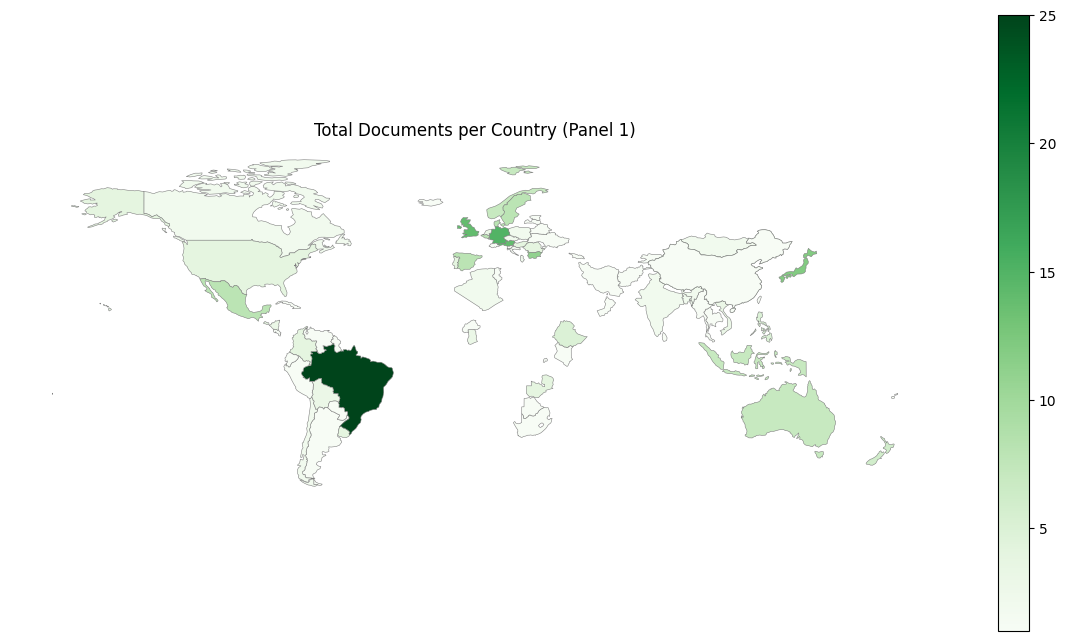

In [88]:
import matplotlib.pyplot as plt

# 1) Plot all country borders in black
world.boundary.plot(ax=ax, linewidth=0.5, color="black")

world1 = world.merge(bef2015_counts, left_on="NAME", right_on="Country", how="left")

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
world1.plot(
    column="Total documents",
    cmap="Greens",
    linewidth=0.4,
    edgecolor="gray",
    legend=True,
    ax=ax
)

ax.set_title("Total Documents per Country (Panel 1)")
ax.axis("off")
plt.show()


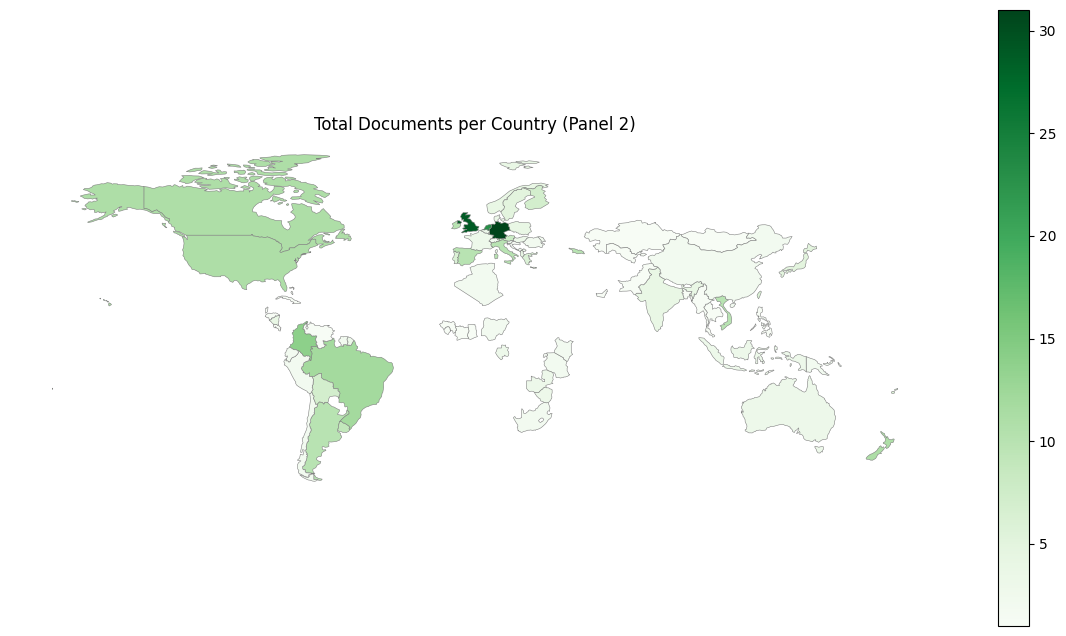

In [89]:
world2 = world.merge(aft2015_counts, left_on="NAME", right_on="Country", how="left")

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
world2.plot(
    column="Total documents",
    cmap="Greens",
    linewidth=0.4,
    edgecolor="gray",
    legend=True,
    ax=ax
)

ax.set_title("Total Documents per Country (Panel 2)")
ax.axis("off")
plt.show()


In [90]:
import matplotlib.colors as colors

In [91]:
# Get global min/max across both dataframes
vmin = min(world1["Total documents"].min(), world2["Total documents"].min())
vmax = max(world1["Total documents"].max(), world2["Total documents"].max())

# Round nicely
vmin = 0
vmax = int(np.ceil(vmax / 5) * 5)

# Create bins every 5
bins = np.arange(vmin, vmax + 5, 5)

# Discrete colormap
cmap = plt.cm.Greens
norm = colors.BoundaryNorm(bins, cmap.N)

C:\Users\ad882\AppData\Local\Temp\ipykernel_19960\2907861529.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


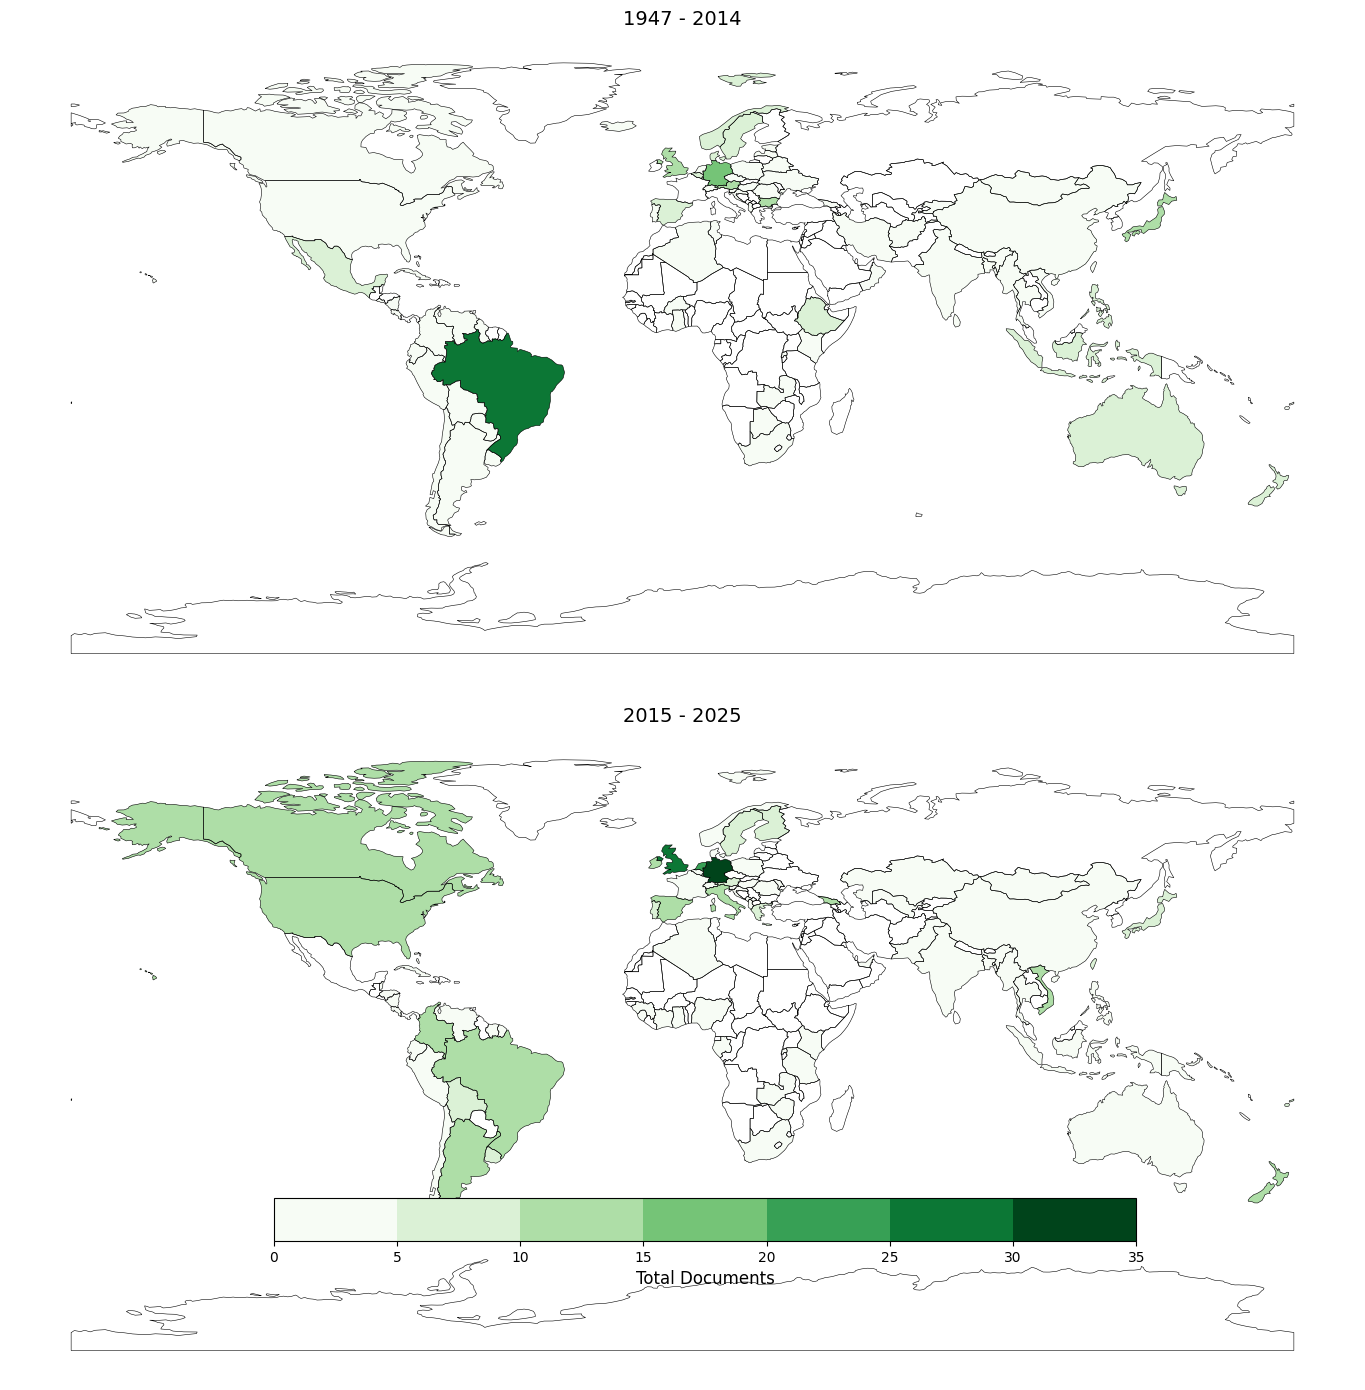

In [92]:
fig, axes = plt.subplots(2, 1, figsize=(18, 14))

# ---- Panel 1 ----
world.boundary.plot(ax=axes[0], linewidth=0.4, color="black")

world1.plot(
    column="Total documents",
    cmap=cmap,
    norm=norm,
    ax=axes[0],
    edgecolor="none"
)

axes[0].set_title("1947 - 2014", fontsize=14)
axes[0].axis("off")

# ---- Panel 2 ----
world.boundary.plot(ax=axes[1], linewidth=0.4, color="black")

world2.plot(
    column="Total documents",
    cmap=cmap,
    norm=norm,
    ax=axes[1],
    edgecolor="none"
)

axes[1].set_title("2015 - 2025", fontsize=14)
axes[1].axis("off")

# ---- Shared Legend at Bottom ----
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="horizontal",
    fraction=0.04,
    pad=0.05,
    ticks=bins
)

cbar.set_label("Total Documents", fontsize=12)
cbar.ax.set_xticklabels(bins)

plt.tight_layout()
plt.show()


In [186]:
un_region_map = {
    # African Group (54)
    "Algeria": "Africa",
    "Angola": "Africa",
    "Benin": "Africa",
    "Botswana": "Africa",
    "Burkina Faso": "Africa",
    "Burundi": "Africa",
    "Cabo Verde": "Africa",
    "Cameroon": "Africa",
    "Central African Republic": "Africa",
    "Chad": "Africa",
    "Comoros": "Africa",
    "Congo": "Africa",
    "Côte d'Ivoire": "Africa",
    "Djibouti": "Africa",
    "Egypt": "Africa",
    "Equatorial Guinea": "Africa",
    "Eritrea": "Africa",
    "Eswatini": "Africa",
    "Ethiopia": "Africa",
    "Gabon": "Africa",
    "Gambia": "Africa",
    "Ghana": "Africa",
    "Guinea": "Africa",
    "Guinea-Bissau": "Africa",
    "Kenya": "Africa",
    "Lesotho": "Africa",
    "Liberia": "Africa",
    "Libya": "Africa",
    "Madagascar": "Africa",
    "Malawi": "Africa",
    "Mali": "Africa",
    "Mauritania": "Africa",
    "Mauritius": "Africa",
    "Morocco": "Africa",
    "Mozambique": "Africa",
    "Namibia": "Africa",
    "Niger": "Africa",
    "Nigeria": "Africa",
    "Rwanda": "Africa",
    "Sao Tome and Principe": "Africa",
    "Senegal": "Africa",
    "Seychelles": "Africa",
    "Sierra Leone": "Africa",
    "Somalia": "Africa",
    "South Africa": "Africa",
    "South Sudan": "Africa",
    "Sudan": "Africa",
    "Tanzania": "Africa",
    "Togo": "Africa",
    "Tunisia": "Africa",
    "Uganda": "Africa",
    "Zambia": "Africa",
    "Zimbabwe": "Africa",

    # Asia-Pacific Group (53)
    "Afghanistan": "Asia-Pacific",
    "Bahrain": "Asia-Pacific",
    "Bangladesh": "Asia-Pacific",
    "Bhutan": "Asia-Pacific",
    "Brunei Darussalam": "Asia-Pacific",
    "Cambodia": "Asia-Pacific",
    "China": "Asia-Pacific",
    "Cyprus": "Asia-Pacific",
    "Democratic People's Republic of Korea": "Asia-Pacific",
    "Fiji": "Asia-Pacific",
    "India": "Asia-Pacific",
    "Indonesia": "Asia-Pacific",
    "Iran (Islamic Republic of)": "Asia-Pacific",
    "Iraq": "Asia-Pacific",
    "Japan": "Asia-Pacific",
    "Jordan": "Asia-Pacific",
    "Kazakhstan": "Asia-Pacific",
    "Kiribati": "Asia-Pacific",
    "Kuwait": "Asia-Pacific",
    "Kyrgyzstan": "Asia-Pacific",
    "Lao People's Democratic Republic": "Asia-Pacific",
    "Lebanon": "Asia-Pacific",
    "Malaysia": "Asia-Pacific",
    "Maldives": "Asia-Pacific",
    "Marshall Islands": "Asia-Pacific",
    "Micronesia (Federated States of)": "Asia-Pacific",
    "Mongolia": "Asia-Pacific",
    "Myanmar": "Asia-Pacific",
    "Nauru": "Asia-Pacific",
    "Nepal": "Asia-Pacific",
    "Oman": "Asia-Pacific",
    "Pakistan": "Asia-Pacific",
    "Palau": "Asia-Pacific",
    "Papua New Guinea": "Asia-Pacific",
    "Philippines": "Asia-Pacific",
    "Qatar": "Asia-Pacific",
    "Republic of Korea": "Asia-Pacific",
    "Samoa": "Asia-Pacific",
    "Saudi Arabia": "Asia-Pacific",
    "Singapore": "Asia-Pacific",
    "Solomon Islands": "Asia-Pacific",
    "Sri Lanka": "Asia-Pacific",
    "Syrian Arab Republic": "Asia-Pacific",
    "Tajikistan": "Asia-Pacific",
    "Thailand": "Asia-Pacific",
    "Timor-Leste": "Asia-Pacific",
    "Tonga": "Asia-Pacific",
    "Turkmenistan": "Asia-Pacific",
    "Tuvalu": "Asia-Pacific",
    "United Arab Emirates": "Asia-Pacific",
    "Uzbekistan": "Asia-Pacific",
    "Vanuatu": "Asia-Pacific",
    "Viet Nam": "Asia-Pacific",
    "Yemen": "Asia-Pacific",

    # Eastern European Group (23)
    "Albania": "Eastern Europe",
    "Armenia": "Eastern Europe",
    "Azerbaijan": "Eastern Europe",
    "Belarus": "Eastern Europe",
    "Bosnia and Herzegovina": "Eastern Europe",
    "Bulgaria": "Eastern Europe",
    "Croatia": "Eastern Europe",
    "Czech Republic": "Eastern Europe",
    "Estonia": "Eastern Europe",
    "Georgia": "Eastern Europe",
    "Hungary": "Eastern Europe",
    "Latvia": "Eastern Europe",
    "Lithuania": "Eastern Europe",
    "Moldova": "Eastern Europe",
    "Montenegro": "Eastern Europe",
    "North Macedonia": "Eastern Europe",
    "Poland": "Eastern Europe",
    "Romania": "Eastern Europe",
    "Russian Federation": "Eastern Europe",
    "Serbia": "Eastern Europe",
    "Slovakia": "Eastern Europe",
    "Slovenia": "Eastern Europe",
    "Ukraine": "Eastern Europe",

    # Latin American and Caribbean Group (GRULAC – 33)
    "Antigua and Barbuda": "GRULAC",
    "Argentina": "GRULAC",
    "Bahamas": "GRULAC",
    "Barbados": "GRULAC",
    "Belize": "GRULAC",
    "Bolivia (Plurinational State of)": "GRULAC",
    "Brazil": "GRULAC",
    "Chile": "GRULAC",
    "Colombia": "GRULAC",
    "Costa Rica": "GRULAC",
    "Cuba": "GRULAC",
    "Dominica": "GRULAC",
    "Dominican Republic": "GRULAC",
    "Ecuador": "GRULAC",
    "El Salvador": "GRULAC",
    "Grenada": "GRULAC",
    "Guatemala": "GRULAC",
    "Guyana": "GRULAC",
    "Haiti": "GRULAC",
    "Honduras": "GRULAC",
    "Jamaica": "GRULAC",
    "Mexico": "GRULAC",
    "Nicaragua": "GRULAC",
    "Panama": "GRULAC",
    "Paraguay": "GRULAC",
    "Peru": "GRULAC",
    "Saint Kitts and Nevis": "GRULAC",
    "Saint Lucia": "GRULAC",
    "Saint Vincent and the Grenadines": "GRULAC",
    "Suriname": "GRULAC",
    "Trinidad and Tobago": "GRULAC",
    "Uruguay": "GRULAC",
    "Venezuela (Bolivarian Republic of)": "GRULAC",

    # Western European and Others Group (WEOG)
    "Andorra": "WEOG",
    "Australia": "WEOG",
    "Austria": "WEOG",
    "Belgium": "WEOG",
    "Canada": "WEOG",
    "Denmark": "WEOG",
    "Finland": "WEOG",
    "France": "WEOG",
    "Germany": "WEOG",
    "Greece": "WEOG",
    "Iceland": "WEOG",
    "Ireland": "WEOG",
    "Israel": "WEOG",
    "Italy": "WEOG",
    "Liechtenstein": "WEOG",
    "Luxembourg": "WEOG",
    "Malta": "WEOG",
    "Monaco": "WEOG",
    "Netherlands": "WEOG",
    "New Zealand": "WEOG",
    "Norway": "WEOG",
    "Portugal": "WEOG",
    "San Marino": "WEOG",
    "Spain": "WEOG",
    "Sweden": "WEOG",
    "Switzerland": "WEOG",
    "Turkey": "WEOG",
    "United Kingdom of Great Britain and Northern Ireland": "WEOG",
    "United States of America": "WEOG"
}


In [94]:
country_year_stats["Region"] = country_year_stats["Country"].map(un_region_map)
country_year_stats

,Country,Year,Total documents,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Adaptation,Disaster Risk Management,Loss And Damage,Mitigation,Region
0,Afghanistan,2011.0,1,1,1,0,2.0,0.0,0.0,2.0,Asia-Pacific
1,Albania,2008.0,2,2,0,0,0.0,0.0,0.0,3.0,Eastern Europe
2,Albania,2015.0,3,3,2,0,0.0,0.0,0.0,3.0,Eastern Europe
3,Albania,2020.0,1,1,1,0,1.0,0.0,0.0,1.0,Eastern Europe
4,Algeria,1999.0,1,1,0,0,0.0,0.0,0.0,1.0,Africa
...,...,...,...,...,...,...,...,...,...,...,...
449,Zambia,2011.0,2,2,2,0,3.0,2.0,0.0,2.0,Africa
450,Zambia,2015.0,1,1,1,0,0.0,0.0,0.0,2.0,Africa
451,Zambia,2016.0,1,1,1,1,0.0,0.0,0.0,1.0,Africa
452,Zambia,2024.0,1,1,1,0,1.0,0.0,0.0,1.0,Africa


In [187]:
country_year_stats['Country'].unique().tolist()

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Antigua and Barbuda',
 'Argentina',
 'Australia',
 'Austria',
 'Bahamas',
 'Bangladesh',
 'Belarus',
 'Belgium',
 'Belize',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Bulgaria',
 'Burkina Faso',
 'Canada',
 'Chile',
 'China',
 'Colombia',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Czechia',
 "Côte d'Ivoire",
 'Denmark',
 'Dominican Republic',
 'Ecuador',
 'El Salvador',
 'Estonia',
 'Ethiopia',
 'European Union',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Guinea',
 'Guyana',
 'Honduras',
 'Hong Kong',
 'Hungary',
 'Iceland',
 'India',
 'Indonesia',
 'Iran',
 'Ireland',
 'Italy',
 'Japan',
 'Kazakhstan',
 'Kenya',
 'Kiribati',
 'Kosovo',
 'Kyrgyzstan',
 'Latvia',
 'Luxembourg',
 'Malta',
 'Mauritius',
 'Mexico',
 'Moldova',
 'Monaco',
 'Mongolia',
 'Montenegro',
 'Myanmar',
 'Nauru',
 'Netherlands',
 'New Zealand',
 'Nicaragua',
 'Nigeria',
 'Norway',
 'Oman',
 'Pakistan'

In [145]:
RESPONSE_COLS = [
    "Health relevance (1/0)",
    "Health adaptation mandate (1/0)",
    "Institutional health role (1/0)",
    "Adaptation",
    "Disaster Risk Management",
    "Loss And Damage",
    "Mitigation"
]

all_zero_cols = [
    col for col in RESPONSE_COLS
    if col in country_year_stats.columns and country_year_stats[col].sum() == 0
]

all_zero_cols


[]

In [97]:

region_totals = (
    country_year_stats
    .groupby(["Region", 'Year'])
    .sum()
    .reset_index()
).drop(columns=['Country', 'Health relevance (1/0)'])
region_totals


,Region,Year,Total documents,Health adaptation mandate (1/0),Institutional health role (1/0),Adaptation,Disaster Risk Management,Loss And Damage,Mitigation
0,Africa,1991.0,1,0,0,0.0,3.0,0.0,0.0
1,Africa,1997.0,3,3,0,0.0,0.0,0.0,3.0
2,Africa,1999.0,1,0,0,0.0,0.0,0.0,1.0
3,Africa,2004.0,2,2,0,1.0,1.0,0.0,1.0
4,Africa,2006.0,1,1,0,0.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...
131,WEOG,2021.0,17,7,0,4.0,1.0,0.0,18.0
132,WEOG,2022.0,24,11,0,4.0,1.0,0.0,33.0
133,WEOG,2023.0,19,7,1,6.0,0.0,0.0,22.0
134,WEOG,2024.0,5,4,1,3.0,0.0,0.0,5.0


In [98]:
region_totals.columns

Index(['Region', 'Year', 'Total documents', 'Health adaptation mandate (1/0)',
       'Institutional health role (1/0)', 'Adaptation',
       'Disaster Risk Management', 'Loss And Damage', 'Mitigation'],
      dtype='object')

In [96]:
region_totals['Year'].value_counts()

Year
2006.0    5
2011.0    5
2013.0    5
2010.0    5
2020.0    5
2018.0    5
2016.0    5
2015.0    5
2014.0    5
2023.0    5
2019.0    5
2021.0    5
2022.0    5
1997.0    4
2017.0    4
2024.0    4
2007.0    4
2009.0    4
2002.0    4
2001.0    4
2012.0    4
2008.0    4
1998.0    4
2004.0    3
1999.0    3
1992.0    3
2025.0    3
2005.0    3
2003.0    2
2000.0    2
1994.0    2
1991.0    1
1947.0    1
1984.0    1
1981.0    1
1961.0    1
1988.0    1
1996.0    1
1975.0    1
1990.0    1
1993.0    1
Name: count, dtype: int64

In [99]:
RESPONSE_COLS = [
    "Adaptation",
    "Disaster Risk Management",
    "Loss And Damage",
    "Mitigation"
]

COLORS = {
    "Adaptation": "#4daf4a",
    "Disaster Risk Management": "#377eb8",
    "Loss And Damage": "#e41a1c",
    "Mitigation": "#984ea3"
}


In [102]:
def plot_region_combo(df, region):
    data = df[df["Region"] == region].sort_values("Year")

    years = data["Year"].values
    x = np.arange(len(years))

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # ---- Stacked bars (policy responses)
    bottom = np.zeros(len(data))

    for col in RESPONSE_COLS:
        ax1.bar(
            x,
            data[col],
            bottom=bottom,
            color=COLORS[col],
            label=col,
            width=0.7
        )
        bottom += data[col].values

    ax1.set_ylabel("Policy response count")
    ax1.set_xlabel("Year")
    ax1.set_xticks(x)
    ax1.set_xticklabels(years, rotation=45)

    # ---- Line plot (total documents)
    ax2 = ax1.twinx()
    ax2.plot(
        x,
        data["Total documents"],
        color="black",
        marker="o",
        linewidth=2.5,
        label="Total health-relevant documents"
    )

    ax2.set_ylabel("Total documents")

    # ---- Legend
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    fig.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="lower center",
        ncol=5,
        frameon=True
    )

    plt.title(region, loc="left", fontsize=14)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()


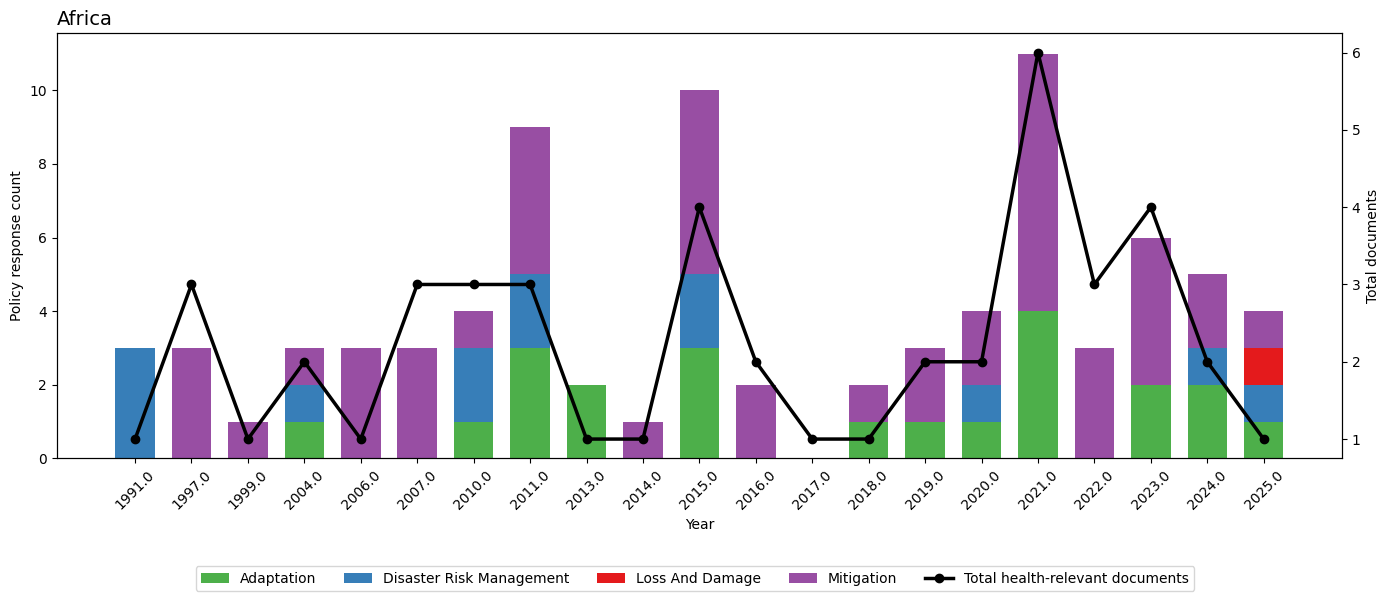

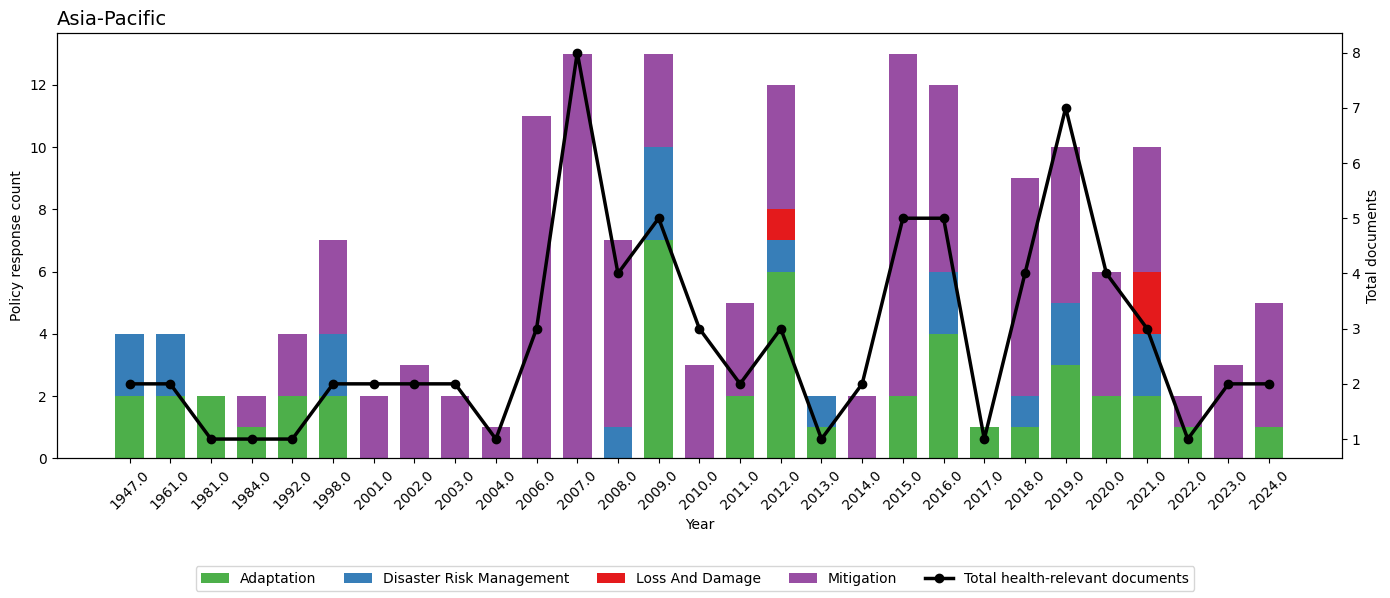

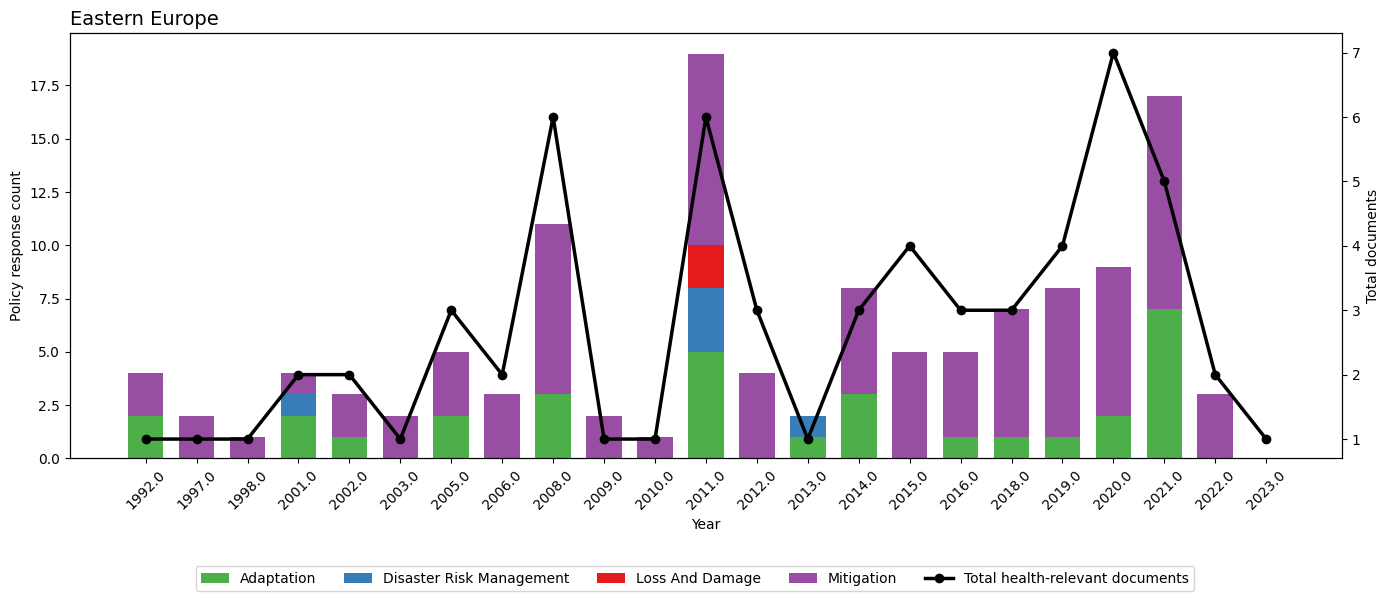

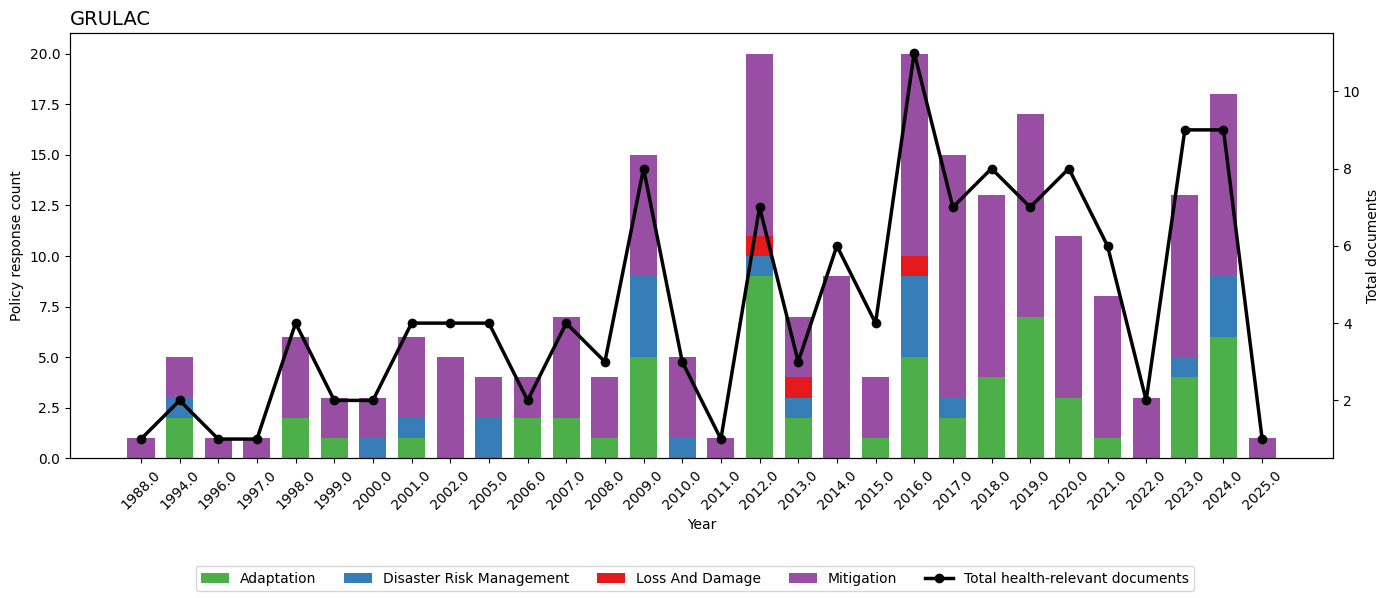

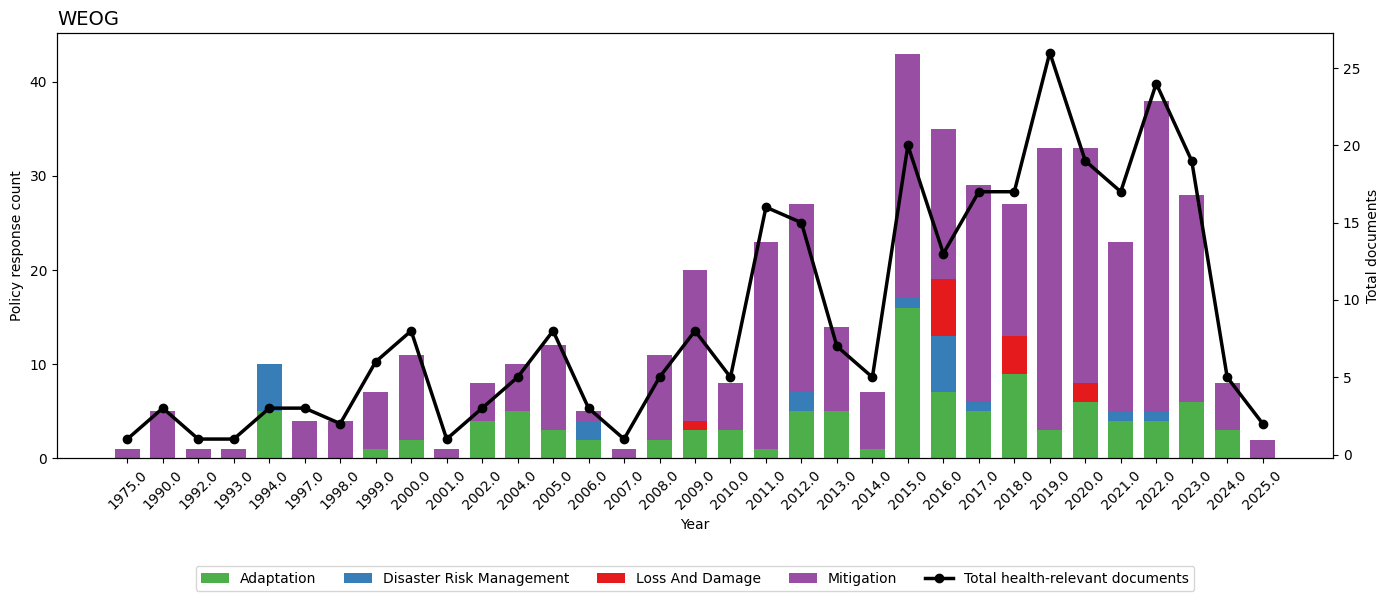

In [103]:
for region in region_totals["Region"].unique():
    plot_region_combo(region_totals, region)


In [114]:
import matplotlib.pyplot as plt
import numpy as np

RESPONSE_COLS = [
    "Adaptation",
    "Disaster Risk Management",
    "Loss And Damage",
    "Mitigation"
]

COLORS = {
    "Adaptation": "#4daf4a",
    "Disaster Risk Management": "#377eb8",
    "Loss And Damage": "#e41a1c",
    "Mitigation": "#984ea3"
}

def plot_all_regions_one_pdf(df, output_path):
    regions = sorted(df["Region"].dropna().unique())
    n_regions = len(regions)

    # ---- Common scales
    max_bar_y = df[RESPONSE_COLS].sum(axis=1).max()
    max_line_y = df["Total documents"].max()

    fig, axes = plt.subplots(
        n_regions,
        1,
        figsize=(16, 3.5 * n_regions),
        sharex=True
    )

    if n_regions == 1:
        axes = [axes]

    for ax, region in zip(axes, regions):
        data = df[df["Region"] == region].sort_values("Year")

        years = data["Year"].astype(int).values
        x = np.arange(len(years))
        bottom = np.zeros(len(data))

        # ---- Stacked bars
        for col in RESPONSE_COLS:
            bars = ax.bar(
                x,
                data[col],
                bottom=bottom,
                color=COLORS[col],
                alpha=0.35,
                edgecolor="black",
                linewidth=0.6,
                width=0.7,
                label=col
            )

            # ---- Value labels
            for i, v in enumerate(data[col].values):
                if v > 0:
                    ax.text(
                        x[i],
                        bottom[i] + v / 2,
                        str(int(v)),
                        ha="center",
                        va="center",
                        fontsize=8
                    )

            bottom += data[col].values

        ax.set_ylim(0, max_bar_y)
        ax.set_ylabel("Policy responses")
        ax.set_title(region, loc="left", fontsize=13)

        # ---- Line for total documents
        ax2 = ax.twinx()
        ax2.plot(
            x,
            data["Total documents"],
            color="black",
            marker="o",
            linewidth=2
        )
        ax2.set_ylim(0, max_line_y)
        ax2.set_ylabel("Total documents")

        ax.set_xticks(x)
        ax.set_xticklabels(years, rotation=45)

    # ---- Common legend (vertical, top-left)
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=COLORS[c], alpha=0.35, ec="black")
        for c in RESPONSE_COLS
    ]
    fig.legend(
        handles,
        RESPONSE_COLS,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        frameon=True,
        ncol=1
    )

    plt.tight_layout(rect=[0.08, 0.03, 1, 0.97])
    plt.savefig(output_path, format="pdf")
    plt.close()


In [142]:
RESPONSE_COLS = [
    "Adaptation",
    "Disaster Risk Management",
    "Loss And Damage",
    "Mitigation"
]

COLORS = {
    "Adaptation": "#4daf4a",
    "Disaster Risk Management": "#377eb8",
    "Loss And Damage": "#e41a1c",
    "Mitigation": "#984ea3"
}

def plot_all_regions_one_pdf(df, output_path):
    regions = sorted(df["Region"].dropna().unique())
    n_regions = len(regions)

    BAR_Y_MAX = 60
    LINE_Y_MAX = 60

    fig, axes = plt.subplots(
        n_regions,
        1,
        figsize=(16, 3.5 * n_regions),
        sharex=True
    )

    if n_regions == 1:
        axes = [axes]

    # Store line handle ONCE for legend
    line_handle = None

    for ax, region in zip(axes, regions):
        data = df[df["Region"] == region].sort_values("Year")

        years = data["Year"].astype(int).values
        x = np.arange(len(years))
        bottom = np.zeros(len(data))

        # ---- Stacked bars (policy responses)
        for col in RESPONSE_COLS:
            ax.bar(
                x,
                data[col],
                bottom=bottom,
                color=COLORS[col],
                alpha=0.35,
                edgecolor="black",
                linewidth=0.6,
                width=0.7
            )
            bottom += data[col].values

        ax.set_ylim(0, BAR_Y_MAX)
        ax.set_ylabel("Policy responses")
        ax.set_title(region, loc="left", fontsize=13)

        # ---- Line: Total documents
        ax2 = ax.twinx()
        line, = ax2.plot(
            x,
            data["Total documents"],
            color="black",
            marker="o",
            linewidth=2.5,
            zorder=5,
            label="Total documents"
        )

        # Save ONE line handle for legend
        if line_handle is None:
            line_handle = line

        ax2.set_ylim(0, LINE_Y_MAX)
        ax2.set_ylabel("Total documents")

        # ---- Numeric labels for total documents ONLY
        for i, v in enumerate(data["Total documents"].values):
            ax2.text(
                x[i],
                v + 1,
                str(int(v)),
                ha="center",
                va="bottom",
                fontsize=9
            )

        ax.set_xticks(x)
        ax.set_xticklabels(years, rotation=45)

    # ---- Legend handles (bars + line)
    bar_handles = [
        plt.Rectangle((0, 0), 1, 1, color=COLORS[c], alpha=0.35, ec="black")
        for c in RESPONSE_COLS
    ]

    legend_handles = bar_handles + [line_handle]
    legend_labels = RESPONSE_COLS + ["Total documents"]

    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper left",
        bbox_to_anchor=(0.75, 0.92),
        frameon=True,
        ncol=1
    )

    plt.tight_layout(rect=[0.08, 0.03, 0.98, 0.95])
    plt.savefig(output_path, format="pdf")
    plt.close()


In [144]:
plot_all_regions_one_pdf(
    df=region_totals,
    output_path="../output/regional_health_policy_trends.pdf"
)


In [189]:
df[df['Country'] == 'Zambia']

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes,Matched health keywords
14,green-economy-and-climate-change-act-of-2024_8543,Zambia,2024.0,Mitigation;Adaptation,1,1,0,38. Appeals 39. Climate Change Register 40. Im...,NaN,health;hospital;ill;mental;wellbeing
15,national-tourism-and-hospitality-act-2015_53f2,Zambia,2015.0,Mitigation,1,1,0,Tourism and Hospitality [No. 13 of 2015 247 TH...,NaN,AIDS;HIV;anger;health;hospital;ill;medical;men...
16,the-environmental-management-amendment-act_7624,Zambia,2011.0,Mitigation;Adaptation;Disaster Risk Management,1,1,0,Environmental Management (Amendment) [No. 8 of...,NaN,accident;emergency;flu;health;healthcare;mental
17,the-environmental-management-act-2011_901a,Zambia,2011.0,Mitigation;Adaptation;Disaster Risk Management,1,1,0,Environmental Management [No. 12 of 2011 87 TH...,NaN,air pollution;anger;death;disease;emergency;fl...
747,disaster-management-act-no-132010-4372,Zambia,2010.0,Disaster Risk Management,1,1,0,Enactment PART I PRELIMINARY 1. This Act may b...,NaN,anger;death;deaths;emergency;health;health car...
949,constitution-of-zambia_7667,Zambia,2016.0,Mitigation,1,1,1,"generated: 27 Feb 2023, 12:58 Table of content...",NaN,emergency;mental
1184,the-water-resources-management-act-2011_2c36,Zambia,2011.0,Adaptation,0,0,0,NaN,NaN,
1185,the-forests-act-2015_1c6b,Zambia,2015.0,Mitigation,0,0,0,NaN,NaN,
1186,the-energy-regulation-energy-definition-order-...,Zambia,2008.0,Mitigation,0,0,0,NaN,NaN,
1187,the-energy-regulations-act-chapter-436_d9a7,Zambia,1995.0,Mitigation,0,0,0,NaN,NaN,


In [192]:
df['Year'].value_counts()

Year
2020.0    110
2015.0    106
2019.0     98
2021.0     92
2016.0     87
2009.0     86
2012.0     85
2023.0     83
2011.0     80
2010.0     75
2022.0     75
2018.0     75
2017.0     73
2013.0     70
2014.0     70
2008.0     67
2007.0     62
2024.0     49
2005.0     40
2006.0     36
2003.0     33
2004.0     32
2001.0     31
2000.0     30
2002.0     29
1999.0     23
1998.0     21
1997.0     18
1994.0     11
1992.0     10
1991.0      9
1990.0      9
1995.0      6
1993.0      6
1989.0      6
2025.0      5
1996.0      5
1980.0      3
1976.0      3
1988.0      2
1981.0      2
1947.0      2
1961.0      2
1987.0      2
1984.0      2
1957.0      2
1956.0      1
1975.0      1
1982.0      1
1977.0      1
1972.0      1
1986.0      1
1948.0      1
1983.0      1
1979.0      1
1964.0      1
Name: count, dtype: int64

In [193]:
country_year_stats

,Country,Year,Total documents,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Adaptation,Disaster Risk Management,Loss And Damage,Mitigation,Region
0,Afghanistan,2011.0,1,1,1,0,2.0,0.0,0.0,2.0,Asia-Pacific
1,Albania,2008.0,2,2,0,0,0.0,0.0,0.0,3.0,Eastern Europe
2,Albania,2015.0,3,3,2,0,0.0,0.0,0.0,3.0,Eastern Europe
3,Albania,2020.0,1,1,1,0,1.0,0.0,0.0,1.0,Eastern Europe
4,Algeria,1999.0,1,1,0,0,0.0,0.0,0.0,1.0,Africa
...,...,...,...,...,...,...,...,...,...,...,...
449,Zambia,2011.0,2,2,2,0,3.0,2.0,0.0,2.0,Africa
450,Zambia,2015.0,1,1,1,0,0.0,0.0,0.0,2.0,Africa
451,Zambia,2016.0,1,1,1,1,0.0,0.0,0.0,1.0,Africa
452,Zambia,2024.0,1,1,1,0,1.0,0.0,0.0,1.0,Africa


In [199]:
same = (country_year_stats['Total documents'] == country_year_stats['Health relevance (1/0)']).all()
print(same)


True


In [195]:
df_country

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
0,product-emissions-standards-act_2677,Australia,2017.0,Mitigation,0,0,0,NaN,NaN
1,law-no-2019-viii-about-electricity-market_6e94,Ukraine,2017.0,Mitigation,0,0,0,NaN,NaN
2,electricity-act-1997-857-consolidated-text_e923,Sweden,1998.0,Mitigation,1,0,0,Ellag (1997:857) undefinedTill innehåll på sid...,NaN
3,offshore-wind-energy-act_8c22,Netherlands,2016.0,Mitigation,1,0,0,3.3 Procedure van een vergelijkende toets(Arti...,NaN
4,law-no-292-2018-on-assessing-the-impact-of-cer...,Romania,2018.0,Mitigation;Adaptation,1,0,0,deciziile prevăzute la art. 18 alin. (8) și (9...,NaN
...,...,...,...,...,...,...,...,...,...
1832,law-44142016-6b79,Greece,2016.0,Mitigation,0,0,0,NaN,NaN
1833,heat-act_b7bd,Netherlands,2009.0,Mitigation,0,0,0,NaN,NaN
1834,information-on-the-mandatory-energy-efficiency...,China,2008.0,Mitigation,1,0,0,in Hong Kong requires manufacturers or importe...,NaN
1835,cap-598-energy-efficiency-labelling-of-product...,China,2008.0,Mitigation,0,0,0,NaN,NaN


In [196]:
# Assume your dataset is in a DataFrame called df_docs
# Columns: ['Doc ID', 'Country', 'Year', 'Response', 'Health relevance (1/0)', 'Health adaptation mandate (1/0)', 'Institutional health role (1/0)', ...]

# First, define all response categories you want to count
response_categories = [
    'Adaptation', 
    'Disaster Risk Management', 
    'Loss And Damage', 
    'Mitigation'
]

# Create dummy columns for each response category
for category in response_categories:
    df_country[category] = df_country['Response'].str.contains(category).fillna(False).astype(int)

# Now group by Country and Year and aggregate counts
df_summary = df_country.groupby(['Country', 'Year'], as_index=False).agg(
    **{
        'Total documents': ('Doc ID', 'count'),
        'Health relevance (1/0)': ('Health relevance (1/0)', 'sum'),
        'Health adaptation mandate (1/0)': ('Health adaptation mandate (1/0)', 'sum'),
        'Institutional health role (1/0)': ('Institutional health role (1/0)', 'sum'),
        'Adaptation': ('Adaptation', 'sum'),
        'Disaster Risk Management': ('Disaster Risk Management', 'sum'),
        'Loss And Damage': ('Loss And Damage', 'sum'),
        'Mitigation': ('Mitigation', 'sum')
    }
)

# Optionally, you can add Region info if you have a mapping
# e.g., country_region_map = {'Australia': 'Asia-Pacific', ...}
# df_summary['Region'] = df_summary['Country'].map(country_region_map)




C:\Users\ad882\AppData\Local\Temp\ipykernel_19960\1785564062.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_country[category] = df_country['Response'].str.contains(category).fillna(False).astype(int)
C:\Users\ad882\AppData\Local\Temp\ipykernel_19960\1785564062.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_country[category] = df_country['Response'].str.contains(category).fillna(False).astype(int)
C:\Users\ad882\AppData\Local\Temp\ipykernel_19960\1785564062.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill 

In [197]:
df_summary

,Country,Year,Total documents,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Adaptation,Disaster Risk Management,Loss And Damage,Mitigation
0,Afghanistan,2011.0,2,1,1,0,2,0,0,2
1,Afghanistan,2012.0,2,0,0,0,2,2,0,0
2,Afghanistan,2015.0,1,0,0,0,0,0,0,1
3,Albania,2008.0,3,2,0,0,0,0,0,3
4,Albania,2013.0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
974,Zambia,2024.0,1,1,1,0,1,0,0,1
975,Zimbabwe,1989.0,1,0,0,0,1,1,0,0
976,Zimbabwe,2003.0,2,0,0,0,1,0,0,2
977,Zimbabwe,2011.0,1,0,0,0,0,0,0,1


In [198]:
# 4️⃣ Map countries to regions
UN_REGION_MAP = {
    # Africa
    "Algeria": "Africa", "Angola": "Africa", "Benin": "Africa", "Botswana": "Africa",
    "Burkina Faso": "Africa", "Burundi": "Africa", "Cabo Verde": "Africa", "Cameroon": "Africa",
    "Central African Republic": "Africa", "Chad": "Africa", "Comoros": "Africa", "Congo": "Africa",
    "Côte d'Ivoire": "Africa", "Djibouti": "Africa", "Egypt": "Africa", "Equatorial Guinea": "Africa",
    "Eritrea": "Africa", "Eswatini": "Africa", "Ethiopia": "Africa", "Gabon": "Africa",
    "Gambia": "Africa", "Ghana": "Africa", "Guinea": "Africa", "Guinea-Bissau": "Africa",
    "Kenya": "Africa", "Lesotho": "Africa", "Liberia": "Africa", "Libya": "Africa",
    "Madagascar": "Africa", "Malawi": "Africa", "Mali": "Africa", "Mauritania": "Africa",
    "Mauritius": "Africa", "Morocco": "Africa", "Mozambique": "Africa", "Namibia": "Africa",
    "Niger": "Africa", "Nigeria": "Africa", "Rwanda": "Africa", "Sao Tome and Principe": "Africa",
    "Senegal": "Africa", "Seychelles": "Africa", "Sierra Leone": "Africa", "Somalia": "Africa",
    "South Africa": "Africa", "South Sudan": "Africa", "Sudan": "Africa", "Tanzania": "Africa",
    "Togo": "Africa", "Tunisia": "Africa", "Uganda": "Africa", "Zambia": "Africa", "Zimbabwe": "Africa",

    # Asia-Pacific
    "Afghanistan": "Asia-Pacific", "Bahrain": "Asia-Pacific", "Bangladesh": "Asia-Pacific",
    "Bhutan": "Asia-Pacific", "Brunei Darussalam": "Asia-Pacific", "Cambodia": "Asia-Pacific",
    "China": "Asia-Pacific", "Hong Kong": "Asia-Pacific", "Cyprus": "Asia-Pacific", "South Korea": "Asia-Pacific",
    "Fiji": "Asia-Pacific", "India": "Asia-Pacific", "Indonesia": "Asia-Pacific", "Iran": "Asia-Pacific",
    "Iraq": "Asia-Pacific", "Japan": "Asia-Pacific", "Jordan": "Asia-Pacific", "Kazakhstan": "Asia-Pacific",
    "Kiribati": "Asia-Pacific", "Kuwait": "Asia-Pacific", "Kyrgyzstan": "Asia-Pacific",
    "Lao People's Democratic Republic": "Asia-Pacific", "Lebanon": "Asia-Pacific", "Malaysia": "Asia-Pacific",
    "Maldives": "Asia-Pacific", "Marshall Islands": "Asia-Pacific", "Micronesia (Federated States of)": "Asia-Pacific",
    "Mongolia": "Asia-Pacific", "Myanmar": "Asia-Pacific", "Nauru": "Asia-Pacific", "Nepal": "Asia-Pacific",
    "Oman": "Asia-Pacific", "Pakistan": "Asia-Pacific", "Palau": "Asia-Pacific", "Papua New Guinea": "Asia-Pacific",
    "Philippines": "Asia-Pacific", "Qatar": "Asia-Pacific", "North Korea": "Asia-Pacific", "Samoa": "Asia-Pacific",
    "Saudi Arabia": "Asia-Pacific", "Singapore": "Asia-Pacific", "Solomon Islands": "Asia-Pacific",
    "Sri Lanka": "Asia-Pacific", "Syrian Arab Republic": "Asia-Pacific", "Tajikistan": "Asia-Pacific",
    "Thailand": "Asia-Pacific", "Timor-Leste": "Asia-Pacific", "Tonga": "Asia-Pacific", "Turkmenistan": "Asia-Pacific",
    "Tuvalu": "Asia-Pacific", "United Arab Emirates": "Asia-Pacific", "Uzbekistan": "Asia-Pacific",
    "Vanuatu": "Asia-Pacific", "Vietnam": "Asia-Pacific", "Yemen": "Asia-Pacific", "Taiwan": "Asia-Pacific",

    # Eastern Europe
    "Albania": "Eastern Europe", "Armenia": "Eastern Europe", "Azerbaijan": "Eastern Europe",
    "Belarus": "Eastern Europe", "Bosnia and Herzegovina": "Eastern Europe", "Bulgaria": "Eastern Europe",
    "Croatia": "Eastern Europe", "Czechia": "Eastern Europe", "Estonia": "Eastern Europe", "Georgia": "Eastern Europe",
    "Hungary": "Eastern Europe", "Latvia": "Eastern Europe", "Lithuania": "Eastern Europe", "Moldova": "Eastern Europe",
    "Montenegro": "Eastern Europe", "North Macedonia": "Eastern Europe", "Poland": "Eastern Europe", "Romania": "Eastern Europe",
    "Russian Federation": "Eastern Europe", "Serbia": "Eastern Europe", "Slovakia": "Eastern Europe", "Slovenia": "Eastern Europe",
    "Ukraine": "Eastern Europe", "Kosovo": "Eastern Europe",

    # GRULAC
    "Antigua and Barbuda": "GRULAC", "Argentina": "GRULAC", "Bahamas": "GRULAC", "Barbados": "GRULAC",
    "Belize": "GRULAC", "Bolivia": "GRULAC", "Brazil": "GRULAC", "Chile": "GRULAC", "Colombia": "GRULAC",
    "Costa Rica": "GRULAC", "Cuba": "GRULAC", "Dominica": "GRULAC", "Dominican Republic": "GRULAC", "Ecuador": "GRULAC",
    "El Salvador": "GRULAC", "Grenada": "GRULAC", "Guatemala": "GRULAC", "Guyana": "GRULAC", "Haiti": "GRULAC",
    "Honduras": "GRULAC", "Jamaica": "GRULAC", "Mexico": "GRULAC", "Nicaragua": "GRULAC", "Panama": "GRULAC",
    "Paraguay": "GRULAC", "Peru": "GRULAC", "Saint Kitts and Nevis": "GRULAC", "Saint Lucia": "GRULAC",
    "Saint Vincent and the Grenadines": "GRULAC", "Suriname": "GRULAC", "Trinidad and Tobago": "GRULAC",
    "Uruguay": "GRULAC", "Venezuela (Bolivarian Republic of)": "GRULAC", "Venezuela": "GRULAC",

    # WEOG
    "Andorra": "WEOG", "Australia": "WEOG", "Austria": "WEOG", "Belgium": "WEOG", "Canada": "WEOG",
    "Denmark": "WEOG", "Finland": "WEOG", "France": "WEOG", "Germany": "WEOG", "Greece": "WEOG",
    "Iceland": "WEOG", "Ireland": "WEOG", "Israel": "WEOG", "Italy": "WEOG", "Liechtenstein": "WEOG",
    "Luxembourg": "WEOG", "Malta": "WEOG", "Monaco": "WEOG", "Netherlands": "WEOG", "New Zealand": "WEOG",
    "Norway": "WEOG", "Portugal": "WEOG", "San Marino": "WEOG", "Spain": "WEOG", "Sweden": "WEOG",
    "Switzerland": "WEOG", "Türkiye": "WEOG", "United Kingdom": "WEOG", "United States": "WEOG",
    "European Union": None
}

# Map countries to regions
df_summary['Region'] = df_summary['Country'].map(UN_REGION_MAP)

# Optional: replace region codes with display names
REGION_DISPLAY_NAMES = {
    "Africa": "African",
    "Asia-Pacific": "Asia-Pacific",
    "Eastern Europe": "Eastern European",
    "GRULAC": "Latin American and Caribbean Group (GRULAC)",
    "WEOG": "Western European and Others Group (WEOG)"
}
df_summary['Region'] = df_summary['Region'].map(REGION_DISPLAY_NAMES)

# Sort by Country and Year for readability
df_summary = df_summary.sort_values(['Country', 'Year']).reset_index(drop=True)

df_summary

,Country,Year,Total documents,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Adaptation,Disaster Risk Management,Loss And Damage,Mitigation,Region
0,Afghanistan,2011.0,2,1,1,0,2,0,0,2,Asia-Pacific
1,Afghanistan,2012.0,2,0,0,0,2,2,0,0,Asia-Pacific
2,Afghanistan,2015.0,1,0,0,0,0,0,0,1,Asia-Pacific
3,Albania,2008.0,3,2,0,0,0,0,0,3,Eastern European
4,Albania,2013.0,1,0,0,0,0,0,0,1,Eastern European
...,...,...,...,...,...,...,...,...,...,...,...
974,Zambia,2024.0,1,1,1,0,1,0,0,1,African
975,Zimbabwe,1989.0,1,0,0,0,1,1,0,0,African
976,Zimbabwe,2003.0,2,0,0,0,1,0,0,2,African
977,Zimbabwe,2011.0,1,0,0,0,0,0,0,1,African


In [201]:
df_summary.to_csv("../output/region_year_health_stats.csv", index=False)

In [203]:
df_health_stats = df_summary.drop(columns=['Adaptation', 'Mitigation', 'Loss And Damage', 'Disaster Risk Management'])
df_health_stats = df_health_stats.rename(columns={
    'Health relevance (1/0)': 'Health relevance count', 'Health adaptation mandate (1/0)': 'Health adaptation mandate count', 'Institutional health role (1/0)': 'Institutional health role count'})
df_health_stats

,Country,Year,Total documents,Health relevance count,Health adaptation mandate count,Institutional health role count,Region
0,Afghanistan,2011.0,2,1,1,0,Asia-Pacific
1,Afghanistan,2012.0,2,0,0,0,Asia-Pacific
2,Afghanistan,2015.0,1,0,0,0,Asia-Pacific
3,Albania,2008.0,3,2,0,0,Eastern European
4,Albania,2013.0,1,0,0,0,Eastern European
...,...,...,...,...,...,...,...
974,Zambia,2024.0,1,1,1,0,African
975,Zimbabwe,1989.0,1,0,0,0,African
976,Zimbabwe,2003.0,2,0,0,0,African
977,Zimbabwe,2011.0,1,0,0,0,African


In [7]:
check = pd.read_csv("../data/extra_legis_rows.csv")
check

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Keyword,Instrument,Author,Author Type,Document URL,Family URL,Document Role,Document Type,Category,first_event_year
0,draft-environmental-code-of-the-republic-of-ta...,Draft Environmental Code of the Republic of Ta...,draft-environmental-code-of-the-republic-of-ta...,Draft Environmental Code of the Republic of Ta...,<p>The Environmental Code of the Republic of T...,NaN,NaN,NaN,https://egov.tj/site/nature-tjk/documents/deta...,English;Tajik,...,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/draft-envir...,https://climate-laws.org/document/draft-enviro...,Main,Regulation,Legislative,2025
1,act-239-2000-coll-act-on-the-integrated-rescue...,Act 239/2000 Coll. - Act on the Integrated Res...,act-239-2000-coll-act-on-the-integrated-rescue...,Act 239/2000 Coll. - Act on the Integrated Res...,<p>This law establishes an integrated system o...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech;English,...,Adaptation;Institutions / Administrative Arran...,NaN,NaN,NaN,https://climate-laws.org/documents/act-239-200...,https://climate-laws.org/document/act-239-2000...,Main,Law,Legislative,2000
2,act-no-458-2000-coll-on-the-conditions-for-ope...,"Act No. 458/2000 Coll., on the Conditions for ...",act-no-458-2000-coll-on-the-conditions-for-ope...,"Act No. 458/2000 Coll., on the Conditions for ...",<p>The Energy Act (458/2000 Sb.) sets out the ...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech,...,Energy Supply,"Processes, plans and strategies|Governance",NaN,NaN,https://climate-laws.org/documents/act-no-458-...,https://climate-laws.org/document/act-no-458-2...,Main,Law,Legislative,2000
3,forest-act-289-1995-coll_2ac3,Forest Act 289/1995 Coll.,forest-act-289-1995-coll_14cb,Forest Act 289/1995 Coll.,<p>The purpose of this Act is to establish the...,NaN,NaN,Original Language,https://cpr-prod-cclw-document-admin-store.s3....,Czech,...,Forests,NaN,NaN,NaN,https://climate-laws.org/documents/forest-act-...,https://climate-laws.org/document/forest-act-2...,Main,Act,Legislative,1995
4,law-on-glacier-protection_f154,Law on Glacier Protection,law-on-glacier-protection_04a9,Law on Glacier Protection,<p>Tajikistan's 2024 Law on Glacier Protection...,NaN,NaN,NaN,https://meteo.tj/storage/documents/40584118514...,Russian,...,Glaciers,NaN,NaN,NaN,https://climate-laws.org/documents/law-on-glac...,https://climate-laws.org/document/law-on-glaci...,Main,Law,Legislative,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,forest-carbon-stock-management-regulations-202...,Forest Carbon Stock Management Regulations 2021,forest-carbon-stock-management-regulations-202...,Forest Carbon Stock Management Regulations 2021,<p>The Forest Carbon Stock Management Regulati...,NaN,NaN,Original Language,https://media.zambialii.org/media/legislation/...,English,...,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/forest-carb...,https://climate-laws.org/document/forest-carbo...,Main,Regulation,Legislative,2021
413,resolution-no-1447-of-2018_e03a,Resolution No. 1447 of 2018,resolution-no-1447-of-2018_936d,Resolution No. 1447 of 2018,<p>Resolution 1447 of 2018 aims to regulate th...,NaN,NaN,Original Language,https://www.minambiente.gov.co/wp-content/uplo...,Spanish,...,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/resolution-...,https://climate-laws.org/document/resolution-n...,Main,Resolution,Legislative,2017
414,supreme-decree-no-4_f762,Supreme Decree No. 4,supreme-decree-no-4-approving-regulations-for-...,Supreme Decree No. 4 Approving regulations for...,<p>Supreme Decree No. 4 establishes requiremen...,NaN,NaN,Original Language,https://www.bcn.cl/leychile/navegar?idNorma=10...,NaN,...,NaN,NaN,NaN,NaN,https://climate-laws.org/documents/supreme-dec...,https://climate-laws.org/document/supreme-decr...,Ma

False

In [17]:
adding_rows

,Doc ID,Country,Year,Response,Health relevance (1/0),Health adaptation mandate (1/0),Institutional health role (1/0),Extracted health text,Notes
2,energy-from-renewable-sources-act_18bd,Bulgaria,2011,Mitigation,1,1,0,"consumption of electricity, heating and coolin...",NaN
3,law-2020-009-on-vat-exemption-for-renewable-en...,Mali,2020,Mitigation,0,0,0,NaN,NaN
4,forest-law-no-1700_525a,Bolivia,1996,Adaptation;Mitigation,1,1,0,SANCHEZ DE LOZADA CONSTITUTIONAL PRESIDENT OF ...,NaN
7,climate-change-amendment-act-2023_6f93,Kenya,2016,Adaptation;Disaster Risk Management;Mitigation,1,1,0,"set of established rules, procedures, and meth...",NaN
10,physical-and-land-use-planning-act-2019_abab,Kenya,2019,NaN,1,1,0,Local Physical and Land Use Development Plans....,NaN
24,law-on-promoting-the-use-of-energy-from-renewa...,Moldova,2016,Mitigation,1,1,0,technological consumption and losses of electr...,NaN
27,regulation-for-the-exemption-of-the-im-on-sale...,Costa Rica,2017,Mitigation,1,1,0,"Rector of the Subsector Energy, according to t...",NaN
37,law-251-93-approving-the-convention-on-climate...,Paraguay,1993,Mitigation;Adaptation,1,0,0,119 0 obj << /Type /Page /MediaBox [ 0 0 611 1...,NaN
38,legal-notice-no-47-approving-the-national-buil...,Kenya,2024,Mitigation,1,1,0,existing road. 17. Protection edge above groun...,NaN
39,sixteenth-five-year-development-plan-2024-25-2...,Nepal,2023,Mitigation,0,0,0,NaN,NaN


In [18]:
extended_failed_df = pd.read_csv("../data/extended_failed_extractions.csv")
extended_failed_df

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Topic/Response,Hazard,Sector,Keyword,Instrument,Author,Author Type,Document URL,Family URL,first_event_year
0,anp-ordinance-no-249-2000-regulation-on-oil-an...,"ANP Ordinance no. 249, 2000, Regulation on oil...",anp-ordinance-no-249-2000-regulation-on-oil-an...,"ANP Ordinance no. 249, 2000, Regulation on oil...","<p>PORTARIA ANP Nº 249, DE 1º.11.2000 - DOU 3....",NaN,NaN,Original Language,https://www.ibama.gov.br/sophia/cnia/legislaca...,Portuguese,...,Mitigation,NaN,Industry;Energy,Mitigation,"Standards, obligations and norms|Regulation",NaN,NaN,NaN,NaN,2002
1,federal-law-15-042-2024_7b8f,Federal Law 15.042/2024,federal-law-15-042-2024-on-the-brazilian-green...,Federal Law 15.042/2024 on the Brazilian Green...,<p>This law establishes the Brazilian Greenhou...,NaN,NaN,Original Language,https://pesquisa.in.gov.br/imprensa/jsp/visual...,Portuguese,...,Mitigation,NaN,Economy-wide,Trading Scheme;GHG,NaN,NaN,NaN,NaN,NaN,2024
2,energy-from-renewable-sources-act_18bd,Energy from Renewable Sources Act,energy-from-renewable-sources-act_4d88,Energy from Renewable Sources Act,The Energy from Renewable Sources Act replaces...,NaN,NaN,Translation,https://www.seea.government.bg/documents/Energ...,English;English,...,Mitigation,NaN,Energy,Energy Supply,Subsidies|Economic;Capacity building|Governance,NaN,NaN,NaN,NaN,2011
3,law-2020-009-on-vat-exemption-for-renewable-en...,Law 2020-009 on VAT exemption for renewable en...,law-2020-009-on-vat-exemption-for-renewable-en...,Law 2020-009 on VAT exemption for renewable en...,<p>This law ratifies the ordinance No. 2020-01...,NaN,NaN,NaN,https://www.droit-afrique.com/uploads/Mali-Ord...,French,...,Mitigation,NaN,Energy,NaN,Tax incentives|Economic,NaN,NaN,NaN,NaN,2020
4,forest-law-no-1700_525a,Forest Law No. 1700,forest-law-no-1700_22c2,Forest Law No. 1700,This law was written to bring forestry legisla...,NaN,NaN,NaN,https://www.tribunalagroambiental.bo/wp-conten...,NaN,...,Adaptation;Mitigation,NaN,NaN,REDD+ And LULUCF,NaN,NaN,NaN,NaN,NaN,1996
5,disaster-management-regulations-2016_b8d1,"Disaster Management Regulations, 2016",disaster-management-act-no-17-of-2015_be8e,Disaster Management Act (No. 17 of 2015),<p>This Act provides guidelines and measures f...,NaN,NaN,Original Language,https://drmims.sadc.int/sites/default/files/do...,English,...,Adaptation;Disaster Risk Management,NaN,NaN,Adaptation,Capacity building|Governance;Institutional man...,NaN,NaN,NaN,NaN,2015
6,full-text-act_8042,Full text - Act,disaster-risk-management-and-climate-change-ac...,Disaster Risk Management and Climate Change Act,<p>This Act sets out Kiribati's overall approa...,NaN,NaN,Original Language,https://www.president.gov.ki/images/Gazettes/2...,English,...,Mitigation;Adaptation;Disaster Risk Management,NaN,Economy-wide;Cross Cutting Area,Governance;Institutions / Administrative Arran...,NaN,NaN,NaN,NaN,NaN,2020
7,climate-change-amendment-act-2023_6f93,"Climate Change (Amendment) Act, 2023",climate-change-act_e5f8,Climate Change Act,<p>Kenya passed its Climate Change Act in 2016...,NaN,NaN,NaN,https://kenyalaw.org/kl/fileadmin/pdfdownloads...,English,...,Adaptation;Disaster Risk Management;Mitigation,NaN,Buildings;Transport,Adaptation;Institutions / Administrative Arran...,"Standards, obligations and norms|Regulation;Pr...",NaN,NaN,NaN,NaN,2016
8,law-no-121-on-offshore-wind-energy_a27d,Law no. 121 on offshore wind energy,law-no-121-on-offshore-wind-energy_03d1,Law No. 121 on offshore wind energy,"<p>In May 2024, Romania adopted its first offs...",NaN,NaN,NaN,https://www.cdep.ro/pls/legis/legis_pck.htp_ac...,Romanian,...,Mitigation,NaN,Energy,Renewables;Energy Transition;Wind,NaN,NaN,NaN,NaN,NaN,2024
9,information-paper-incorporating-an-emissions-r...,Information paper: Incorporating an emissions ...,statutes-amendment-national-energy-laws-emissi...,Statutes Amend

In [19]:
extended_failed_df = extended_failed_df[~extended_failed_df["Document ID"].isin(adding_rows["Doc ID"])]
extended_failed_df

,Document ID,Document Title,Family ID,Family Title,Family Summary,Collection Title(s),Collection Description(s),Document Variant,Document Content URL,Language,...,Topic/Response,Hazard,Sector,Keyword,Instrument,Author,Author Type,Document URL,Family URL,first_event_year
0,anp-ordinance-no-249-2000-regulation-on-oil-an...,"ANP Ordinance no. 249, 2000, Regulation on oil...",anp-ordinance-no-249-2000-regulation-on-oil-an...,"ANP Ordinance no. 249, 2000, Regulation on oil...","<p>PORTARIA ANP Nº 249, DE 1º.11.2000 - DOU 3....",NaN,NaN,Original Language,https://www.ibama.gov.br/sophia/cnia/legislaca...,Portuguese,...,Mitigation,NaN,Industry;Energy,Mitigation,"Standards, obligations and norms|Regulation",NaN,NaN,NaN,NaN,2002
1,federal-law-15-042-2024_7b8f,Federal Law 15.042/2024,federal-law-15-042-2024-on-the-brazilian-green...,Federal Law 15.042/2024 on the Brazilian Green...,<p>This law establishes the Brazilian Greenhou...,NaN,NaN,Original Language,https://pesquisa.in.gov.br/imprensa/jsp/visual...,Portuguese,...,Mitigation,NaN,Economy-wide,Trading Scheme;GHG,NaN,NaN,NaN,NaN,NaN,2024
5,disaster-management-regulations-2016_b8d1,"Disaster Management Regulations, 2016",disaster-management-act-no-17-of-2015_be8e,Disaster Management Act (No. 17 of 2015),<p>This Act provides guidelines and measures f...,NaN,NaN,Original Language,https://drmims.sadc.int/sites/default/files/do...,English,...,Adaptation;Disaster Risk Management,NaN,NaN,Adaptation,Capacity building|Governance;Institutional man...,NaN,NaN,NaN,NaN,2015
6,full-text-act_8042,Full text - Act,disaster-risk-management-and-climate-change-ac...,Disaster Risk Management and Climate Change Act,<p>This Act sets out Kiribati's overall approa...,NaN,NaN,Original Language,https://www.president.gov.ki/images/Gazettes/2...,English,...,Mitigation;Adaptation;Disaster Risk Management,NaN,Economy-wide;Cross Cutting Area,Governance;Institutions / Administrative Arran...,NaN,NaN,NaN,NaN,NaN,2020
8,law-no-121-on-offshore-wind-energy_a27d,Law no. 121 on offshore wind energy,law-no-121-on-offshore-wind-energy_03d1,Law No. 121 on offshore wind energy,"<p>In May 2024, Romania adopted its first offs...",NaN,NaN,NaN,https://www.cdep.ro/pls/legis/legis_pck.htp_ac...,Romanian,...,Mitigation,NaN,Energy,Renewables;Energy Transition;Wind,NaN,NaN,NaN,NaN,NaN,2024
9,information-paper-incorporating-an-emissions-r...,Information paper: Incorporating an emissions ...,statutes-amendment-national-energy-laws-emissi...,Statutes Amendment (National Energy Laws) (Emi...,<p>This Act amends the National Electricity (S...,NaN,NaN,Original Language,https://www.energy.gov.au/sites/default/files/...,English,...,Mitigation,NaN,Energy,NaN,NaN,NaN,NaN,NaN,NaN,2023
11,the-environment-and-climate-adaptation-levy-ac...,The Environment and Climate Adaptation Levy Ac...,environment-and-climate-adaptation-levy-act-20...,Environment and Climate Adaptation Levy Act 2015,"<p><span style=""color: rgb(26,32,44);backgroun...",NaN,NaN,NaN,https://www.frcs.org.fj/wp-content/uploads/202...,English,...,Adaptation,NaN,Transport,Adaptation,Tax incentives|Economic,NaN,NaN,NaN,NaN,2016
12,regulation-on-environmental-impact-assessment_...,Regulation on Environmental Impact Assessment,regulation-on-environmental-impact-assessment_...,Regulation on Environmental Impact Assessment,<p>This document seeks to regulate the procedu...,NaN,NaN,Original Language,https://faolex.fao.org/docs/pdf/tur214574.pdf,Turkish,...,NaN,NaN,Environment,Environmental Impact Assessment,NaN,NaN,NaN,NaN,NaN,2022
13,regulation-on-fluorinated-greenhouse-gases_c0c9,Regulation on Fluorinated Greenhouse Gases,regulation-on-florinated-greenhouse-gases_4eb8,Regulation on Florinated Greenhouse Gases,<p>This regulation implements the 1983 Environ...,NaN,NaN,Original Language,https://faolex.fao.org/docs/pdf/tur214678.pdf,Turkish,...,NaN,NaN,Environment,Air Pollution,NaN,NaN,NaN,NaN,NaN,2022
14,regulation-on-the-conditions-of-access-to-the-...,Regulation on the conditions of access to 

In [ ]:
#extended_failed_df.to_csv("../data/extended_failed_extractions.csv", index=False)

In [27]:
data.columns

Index(['Document ID', 'Document Title', 'Family ID', 'Family Title',
       'Family Summary', 'Collection Title(s)', 'Collection Description(s)',
       'Document Variant', 'Document Content URL', 'Language', 'Source',
       'Geography ISOs', 'Geographies', 'First event in timeline',
       'Last event in timeline', 'Full timeline of events (types)',
       'Full timeline of events (dates)', 'Date Added to System',
       'Last Modified on System', 'Internal Document ID', 'Internal Family ID',
       'Internal Corpus ID', 'Internal Collection ID(s)', 'Document Role',
       'Document Type', 'Category', 'Framework', 'Topic/Response', 'Hazard',
       'Sector', 'Keyword', 'Instrument', 'Author', 'Author Type'],
      dtype='object')

In [ ]:
data_comb[['First event in timeline',
       'Last event in timeline', 'Full timeline of events (types)',
       'Full timeline of events (dates)', 'Date Added to System',
       'Last Modified on System']]

,First event in timeline,Last event in timeline,Full timeline of events (types),Full timeline of events (dates),Date Added to System,Last Modified on System
0,2017-11-01 00:00:00+00:00,2025-05-21,Passed/Approved;Passed/Approved,2017-11-01;2025-05-21,2024-09-08,2025-06-17
1,2017-10-06 00:00:00+00:00,2017-10-06,Passed/Approved,2017-10-06,2024-09-08,2025-06-17
2,2017-09-15 00:00:00+00:00,2021-09-01,Passed/Approved;Passed/Approved,2017-09-15;2021-09-01,2024-09-09,2025-06-13
3,2017-05-08 00:00:00+00:00,2017-05-08,Passed/Approved,2017-05-08,2024-09-10,2025-06-17
4,2017-01-10 00:00:00+00:00,2020-09-21,Amended;Passed/Approved,2020-09-21;2017-01-10,2024-09-09,2025-06-17
...,...,...,...,...,...,...
8969,2019-12-12 00:00:00+00:00,2019-12-12,Passed/Approved;Passed/Approved,2019-12-12;2019-12-12,2023-11-30,2024-10-29
8970,2021-09-17 00:00:00+00:00,2021-09-17,Passed/Approved,2021-09-17,2023-11-30,2024-10-29
8971,2021-07-30 00:00:00+00:00,2021-07-30,Passed/Approved,2021-07-30,2023-11-30,2025-04-14
8972,2017-09-19 00:00:00+00:00,2017-09-19,Passed/Approved,2017-09-19,2023-11-30,2025-04-14


In [97]:
data_comb['Full timeline of events (types)'].value_counts().keys().to_list()

['Passed/Approved',
 'Passed/Approved;Passed/Approved',
 'Passed/Approved;Amended',
 'Amended;Passed/Approved',
 'Passed/Approved;Passed/Approved;Passed/Approved',
 'Passed/Approved;Entered Into Force',
 'Entered Into Force;Passed/Approved',
 'Entered Into Force',
 'Passed/Approved;Amended;Amended',
 'Passed/Approved;Passed/Approved;Passed/Approved;Passed/Approved',
 'Passed/Approved;Updated',
 'Updated;Passed/Approved',
 'Amended;Passed/Approved;Amended',
 'Amended',
 'Passed/Approved;Implementation Details',
 'Amended;Amended;Passed/Approved',
 'Other',
 'Passed/Approved;Passed/Approved;Passed/Approved;Passed/Approved;Passed/Approved',
 'Passed/Approved;Passed/Approved;Passed/Approved;Passed/Approved;Passed/Approved;Passed/Approved',
 'Amended;Passed/Approved;Amended;Amended',
 'Implementation Details;Passed/Approved',
 'Amended;Passed/Approved;Passed/Approved;Passed/Approved',
 'Passed/Approved;Passed/Approved;Passed/Approved;Passed/Approved;Passed/Approved;Passed/Approved;Passed/Ap

In [98]:
data_comb['Full timeline of events (types)'].str.split(';').explode().value_counts()

Full timeline of events (types)
Passed/Approved           14921
Amended                    1359
Updated                     473
Entered Into Force          407
Other                       173
Implementation Details      109
Repealed/Replaced            20
Closed                       13
Set                           8
Net Zero Pledge               5
Filing                        2
Settled                       1
Name: count, dtype: int64

Split Types and Dates Together

In [99]:
data_copy = data_comb[['Document ID','First event in timeline',
       'Last event in timeline', 'Full timeline of events (types)',
       'Full timeline of events (dates)', 'Date Added to System',
       'Last Modified on System']].copy()

# Split into lists
data_copy["event_types"] = data_copy["Full timeline of events (types)"].str.split(";")
data_copy["event_dates"] = data_copy["Full timeline of events (dates)"].str.split(";")

# Explode both columns together
df_long = data_copy.explode(["event_types", "event_dates"])
# Extract year
# Clean whitespace
df_long["event_dates"] = df_long["event_dates"].str.strip()

# Extract first 4 characters safely
df_long["year"] = df_long["event_dates"].str[:4]

# Keep only valid 4-digit years
df_long = df_long[df_long["year"].str.match(r"^\d{4}$", na=False)]

# Convert to integer
df_long["year"] = df_long["year"].astype(int)


Define Which Events Start and End a Policy

In [100]:
start_events = [
    "Passed/Approved",
    "Entered Into Force",
    "Set",
    "Net Zero Pledge"
]

end_events = [
    "Repealed/Replaced",
    "Closed",
    "Settled"
]


Find Start and End Year per Document

In [101]:
start_years = (
    df_long[df_long["event_types"].isin(start_events)]
    .groupby("Document ID")["year"]
    .min()
)

end_years = (
    df_long[df_long["event_types"].isin(end_events)]
    .groupby("Document ID")["year"]
    .max()
)

policy_years = pd.concat([start_years, end_years], axis=1)
policy_years.columns = ["start_year", "end_year"]


In [102]:
policy_years

,start_year,end_year
Document ID,,
1-er-rapport-biennal-actualise-dans-le-cadre-de-la-convention-des-nations-unies-sur-le-changement-climatique_258d,2025.0,NaN
10-year-development-plan-2020-21-2029-30_18f4,2020.0,NaN
10-year-plan-for-energy-expansion_1ee0,2021.0,NaN
10-year-transport-plan_b14b,2000.0,NaN
10-year-wildfire-crisis-strategy-confronting-the-wildfire-crisis-a-strategy-for-protecting-communities-and-improving-resilience-in-americas-forests_2830,2022.0,NaN
...,...,...
zimbabwe-ndc-3-0-country-statement_d77b,2025.0,NaN
zimbabwe-s-national-climate-change-adaptation-plan_c2b0,2024.0,NaN
zimbabwe-vision-2030_39f3,2020.0,NaN


In [103]:
policy_years[policy_years['start_year'].isna() == True]

,start_year,end_year
Document ID,,
national-energy-and-climate-plan-2019-draft_6002,NaN,2021.0
order-22-february-2024-amending-order-no-4264-establishing-the-organising-committee-for-cop29_fbe6,NaN,2024.0


In [104]:
manual_starts = {
    "national-energy-and-climate-plan-2019-draft_6002": 2019,
    "order-22-february-2024-amending-order-no-4264-establishing-the-organising-committee-for-cop29_fbe6": 2024,
}
for doc_id, start_year in manual_starts.items():
    policy_years.loc[doc_id, "start_year"] = start_year


In [105]:
policy_years

,start_year,end_year
Document ID,,
1-er-rapport-biennal-actualise-dans-le-cadre-de-la-convention-des-nations-unies-sur-le-changement-climatique_258d,2025.0,NaN
10-year-development-plan-2020-21-2029-30_18f4,2020.0,NaN
10-year-plan-for-energy-expansion_1ee0,2021.0,NaN
10-year-transport-plan_b14b,2000.0,NaN
10-year-wildfire-crisis-strategy-confronting-the-wildfire-crisis-a-strategy-for-protecting-communities-and-improving-resilience-in-americas-forests_2830,2022.0,NaN
...,...,...
zimbabwe-ndc-3-0-country-statement_d77b,2025.0,NaN
zimbabwe-s-national-climate-change-adaptation-plan_c2b0,2024.0,NaN
zimbabwe-vision-2030_39f3,2020.0,NaN


In [78]:
def fix_year(y):
    if pd.isna(y):
        return y
    y = int(y)
    if y < 100:  # assume 2000+
        return 2000 + y
    return y

policy_years["start_year"] = policy_years["start_year"].apply(fix_year)
policy_years["end_year"] = policy_years["end_year"].apply(fix_year)

In [ ]:
policy_years = policy_years.astype({"start_year": int, "end_year": int})

In [80]:
policy_years['start_year'].value_counts()

start_year
2021    1025
2022     915
2023     843
2020     666
2019     587
2024     544
2016     485
2018     475
2017     437
2015     352
2013     301
2012     285
2014     271
2011     252
2009     223
2010     195
2008     157
2007     151
2006      95
2005      91
2025      78
2004      72
2001      55
2003      50
2002      49
2000      44
1998      34
1999      32
1997      29
1994      13
1992      13
1993      13
1990      11
1991      10
1995      10
1996       9
1989       6
1976       3
1980       3
1988       3
1984       2
1961       2
1957       2
1982       2
1947       2
1987       2
1981       2
1948       1
1983       1
1986       1
1960       1
1972       1
1975       1
1956       1
1979       1
1977       1
1964       1
Name: count, dtype: int64

Expand to Yearly Panel

In [81]:
min_year = df_long["year"].min()
max_year = df_long["year"].max()

In [82]:
rows = []

for doc_id, row in policy_years.iterrows():
    start = row["start_year"]
    end = row["end_year"] if pd.notna(row["end_year"]) else max_year

    for year in range(int(start), int(end) + 1):
        rows.append({"Document ID": doc_id, "year": year})

df_panel = pd.DataFrame(rows)


In [87]:
df_panel

,Document ID,year
0,10-billion-tree-tsunami-programme-plant4pakist...,2018
1,10-billion-tree-tsunami-programme-plant4pakist...,2019
2,10-billion-tree-tsunami-programme-plant4pakist...,2020
3,10-billion-tree-tsunami-programme-plant4pakist...,2021
4,10-billion-tree-tsunami-programme-plant4pakist...,2022
...,...,...
81839,zimbabwe-vision-2030_39f3,2025
81840,national-energy-and-climate-plan-2019-draft_6002,2019
81841,national-energy-and-climate-plan-2019-draft_6002,2020
81842,national-energy-and-climate-plan-2019-draft_6002,2021


In [83]:
df_panel['year'].value_counts().sort_index()

year
1947       2
1948       3
1949       3
1950       3
1951       3
        ... 
2021    6510
2022    7421
2023    8263
2024    8803
2025    8879
Name: count, Length: 79, dtype: int64

In [84]:
active_per_year = df_panel.groupby("year")["Document ID"].nunique()


In [86]:
active_per_year

year
1947       2
1948       3
1949       3
1950       3
1951       3
        ... 
2021    6510
2022    7421
2023    8263
2024    8803
2025    8879
Name: Document ID, Length: 79, dtype: int64

In [ ]:
df[df['Health adaptation mandate (1/0)'] == 1]['Response'].isna().sum() ## health relevant docs with missing response

np.int64(6)

In [111]:
data['Topic/Response']

0       Mitigation
1       Mitigation
2       Mitigation
3       Mitigation
4       Mitigation
           ...    
8969           NaN
8970           NaN
8971           NaN
8972           NaN
8973           NaN
Name: Topic/Response, Length: 8974, dtype: object

In [113]:
merged_check = df.merge(data.rename(columns={'Document ID': 'Doc ID'}), on='Doc ID', how='inner', suffixes=('_df1', '_df2'))

# Check if values are same or different
merged_check['Match'] = merged_check['Response'] == merged_check['Topic/Response']
merged_check['Match'].value_counts()


Match
True     1806
False      29
Name: count, dtype: int64

In [117]:
df['Country'].value_counts().index.to_list()

['European Union',
 'United Kingdom',
 'Germany',
 'Brazil',
 'South Korea',
 'Japan',
 'Italy',
 'Netherlands',
 'Norway',
 'United States',
 'France',
 'Argentina',
 'Poland',
 'New Zealand',
 'Türkiye',
 'Denmark',
 'Greece',
 'Sweden',
 'Austria',
 'Spain',
 'Australia',
 'Ireland',
 'Luxembourg',
 'Mexico',
 'Colombia',
 'China',
 'Ukraine',
 'Uruguay',
 'Switzerland',
 'Vietnam',
 'Philippines',
 'India',
 'Malta',
 'Indonesia',
 'Georgia',
 'Finland',
 'Bulgaria',
 'Andorra',
 'Chile',
 'Romania',
 'Singapore',
 'Portugal',
 'Belgium',
 'Mongolia',
 'Canada',
 'Kenya',
 'Fiji',
 'Hungary',
 'Croatia',
 'Bolivia',
 'Nicaragua',
 'South Africa',
 'Peru',
 'Serbia',
 'Albania',
 'Dominican Republic',
 'Zambia',
 'Slovakia',
 'Kazakhstan',
 'Taiwan',
 'Morocco',
 'Liechtenstein',
 'Ghana',
 'Panama',
 'Paraguay',
 'Costa Rica',
 'El Salvador',
 'Montenegro',
 'Belarus',
 'Honduras',
 'Iran',
 'Moldova',
 'Ecuador',
 'Venezuela',
 'Slovenia',
 'Czechia',
 'Ethiopia',
 'Kosovo',
 'Tan